Some current map products available online: 
* https://www.h1bwagemap.com, 
* https://cis.org/Full-Screen-Map-H-1B-Dependent-Employers, 
* https://github.com/yoncheong/Visualization_Project_H1B, 
* https://www.kaggle.com/code/jmpark746/exploratory-data-analysis-of-h-1b-visas, 
* https://conormclaughlin.net/2019/04/h1-b-visa-analysis/
* https://cis.org/H1B-Employer-Maps-Dependent-Willful-Violator-and-Debarred

# Belligerent Rhetoric

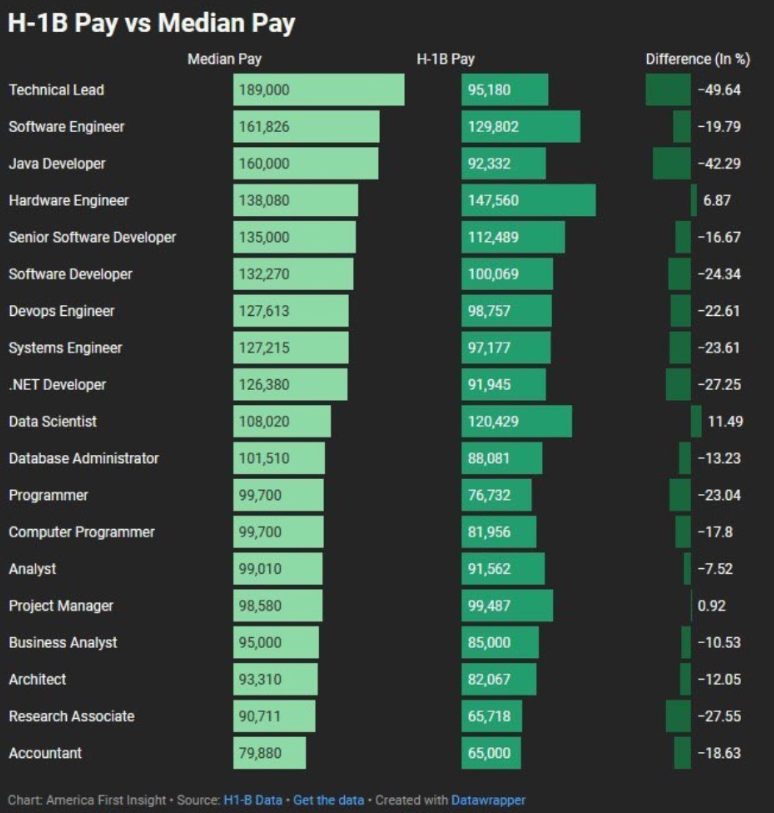

# Setup

In [168]:
import pandas
import pandas as pd
import os
import geopandas
import geopandas as gpd
import numpy as np

In [169]:
dataPath = r'C:\Users\eagle\OneDrive\Documents\Data\H1B\CSV\LCA_Disclosure_Data_FY2025_Q1.csv' # data source: https://www.dol.gov/agencies/eta/foreign-labor/performance
popDataPath = r"C:\Users\eagle\OneDrive\Documents\Data\NST-EST2025-ALLDATA.csv"
pathFortune1000 = r"C:\Users\eagle\OneDrive\Documents\Data\archive\fortune1000_2024.csv"
pathFortune500 = r'C:\Users\eagle\OneDrive\Documents\Data\archive\fortune500_2025_from50pros.csv'
americanStatesPath = r"C:\Users\eagle\OneDrive\Documents\Data\cb_2018_us_state_500k\cb_2018_us_state_500k.shp"
citiesShapefilePath = r'C:\Users\eagle\OneDrive\Documents\Data\ne_110m_populated_places'
americanCitiesPath = r'C:\Users\eagle\OneDrive\Documents\Data\tl_2025_01_place\tl_2025_01_place.shp' # more granular
anotherAmericanCitiesPath = r'C:\Users\eagle\OneDrive\Documents\Data\cb_2024_us_place_500k\cb_2024_us_place_500k.shp' # more general


In [3]:
data = pandas.read_csv(dataPath)

C:\Users\eagle\AppData\Local\Temp\ipykernel_44376\229269823.py:1: DtypeWarning: Columns (90) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pandas.read_csv(dataPath)


In [87]:
data.shape

(107414, 97)

In [88]:
os.path.getsize(dataPath)/1024

85974.3056640625

If we consider using databases that are not files, we could consider to try shiny or streamlit. Could also consider https://git-lfs.com

# These files are very large, so we want to figure out a way to shrink them down to salient features before aggregating them and sharing them online.

#### How many columns are there and what would we need?

In [89]:
data.columns

Index(['CASE_NUMBER', 'CASE_STATUS', 'RECEIVED_DATE', 'DECISION_DATE',
       'ORIGINAL_CERT_DATE', 'VISA_CLASS', 'JOB_TITLE', 'SOC_CODE',
       'SOC_TITLE', 'FULL_TIME_POSITION', 'BEGIN_DATE', 'END_DATE',
       'TOTAL_WORKER_POSITIONS', 'NEW_EMPLOYMENT', 'CONTINUED_EMPLOYMENT',
       'CHANGE_PREVIOUS_EMPLOYMENT', 'NEW_CONCURRENT_EMPLOYMENT',
       'CHANGE_EMPLOYER', 'AMENDED_PETITION', 'EMPLOYER_NAME',
       'TRADE_NAME_DBA', 'EMPLOYER_ADDRESS1', 'EMPLOYER_ADDRESS2',
       'EMPLOYER_CITY', 'EMPLOYER_STATE', 'EMPLOYER_POSTAL_CODE',
       'EMPLOYER_COUNTRY', 'EMPLOYER_PROVINCE', 'EMPLOYER_PHONE',
       'EMPLOYER_PHONE_EXT', 'EMPLOYER_FEIN', 'NAICS_CODE',
       'EMPLOYER_POC_LAST_NAME', 'EMPLOYER_POC_FIRST_NAME',
       'EMPLOYER_POC_MIDDLE_NAME', 'EMPLOYER_POC_JOB_TITLE',
       'EMPLOYER_POC_ADDRESS1', 'EMPLOYER_POC_ADDRESS2', 'EMPLOYER_POC_CITY',
       'EMPLOYER_POC_STATE', 'EMPLOYER_POC_POSTAL_CODE',
       'EMPLOYER_POC_COUNTRY', 'EMPLOYER_POC_PROVINCE', 'EMPLOYER_POC_PHON

Its curious why some columns are there when we assume it will always have a similar data point. Let's see if that's the case.

#### Aren't there some obvious attributes here that don't need to be in the table?

In [9]:
with pandas.option_context('display.max_rows', None, 'display.max_columns', None):
    print(data[['VISA_CLASS', 'FULL_TIME_POSITION', 'TOTAL_WORKER_POSITIONS']].value_counts())

VISA_CLASS       FULL_TIME_POSITION  TOTAL_WORKER_POSITIONS
H-1B             Y                   1                         97655
                                     10                         2410
E-3 Australian   Y                   1                          2260
H-1B             N                   1                          1749
H-1B1 Chile      Y                   1                           483
H-1B1 Singapore  Y                   1                           387
H-1B             Y                   3                           362
                                     5                           356
                                     20                          268
                                     25                          249
                                     50                          219
                                     2                           201
                                     6                           154
                                     40    

Looks like Chileans, Singaporeans, and Australians have a unique version for the skill based non-immigrant/dual-intent visa. It's also surprising that an application has worker positions column suggesting that it may either be a count of the workers in the organizations or number of applicants falling within the application? Its not clear why there would be non-unitary values there. But, as expected the majority of the data falls into full time positions for a single unit of worker.

#### What else is there besides Certified, Withdraw, and Denied in `CASE_STATUS`?

In [10]:
data['CASE_STATUS'].unique()

array(['Withdrawn', 'Denied', 'Certified', 'Certified - Withdrawn'],
      dtype=object)

#### Let's check out how this truncated dataset looks like

In [11]:
data.head()[['CASE_STATUS', 'JOB_TITLE', 'SOC_TITLE', 'PREVAILING_WAGE', 'PW_UNIT_OF_PAY', 
             'BEGIN_DATE', 'END_DATE', 'NEW_EMPLOYMENT', 'CONTINUED_EMPLOYMENT',
             'CHANGE_PREVIOUS_EMPLOYMENT', 'NEW_CONCURRENT_EMPLOYMENT',
             'CHANGE_EMPLOYER', 'EMPLOYER_NAME',
             'PW_WAGE_LEVEL', 'EMPLOYER_CITY', 'EMPLOYER_STATE',
             'WORKSITE_WORKERS', 'WORKSITE_CITY', 'WORKSITE_COUNTY',
       'WORKSITE_STATE', 'WORKSITE_POSTAL_CODE']]

,CASE_STATUS,JOB_TITLE,SOC_TITLE,PREVAILING_WAGE,PW_UNIT_OF_PAY,BEGIN_DATE,END_DATE,NEW_EMPLOYMENT,CONTINUED_EMPLOYMENT,CHANGE_PREVIOUS_EMPLOYMENT,...,CHANGE_EMPLOYER,EMPLOYER_NAME,PW_WAGE_LEVEL,EMPLOYER_CITY,EMPLOYER_STATE,WORKSITE_WORKERS,WORKSITE_CITY,WORKSITE_COUNTY,WORKSITE_STATE,WORKSITE_POSTAL_CODE
0,Withdrawn,Database Administrator,Database Administrators,$42.53,Hour,1/13/2025,1/12/2028,0,0,0,...,0,"FIRST TEK, INC.",II,"Piscataway,",NJ,1,Mountain House,SAN JOAQUIN,CA,95391
1,Withdrawn,Abdominal Radiologist Assistant Professor Clin...,Radiologists,"$134,347.00",Year,6/13/2025,6/12/2028,1,0,0,...,0,University of Utah Office of General Counsel,II,Salt Lake City,UT,1,Salt Lake City,SALT LAKE,UT,84132
2,Withdrawn,PROJECT MANAGER,Information Technology Project Managers,"$90,002.00",Year,1/7/2025,1/6/2028,0,0,0,...,0,CYBAGE SOFTWARE INC,II,PRINCETON JUNCTION,NJ,1,EDISON,MIDDLESEX,NJ,08820
3,Withdrawn,Database Administrators,Database Administrators,"$69,326.00",Year,12/31/2024,12/30/2027,0,0,0,...,0,L&T Technology Services Limited,II,Edison,NJ,1,Gregory,SAN PATRICIO,TX,78359
4,Withdrawn,Computer Systems Analyst,Computer Systems Analysts,"$100,714.00",Year,12/31/2024,12/30/2027,0,0,0,...,0,"TECH MAHINDRA (AMERICAS), INC",II,BEDMINSTER,NJ,1,IRVING,DALLAS,TX,75039


Convert wage data to all hourly or yearly?

#### What are the unique job title classes?

In [12]:
jobTitles = data['SOC_TITLE'].unique().tolist()

In [13]:
for job in jobTitles:
    print(job)

Database Administrators
Radiologists
Information Technology Project Managers
Computer Systems Analysts
Physicians, All Other
General and Operations Managers
Software Developers
Mechanical Engineers
Biological Technicians
Family Medicine Physicians
Procurement Clerks
Data Scientists
Marketing Managers
Market Research Analysts and Marketing Specialists
Commercial and Industrial Designers
Special Effects Artists and Animators
Dentists, General
Software Quality Assurance Analysts and Testers
Parts Salespersons
Chief Executives
Computer and Information Systems Managers
Validation Engineers
Architects, Except Landscape and Naval
Mental Health Counselors
Business Intelligence Analysts
Construction Managers
Statisticians
Transportation, Storage, and Distribution Managers
Network and Computer Systems Administrators
Educational, Guidance, and Career Counselors and Advisors
Materials Engineers
Industrial Engineers
Home Health Aides
Web and Digital Interface Designers
Electrical Engineers
Operatio

#### What is the frequency of job titles?

In [14]:
jobTitlesCount = data['SOC_TITLE'].value_counts()

In [15]:
jobTitlesCount

SOC_TITLE
Software Developers                                              37240
Computer Systems Engineers/Architects                             5078
Information Technology Project Managers                           4154
Software Quality Assurance Analysts and Testers                   3691
Computer and Information Systems Managers                         3235
                                                                 ...  
Advanced Practice Psychiatric Nurses                                 1
VETERINARIANS                                                        1
Robotics Engineer                                                    1
Computer Science Teachers                                            1
First-Line Supervisors of Housekeeping and Janitorial Workers        1
Name: count, Length: 600, dtype: int64

This one is kind of obvious.

In [16]:
spatialDistribution = data['WORKSITE_STATE'].value_counts()

# Let's aggregate all the data by state

In [90]:
data.columns

Index(['CASE_NUMBER', 'CASE_STATUS', 'RECEIVED_DATE', 'DECISION_DATE',
       'ORIGINAL_CERT_DATE', 'VISA_CLASS', 'JOB_TITLE', 'SOC_CODE',
       'SOC_TITLE', 'FULL_TIME_POSITION', 'BEGIN_DATE', 'END_DATE',
       'TOTAL_WORKER_POSITIONS', 'NEW_EMPLOYMENT', 'CONTINUED_EMPLOYMENT',
       'CHANGE_PREVIOUS_EMPLOYMENT', 'NEW_CONCURRENT_EMPLOYMENT',
       'CHANGE_EMPLOYER', 'AMENDED_PETITION', 'EMPLOYER_NAME',
       'TRADE_NAME_DBA', 'EMPLOYER_ADDRESS1', 'EMPLOYER_ADDRESS2',
       'EMPLOYER_CITY', 'EMPLOYER_STATE', 'EMPLOYER_POSTAL_CODE',
       'EMPLOYER_COUNTRY', 'EMPLOYER_PROVINCE', 'EMPLOYER_PHONE',
       'EMPLOYER_PHONE_EXT', 'EMPLOYER_FEIN', 'NAICS_CODE',
       'EMPLOYER_POC_LAST_NAME', 'EMPLOYER_POC_FIRST_NAME',
       'EMPLOYER_POC_MIDDLE_NAME', 'EMPLOYER_POC_JOB_TITLE',
       'EMPLOYER_POC_ADDRESS1', 'EMPLOYER_POC_ADDRESS2', 'EMPLOYER_POC_CITY',
       'EMPLOYER_POC_STATE', 'EMPLOYER_POC_POSTAL_CODE',
       'EMPLOYER_POC_COUNTRY', 'EMPLOYER_POC_PROVINCE', 'EMPLOYER_POC_PHON

In [98]:
data['WAGE_UNIT_OF_PAY'].value_counts()

WAGE_UNIT_OF_PAY
Year         100389
Hour           6666
Month           220
Week             83
Bi-Weekly        56
Name: count, dtype: int64

In [187]:
data[(data['SECONDARY_ENTITY'] == 'Yes') &
     (data['H-1B_DEPENDENT'] == 'Yes')]

,CASE_NUMBER,CASE_STATUS,RECEIVED_DATE,DECISION_DATE,ORIGINAL_CERT_DATE,VISA_CLASS,JOB_TITLE,SOC_CODE,SOC_TITLE,FULL_TIME_POSITION,...,WILLFUL_VIOLATOR,SUPPORT_H1B,STATUTORY_BASIS,APPENDIX_A_ATTACHED,PUBLIC_DISCLOSURE,PREPARER_LAST_NAME,PREPARER_FIRST_NAME,PREPARER_MIDDLE_INITIAL,PREPARER_BUSINESS_NAME,PREPARER_EMAIL
0,I-200-24366-578757,Withdrawn,12/31/2024,12/31/2024,NaN,H-1B,Database Administrator,15-1242.00,Database Administrators,N,...,No,Yes,"Both $60,000 or higher in annual wage and Mast...",NaN,Disclose Business,NaN,NaN,NaN,NaN,NaN
3,I-200-24366-578384,Withdrawn,12/31/2024,12/31/2024,NaN,H-1B,Database Administrators,15-1242.00,Database Administrators,Y,...,No,Yes,"$60,000 or higher annual wage",NaN,Disclose Business,NaN,NaN,NaN,NaN,NaN
4,I-200-24366-578405,Withdrawn,12/31/2024,12/31/2024,NaN,H-1B,Computer Systems Analyst,15-1211.00,Computer Systems Analysts,Y,...,No,Yes,"$60,000 or higher annual wage",NaN,Disclose Business,REDDY,LOKESH CHANGALRAI,NaN,"TECH MAHINDRA (AMERICAS), INC",LR00821941@TECHMAHINDRA.COM
22,I-200-24358-566701,Certified,12/22/2024,12/31/2024,NaN,H-1B,Test Consultant 2,15-1253.00,Software Quality Assurance Analysts and Testers,Y,...,No,Yes,"$60,000 or higher annual wage",NaN,Disclose Business,NaN,NaN,NaN,NaN,NaN
27,I-200-24357-566580,Certified,12/22/2024,12/31/2024,NaN,H-1B,Validation Engineer,17-2112.02,Validation Engineers,Y,...,No,Yes,"Both $60,000 or higher in annual wage and Mast...",NaN,Disclose Business,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107283,I-200-23249-324380,Certified - Withdrawn,9/6/2023,10/1/2024,9/13/2023,H-1B,Senior Solutions Architect,15-1241.00,Computer Network Architects,Y,...,No,Yes,"Both $60,000 or higher in annual wage and Mast...",NaN,Disclose Business,NaN,NaN,NaN,NaN,NaN
107295,I-200-23181-160292,Certified - Withdrawn,6/30/2023,10/1/2024,7/10/2023,H-1B,Data Scientist II,15-2051.00,Data Scientists,Y,...,No,Yes,"Both $60,000 or higher in annual wage and Mast...",NaN,Disclose Business,NaN,NaN,NaN,NaN,NaN
107308,I-200-23117-971390,Certified - Withdrawn,4/27/2023,10/1/2024,5/4/2023,H-1B,Technical Lead,15-1252.00,Software Developers,Y,...,No,Yes,"Both $60,000 or higher in annual wage and Mast...",NaN,Disclose Business,NaN,NaN,NaN,NaN,NaN
107310,I-200-23109-947392,Certified - Withdrawn,4/19/2023,10/1/2024,4/26/2023,H-1B,Network Engineer(SERVLLGX0196),15-1244.00,Network and Computer Systems Administrators,Y,...,No,Yes,"Both $60,000 or higher in annual wage and Mast...",NaN,Disclose Business,NaN,NaN,NaN,NaN,NaN


In [ ]:
data[['CASE_NUMBER', 'WORKSITE_STATE', 'WORKSITE_COUNTY', 'EMPLOYER_STATE', 
      'SOC_CODE', 'WAGE_RATE_OF_PAY_FROM',
       'WAGE_RATE_OF_PAY_TO', 'WAGE_UNIT_OF_PAY', 'PREVAILING_WAGE', 'NEW_EMPLOYMENT', 
       'CONTINUED_EMPLOYMENT', 'PW_WAGE_LEVEL',
       'CHANGE_PREVIOUS_EMPLOYMENT', 'NEW_CONCURRENT_EMPLOYMENT',
       'CHANGE_EMPLOYER']]

# where VISA_CLASS is traditional 'H-1B' and CASE_STATUS is 'Certified' and 
# FULL_TIME_POSITION is 'Y' and 
# WAGE_UNIT_OF_PAY which has options of 'Year', 'Hour', 'Month', 'Week', 'Bi-Weekly' 
# is standardized by year

,CASE_NUMBER,WORKSITE_STATE,SOC_CODE,WAGE_RATE_OF_PAY_FROM,WAGE_RATE_OF_PAY_TO,WAGE_UNIT_OF_PAY,PREVAILING_WAGE,NEW_EMPLOYMENT,CONTINUED_EMPLOYMENT,PW_WAGE_LEVEL,CHANGE_PREVIOUS_EMPLOYMENT,NEW_CONCURRENT_EMPLOYMENT,CHANGE_EMPLOYER
0,I-200-24366-578757,CA,15-1242.00,$42.53,$65.00,Hour,$42.53,0,0,II,0,1,0
1,I-200-24366-578499,UT,29-1224.00,"$377,795.00",NaN,Year,"$134,347.00",1,0,II,0,0,0
2,I-200-24366-578081,NJ,15-1299.09,"$111,800.00",NaN,Year,"$90,002.00",0,0,II,0,0,0
3,I-200-24366-578384,TX,15-1242.00,"$79,622.00","$89,622.00",Year,"$69,326.00",0,0,II,0,0,0
4,I-200-24366-578405,TX,15-1211.00,"$121,250.00",NaN,Year,"$100,714.00",0,0,II,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
107409,I-200-21265-600769,CA,15-1121.00,"$180,000.00",NaN,Year,"$146,682.00",0,0,IV,0,0,1
107410,I-200-21217-505028,DE,19-1012.00,"$54,540.00",NaN,Year,"$35,942.00",1,0,I,0,0,0
107411,I-200-21173-417532,GA,19-1021.00,"$48,000.00",NaN,Year,"$40,768.00",0,1,I,0,0,0
107412,I-200-21172-414601,DE,19-1012.00,"$53,076.00",NaN,Year,"$38,979.00",1,0,I,0,0,0


In [257]:
filteredData = data[
    (data['VISA_CLASS'] == 'H-1B') &
    (data['CASE_STATUS'] == 'Certified') &
    (data['FULL_TIME_POSITION'] == 'Y')
].copy()

In [258]:
conversion = {
    'Year': 1,
    'Month': 12,
    'Week': 52,
    'Bi-Weekly': 26,
    'Hour': 2080  # 40 hrs/week * 52 weeks
}

In [259]:
wage_bounds = {
    'Hour': (1, 200),          # allows high-end tech/consulting
    'Week': (100, 10000),
    'Bi-Weekly': (200, 20000),
    'Month': (500, 50000),
    'Year': (20000, 1000000)
}

In [260]:
def is_valid_wage(row):
    unit = row['WAGE_UNIT_OF_PAY']
    wage = row['WAGE_RATE_OF_PAY_FROM']
    prev_wage = row['PREVAILING_WAGE']
    
    if unit not in wage_bounds:
        return False
    
    low, high = wage_bounds[unit]
    return (low <= wage <= high) & (low <= prev_wage <= high)

In [261]:
def clean_wage(x):
    if pd.isna(x):
        return np.nan
    
    # Remove commas, dollar signs, spaces, etc.
    x = str(x)
    x = x.replace(',', '').replace('$', '').strip()
    
    # Keep only digits + decimal
    x = ''.join(ch for ch in x if ch.isdigit() or ch == '.')
    
    try:
        return float(x)
    except:
        return np.nan

In [262]:
def fix_unit(row):
    wage = row['WAGE_RATE_OF_PAY_FROM']
    unit = row['WAGE_UNIT_OF_PAY']
    
    # suspicious hourly → probably annual mislabel
    if unit == 'Hour' and wage > 300:
        return 'Year'
    
    return unit

In [263]:
filteredData['WAGE_RATE_OF_PAY_FROM'] = filteredData['WAGE_RATE_OF_PAY_FROM'].apply(clean_wage)
filteredData['WAGE_RATE_OF_PAY_TO'] = filteredData['WAGE_RATE_OF_PAY_TO'].apply(clean_wage)
filteredData['PREVAILING_WAGE'] = filteredData['PREVAILING_WAGE'].apply(clean_wage)

In [264]:
filteredData['WAGE_UNIT_OF_PAY'] = filteredData.apply(fix_unit, axis=1)

In [265]:
filteredData = filteredData[filteredData.apply(is_valid_wage, axis=1)]

In [295]:
filteredData = filteredData[filteredData['WAGE_UNIT_OF_PAY'].isin(conversion.keys())]

filteredData['STANDARD_WAGE'] = filteredData['WAGE_RATE_OF_PAY_FROM'] * filteredData['WAGE_UNIT_OF_PAY'].map(conversion)
filteredData['ANNUAL_PREVAILING_WAGE'] = filteredData['PREVAILING_WAGE'] * filteredData['WAGE_UNIT_OF_PAY'].map(conversion)

In [343]:
columnSubsetFilteredData = filteredData[['CASE_NUMBER', 'WORKSITE_STATE', 'WORKSITE_COUNTY', 
       'EMPLOYER_NAME', 'EMPLOYER_STATE',
       'NAICS_CODE', 
       'SOC_CODE', 'TOTAL_WORKER_POSITIONS', 'SECONDARY_ENTITY', 'H-1B_DEPENDENT',
       'STANDARD_WAGE', 'PW_WAGE_LEVEL', 'PREVAILING_WAGE', 'WAGE_UNIT_OF_PAY', 'ANNUAL_PREVAILING_WAGE',
       'NEW_EMPLOYMENT', 
       'CONTINUED_EMPLOYMENT', 'CHANGE_PREVIOUS_EMPLOYMENT', 'NEW_CONCURRENT_EMPLOYMENT',
       'CHANGE_EMPLOYER', 'AMENDED_PETITION']]

In [344]:
columnSubsetFilteredData['PREVAILING_WAGE'] = columnSubsetFilteredData['PREVAILING_WAGE'].apply(clean_wage)

C:\Users\eagle\AppData\Local\Temp\ipykernel_27532\2388948943.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  columnSubsetFilteredData['PREVAILING_WAGE'] = columnSubsetFilteredData['PREVAILING_WAGE'].apply(clean_wage)


In [345]:
columnSubsetFilteredData.sort_values(by="TOTAL_WORKER_POSITIONS", ascending = False)

,CASE_NUMBER,WORKSITE_STATE,WORKSITE_COUNTY,EMPLOYER_NAME,EMPLOYER_STATE,NAICS_CODE,SOC_CODE,TOTAL_WORKER_POSITIONS,SECONDARY_ENTITY,H-1B_DEPENDENT,...,PW_WAGE_LEVEL,PREVAILING_WAGE,WAGE_UNIT_OF_PAY,ANNUAL_PREVAILING_WAGE,NEW_EMPLOYMENT,CONTINUED_EMPLOYMENT,CHANGE_PREVIOUS_EMPLOYMENT,NEW_CONCURRENT_EMPLOYMENT,CHANGE_EMPLOYER,AMENDED_PETITION
5378,I-200-24353-553215,NC,MECKLENBURG,Microsoft Corporation,WA,513210,15-1299.08,100,No,No,...,II,77958.0,Year,77958.0,100,0,0,0,0,0
7438,I-200-24352-549043,WA,KING,Microsoft Corporation,WA,513210,15-1252.00,100,No,No,...,II,137259.0,Year,137259.0,100,0,0,0,0,0
8619,I-200-24351-545054,WA,KING,Microsoft Corporation,WA,513210,15-1252.00,100,No,No,...,II,137259.0,Year,137259.0,100,0,0,0,0,0
10021,I-200-24351-544980,WA,KING,Microsoft Corporation,WA,513210,15-1252.00,100,No,No,...,I,110635.0,Year,110635.0,100,0,0,0,0,0
9827,I-200-24351-545010,WA,KING,Microsoft Corporation,WA,513210,15-1252.00,100,No,No,...,I,110635.0,Year,110635.0,100,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107188,I-200-24268-361138,NY,NEW YORK,"The Farmer's Dog, Inc.",NY,311111,15-1243.00,1,No,No,...,III,151154.0,Year,151154.0,0,1,0,0,0,0
107189,I-200-24268-361373,GA,FULTON,"Fiserv Solutions, LLC",WI,51821,15-1252.00,1,No,No,...,IV,149760.0,Year,149760.0,0,0,1,0,0,0
107190,I-200-24268-359726,AR,PULASKI,University of Arkansas for Medical Sciences,AR,611310,29-1229.00,1,No,No,...,NaN,68965.0,Year,68965.0,0,0,1,0,0,0
107191,I-200-24268-359331,WA,KING,Microsoft Corporation,WA,513210,15-1252.00,1,No,No,...,II,137259.0,Year,137259.0,0,1,0,0,0,0


In [346]:
newApplicantsOfInterest = columnSubsetFilteredData[
    (columnSubsetFilteredData['TOTAL_WORKER_POSITIONS'] >= 2) &
    (columnSubsetFilteredData['SECONDARY_ENTITY'] == 'Yes') &
    (columnSubsetFilteredData['H-1B_DEPENDENT'] == 'Yes')]

In [347]:
newApplicantsOfInterest['EMPLOYER_NAME'].value_counts()

EMPLOYER_NAME
WIPRO LIMITED                               169
INFOSYS LIMITED                             126
Mastech Digital Technologies, Inc.           97
MIRAFRA INC                                  13
APPLICATIONS SOFTWARE TECHNOLOGY LLC          5
TATA CONSULTANCY SERVICES LIMITED             5
Tata Elxsi Limited                            4
Oracle Financial Services Software, Inc.      4
Tata Elxsi Ltd                                2
Systems Technology Group, Inc.                2
DeeBeCon Inc                                  2
Even & Odd Mind, LLC                          1
Cigniti Technologies, Inc.                    1
INFOSYS BPM LIMITED                           1
PHOTON INFOTECH, INC.                         1
Systems Technology Group Inc                  1
Mastech Digital Systems, Inc.                 1
Mastech Digital Alliances, Inc.               1
Fourth Technologies                           1
Comtrix Solutions, Inc.                       1
Tata Elxsi Limited        

In [348]:
newApplicantsOfInterest.groupby(newApplicantsOfInterest['SOC_CODE'].str[:2])['SOC_CODE'].count()

SOC_CODE
11      1
13     31
15    395
17     13
29      1
Name: SOC_CODE, dtype: int64

In [349]:
columnSubsetFilteredData.groupby(columnSubsetFilteredData['SOC_CODE'].str[:2])['SOC_CODE'].count()

SOC_CODE
11     5508
12        2
13     5366
15    64470
17     8046
19     4021
21      430
23      271
25     2321
27      597
29     2519
31        6
35        4
39        6
41      456
43       19
47        1
49        1
53        4
Name: SOC_CODE, dtype: int64

In [350]:
newApplicantsOfInterest.groupby('WORKSITE_STATE').agg(total_cases = ('TOTAL_WORKER_POSITIONS', 'sum'))

,total_cases
WORKSITE_STATE,
AL,5
AR,12
AZ,19
CA,369
CO,29
CT,18
DC,12
FL,40
GA,114


In [351]:
columnSubsetFilteredData.groupby('WORKSITE_STATE').agg(total_cases = ('TOTAL_WORKER_POSITIONS', 'sum'))

,total_cases
WORKSITE_STATE,
AK,57
AL,279
AR,860
AZ,2429
CA,39639
CO,1371
CT,1002
DC,521
DE,444


In [366]:
fullDataset = columnSubsetFilteredData.copy().dropna()

# SOC 2-digit
fullDataset['SOC2'] = fullDataset['SOC_CODE'].astype(str).str[:2]
fullDataset = fullDataset[fullDataset['SOC2'].str.isnumeric()]

# PW level numeric
pw_map = {'I': 1, 'II': 2, 'III': 3, 'IV': 4}
fullDataset['pw_level_num'] = fullDataset['PW_WAGE_LEVEL'].map(pw_map)

fullDataset['out_of_state'] = (
    fullDataset['EMPLOYER_STATE'] != fullDataset['WORKSITE_STATE']
).astype(int)

# Row-level proportions
for col in ['NEW_EMPLOYMENT', 'CONTINUED_EMPLOYMENT',
            'CHANGE_PREVIOUS_EMPLOYMENT', 'NEW_CONCURRENT_EMPLOYMENT',
            'CHANGE_EMPLOYER', 'AMENDED_PETITION']:
    fullDataset[col + '_p'] = fullDataset[col] / fullDataset['TOTAL_WORKER_POSITIONS']

def agg_func(g):
    w = g['TOTAL_WORKER_POSITIONS']
    total_w = w.sum()
    
    return pd.Series({
        'total_positions': total_w,
        'avg_wage': (g['STANDARD_WAGE'] * w).sum() / total_w,
        'avg_pw': (g['ANNUAL_PREVAILING_WAGE'] * w).sum() / total_w,
        'wage_gap': ((g['STANDARD_WAGE'] - g['ANNUAL_PREVAILING_WAGE']) * w).sum() / total_w,
        'avg_pw_level': (g['pw_level_num'] * w).sum() / total_w,
        'sec_entity_rate': ((g['SECONDARY_ENTITY'] == 'Yes') * w).sum() / total_w,
        'h1b_dep_rate': ((g['H-1B_DEPENDENT'] == 'Yes') * w).sum() / total_w,
        'out_of_state_rate': (g['out_of_state'] * w).sum() / total_w,
        'new_emp_prop': g['NEW_EMPLOYMENT_p'].sum() / total_w,
        'cont_emp_prop': g['CONTINUED_EMPLOYMENT_p'].sum() / total_w,
        'change_prev_prop': g['CHANGE_PREVIOUS_EMPLOYMENT_p'].sum() / total_w,
        'concurrent_prop': g['NEW_CONCURRENT_EMPLOYMENT_p'].sum() / total_w,
        'change_emp_prop': g['CHANGE_EMPLOYER_p'].sum() / total_w,
        'amend_pet_prop': g['AMENDED_PETITION_p'].sum() / total_w,
    })

state_soc2_df = (
    fullDataset.groupby(['WORKSITE_STATE', 'SOC2'])
      .apply(agg_func)
      .reset_index()
)

C:\Users\eagle\AppData\Local\Temp\ipykernel_27532\3980371922.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(agg_func)


In [367]:
state_soc2_df

,WORKSITE_STATE,SOC2,total_positions,avg_wage,avg_pw,wage_gap,avg_pw_level,sec_entity_rate,h1b_dep_rate,out_of_state_rate,new_emp_prop,cont_emp_prop,change_prev_prop,concurrent_prop,change_emp_prop,amend_pet_prop
0,AK,13,2.0,68931.400000,68931.400000,0.000000,1.500000,0.000000,0.000000,0.500000,0.500000,0.000000,0.0,0.0,0.000000,0.500000
1,AK,15,4.0,74630.400000,70798.000000,3832.400000,1.250000,1.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,1.000000,0.000000
2,AK,17,4.0,100891.000000,94775.000000,6116.000000,1.500000,0.000000,0.000000,1.000000,0.500000,0.000000,0.0,0.0,0.500000,0.000000
3,AK,19,1.0,52603.000000,52603.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.0,0.000000,0.000000
4,AK,25,27.0,76608.490370,60112.288889,16496.201481,1.222222,0.000000,0.000000,0.000000,0.740741,0.259259,0.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522,WY,15,13.0,88564.076923,73478.538462,15085.538462,2.076923,0.230769,0.307692,0.538462,0.307692,0.153846,0.0,0.0,0.307692,0.230769
523,WY,17,3.0,113698.346667,86063.666667,27634.680000,2.333333,0.333333,0.000000,0.666667,0.666667,0.000000,0.0,0.0,0.333333,0.000000
524,WY,19,2.0,69999.500000,53248.000000,16751.500000,1.000000,0.000000,0.000000,0.000000,0.500000,0.500000,0.0,0.0,0.000000,0.000000
525,WY,21,1.0,42058.000000,42058.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.0,0.000000,0.000000


In [372]:
entropy_df = state_soc2_df.copy()[['WORKSITE_STATE', 'SOC2', 'total_positions']]

In [373]:
entropy_df

,WORKSITE_STATE,SOC2,total_positions
0,AK,13,2.0
1,AK,15,4.0
2,AK,17,4.0
3,AK,19,1.0
4,AK,25,27.0
...,...,...,...
522,WY,15,13.0
523,WY,17,3.0
524,WY,19,2.0
525,WY,21,1.0


In [374]:
entropy_df['state_total'] = entropy_df.groupby('WORKSITE_STATE')['total_positions'].transform('sum')

In [375]:
entropy_df['p'] = entropy_df['total_positions'] / entropy_df['state_total']

In [376]:
state_entropy = entropy_df.groupby('WORKSITE_STATE')['p'].apply(
    lambda p: -(p * np.log(p)).sum()
).reset_index(name='entropy')

In [377]:
k_df = entropy_df.groupby('WORKSITE_STATE')['SOC2'].nunique().reset_index(name='k')

state_entropy = state_entropy.merge(k_df, on='WORKSITE_STATE')

state_entropy['entropy_norm'] = state_entropy['entropy'] / np.log(state_entropy['k'])

In [378]:
state_entropy = state_entropy[['WORKSITE_STATE', 'entropy_norm']]

In [379]:
state_entropy

,WORKSITE_STATE,entropy_norm
0,AK,0.601126
1,AL,0.682142
2,AR,0.286843
3,AZ,0.432477
4,CA,0.417595
5,CO,0.388458
6,CT,0.495231
7,DC,0.677603
8,DE,0.351488
9,FL,0.461470


In [385]:
state_totals = entropy_df.groupby('WORKSITE_STATE')['total_positions'].sum().reset_index(name='state_total')

In [389]:
soc_df = entropy_df.merge(state_totals, on='WORKSITE_STATE')
soc_df['p'] = soc_df['total_positions'] / soc_df['state_total_x']

In [392]:
soc_df = soc_df[soc_df['SOC2'].isin(entropy_df['SOC2'].unique())]

In [396]:
SOC_p_df = soc_df.pivot(
    index='WORKSITE_STATE',
    columns='SOC2',
    values='p'
)

In [398]:
SOC_p_df = SOC_p_df.reindex(columns=entropy_df['SOC2'].unique(), fill_value=0)
SOC_p_df = SOC_p_df.reset_index()

In [401]:
SOC_p_df.fillna(0).to_csv(os.path.join(savePathFolder, 'SOCp.csv'))

In [368]:
truncatedDataset = newApplicantsOfInterest.copy().dropna()

# SOC 2-digit
truncatedDataset['SOC2'] = truncatedDataset['SOC_CODE'].astype(str).str[:2]
truncatedDataset = truncatedDataset[fullDataset['SOC2'].str.isnumeric()]

# PW level numeric
pw_map = {'I': 1, 'II': 2, 'III': 3, 'IV': 4}
truncatedDataset['pw_level_num'] = truncatedDataset['PW_WAGE_LEVEL'].map(pw_map)

truncatedDataset['out_of_state'] = (
    truncatedDataset['EMPLOYER_STATE'] != truncatedDataset['WORKSITE_STATE']
).astype(int)

# Row-level proportions
for col in ['NEW_EMPLOYMENT', 'CONTINUED_EMPLOYMENT',
            'CHANGE_PREVIOUS_EMPLOYMENT', 'NEW_CONCURRENT_EMPLOYMENT',
            'CHANGE_EMPLOYER', 'AMENDED_PETITION']:
    truncatedDataset[col + '_p'] = truncatedDataset[col] / truncatedDataset['TOTAL_WORKER_POSITIONS']

def agg_func(g):
    w = g['TOTAL_WORKER_POSITIONS']
    total_w = w.sum()
    
    return pd.Series({
        'total_positions': total_w,
        'avg_wage': (g['STANDARD_WAGE'] * w).sum() / total_w,
        'avg_pw': (g['ANNUAL_PREVAILING_WAGE'] * w).sum() / total_w,
        'wage_gap': ((g['STANDARD_WAGE'] - g['ANNUAL_PREVAILING_WAGE']) * w).sum() / total_w,
        'avg_pw_level': (g['pw_level_num'] * w).sum() / total_w,
        'sec_entity_rate': ((g['SECONDARY_ENTITY'] == 'Yes') * w).sum() / total_w,
        'h1b_dep_rate': ((g['H-1B_DEPENDENT'] == 'Yes') * w).sum() / total_w,
        'out_of_state_rate': (g['out_of_state'] * w).sum() / total_w,
        'new_emp_prop': g['NEW_EMPLOYMENT_p'].sum() / total_w,
        'cont_emp_prop': g['CONTINUED_EMPLOYMENT_p'].sum() / total_w,
        'change_prev_prop': g['CHANGE_PREVIOUS_EMPLOYMENT_p'].sum() / total_w,
        'concurrent_prop': g['NEW_CONCURRENT_EMPLOYMENT_p'].sum() / total_w,
        'change_emp_prop': g['CHANGE_EMPLOYER_p'].sum() / total_w,
        'amend_pet_prop': g['AMENDED_PETITION_p'].sum() / total_w,
    })

trunc_state_soc2_df = (
    truncatedDataset.groupby(['WORKSITE_STATE', 'SOC2'])
      .apply(agg_func)
      .reset_index()
)

C:\Users\eagle\AppData\Local\Temp\ipykernel_27532\3509977951.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  truncatedDataset = truncatedDataset[fullDataset['SOC2'].str.isnumeric()]
C:\Users\eagle\AppData\Local\Temp\ipykernel_27532\3509977951.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(agg_func)


In [369]:
savePathFolder = r'C:\Users\eagle\OneDrive\Documents\GitHub\unit-3\data'

In [370]:
state_soc2_df.to_csv(os.path.join(savePathFolder, 'Q12025.csv'))

In [371]:
trunc_state_soc2_df.to_csv(os.path.join(savePathFolder, 'Q12025H1BDep.csv'))

In [381]:
state_entropy.to_csv(os.path.join(savePathFolder, 'HSOC.csv'))

# Let's try to make a map of states with major technology companies within them ranked

In [65]:
americanStates = geopandas.read_file(americanStatesPath)

<Axes: >

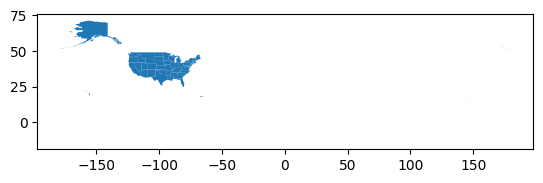

In [66]:
americanStates.plot()

In [19]:
americanStates.head()

,STATEFP,STATENS,AFFGEOID,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,28,01779790,0400000US28,28,MS,Mississippi,00,121533519481,3926919758,"MULTIPOLYGON (((-88.50297 30.21524, -88.49176 ..."
1,37,01027616,0400000US37,37,NC,North Carolina,00,125923656064,13466071395,"MULTIPOLYGON (((-75.72681 35.93584, -75.71827 ..."
2,40,01102857,0400000US40,40,OK,Oklahoma,00,177662925723,3374587997,"POLYGON ((-103.00256 36.52659, -103.00219 36.6..."
3,51,01779803,0400000US51,51,VA,Virginia,00,102257717110,8528531774,"MULTIPOLYGON (((-75.74241 37.80835, -75.74151 ..."
4,54,01779805,0400000US54,54,WV,West Virginia,00,62266474513,489028543,"POLYGON ((-82.6432 38.16909, -82.643 38.16956,..."


#### Let's first look at the fortune 500 companies

In [20]:
fortune500 = pandas.read_csv(pathFortune500)

In [21]:
fortune500.head()

,Rank,Company,Industry,City,State,Zip Code,Website,Employees,Revenue (rounded),CEO
0,1,Walmart,General Merchandisers,Bentonville,Arkansas,72716,walmart.com,"2,100,000","$681,000,000,000",Douglas McMillon
1,2,Amazon,Internet Services and Retailing,Seattle,Washington,98109,amazon.com,"1,556,000","$638,000,000,000",Andrew Jassy
2,3,UnitedHealth,Health Care: Insurance and Managed Care,Eden Prairie,Minnesota,55344,unitedhealthgroup.com,"400,000","$400,300,000,000",Stephen Hemsley
3,4,Apple,"Computers, Office Equipment",Cupertino,California,95014,apple.com,"164,000","$391,000,000,000",Timothy Cook
4,5,CVS Health,Health Care: Pharmacy and Other Services,Woonsocket,Rhode Island,2895,cvshealth.com,"259,500","$372,800,000,000",David Joyner


In [22]:
fortune500['State'].value_counts()

State
California              58
Texas                   54
New York                53
Illinois                32
Ohio                    28
Virginia                25
Florida                 22
Pennsylvania            19
Minnesota               17
Georgia                 17
Massachusetts           16
Connecticut             15
New Jersey              15
Michigan                15
North Carolina          11
Washington              11
Tennessee               11
Arizona                  9
Wisconsin                8
Colorado                 8
Indiana                  8
Missouri                 8
Rhode Island             5
Arkansas                 4
Nebraska                 4
Kentucky                 3
District Of Columbia     3
Oklahoma                 3
Maryland                 3
Nevada                   3
Idaho                    2
Oregon                   2
Iowa                     2
Louisiana                2
Alabama                  2
Delaware                 1
Kansas                

In [23]:
fortune500Geom = fortune500.merge(
    americanStates[['NAME', 'geometry']],
    left_on=['State'],
    right_on=['NAME'],
    how='left'
)

In [24]:
americanStates[americanStates['NAME'].isin(set(americanStates['NAME']) - set(fortune1000Freq.keys()))].plot()

NameError: name 'fortune1000Freq' is not defined

<Axes: >

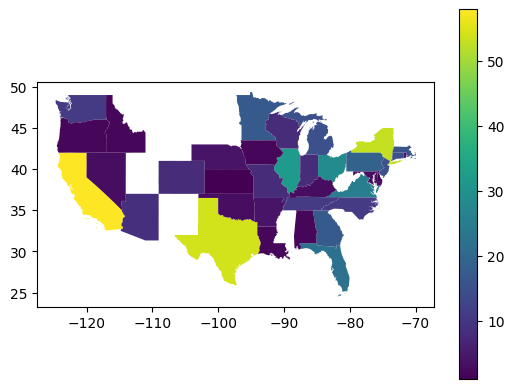

In [ ]:
fortune500FreqGeom.plot(column = "count", legend = "true", missing_kwds={'color': 'red', 'aspect': 'equal'})

In [26]:
fortune500Freq = fortune500['State'].value_counts()

In [27]:
fortune500FreqGeom = fortune500Freq.to_frame().merge(
    americanStates[['NAME', 'geometry']],
    left_on=['State'],
    right_on=['NAME'],
    how='left'
)

In [28]:
fortune500FreqGeom = geopandas.GeoDataFrame(fortune500FreqGeom)

<Axes: >

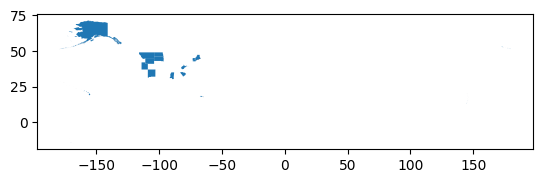

In [75]:
americanStates[americanStates['NAME'].isin(set(americanStates['NAME']) - set(fortune500Geom['State']))].plot()

In [76]:
popData = pandas.read_csv(popDataPath)

In [77]:
popData[
    popData['NAME'].isin(
            set(americanStates['NAME']) - set(fortune500Geom['State'])
        )
    ][['NAME', 'POPESTIMATE2020']].sort_values(by="POPESTIMATE2020", ascending = False)

,NAME,POPESTIMATE2020
54,South Carolina,5131992
58,Utah,3283970
65,Puerto Rico,3281591
38,Mississippi,2958385
45,New Mexico,2118446
62,West Virginia,1791670
25,Hawaii,1451130
43,New Hampshire,1378752
33,Maine,1364546
40,Montana,1087156


Lots of states don't have fortune 500 companies.

#### Let's look at the fortune 1000 companies

In [78]:
fortune1000 = pandas.read_csv(pathFortune1000)

In [79]:
fortune1000.head()

,Rank,Company,Ticker,Sector,Industry,Profitable,Founder_is_CEO,FemaleCEO,Growth_in_Jobs,Change_in_Rank,...,Assets_M,CEO,Country,HeadquartersCity,HeadquartersState,Website,CompanyType,Footnote,MarketCap_Updated_M,Updated
0,1,Walmart,WMT,Retailing,General Merchandisers,yes,no,no,no,0.0,...,252399.0,C. Douglas McMillon,U.S.,Bentonville,Arkansas,https://www.stock.walmart.com,Public,"Figures are for fiscal year ended Jan. 31, 202...",559911.0,2024-08-05
1,2,Amazon,AMZN,Retailing,Internet Services and Retailing,yes,no,no,no,0.0,...,527854.0,Andrew R. Jassy,U.S.,Seattle,Washington,https://www.amazon.com,Public,"Market value as of July 15, 2024.",2005565.0,2024-08-05
2,3,Apple,AAPL,Technology,"Computers, Office Equipment",yes,no,no,no,1.0,...,352583.0,Timothy D. Cook,U.S.,Cupertino,California,https://www.apple.com,Public,"Figures are for fiscal year ended Sept. 30, 20...",3594309.0,2024-08-05
3,4,UnitedHealth Group,UNH,Health Care,Health Care: Insurance and Managed Care,yes,no,no,yes,1.0,...,273720.0,Andrew P. Witty,U.S.,Minnetonka,Minnesota,https://www.unitedhealthgroup.com,Public,"Market value as of July 15, 2024.",474339.0,2024-08-05
4,5,Berkshire Hathaway,BRKA,Financials,Insurance: Property and Casualty (Stock),yes,no,no,yes,2.0,...,1069978.0,Warren E. Buffett,U.S.,Omaha,Nebraska,https://www.berkshirehathaway.com,Public,"Market value as of July 15, 2024.",937028.0,2024-08-05


In [80]:
fortune1000['HeadquartersState'].value_counts()

HeadquartersState
California              124
Texas                   107
New York                 78
Illinois                 58
Ohio                     51
Pennsylvania             45
Virginia                 39
Florida                  39
Georgia                  37
Massachusetts            32
Michigan                 28
North Carolina           28
Minnesota                25
Connecticut              25
Arizona                  23
Colorado                 23
New Jersey               23
Wisconsin                22
Tennessee                20
Missouri                 20
Indiana                  20
Washington               17
Maryland                 11
Nevada                   11
Oklahoma                 10
Nebraska                  8
Rhode Island              7
Kentucky                  7
Arkansas                  6
Delaware                  6
Oregon                    6
District Of Columbia      5
Idaho                     4
South Carolina            4
Kansas                    4
Ut

In [81]:
fortune1000Geom = fortune1000.merge(
    americanStates[['NAME', 'geometry']],
    left_on=['HeadquartersState'],
    right_on=['NAME'],
    how='left'
)

In [82]:
fortune1000Freq = fortune1000['HeadquartersState'].value_counts()

In [83]:
fortune1000FreqGeom = fortune1000Freq.to_frame().merge(
    americanStates[['NAME', 'geometry']],
    left_on=['HeadquartersState'],
    right_on=['NAME'],
    how='left'
)

In [84]:
fortune1000FreqGeom = geopandas.GeoDataFrame(fortune1000FreqGeom)

<Axes: >

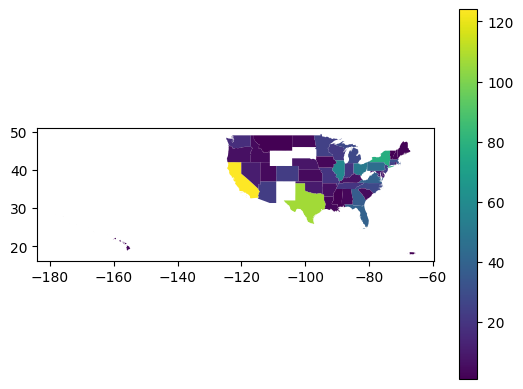

In [85]:
fortune1000FreqGeom.plot(column = "count", legend = "true", missing_kwds={'color': 'red', 'aspect': 'equal'})

In [86]:
fortune1000Freq.head()

HeadquartersState
California    124
Texas         107
New York       78
Illinois       58
Ohio           51
Name: count, dtype: int64

In [87]:
popData[popData['NAME'].isin(set(americanStates['NAME']) - set(fortune1000Freq.keys()))][['NAME', 'POPESTIMATE2020']].sort_values(by="POPESTIMATE2020", ascending = False)

,NAME,POPESTIMATE2020
45,New Mexico,2118446
62,West Virginia,1791670
55,South Dakota,887808
15,Alaska,732906
22,District of Columbia,670958
64,Wyoming,577669


I guess let's try Alaska, Wyoming, South Dakota, West Virginia and New Mexico...

# Where do skilled immigrant applicants in 2025Q1 end up getting labor applications from?

In [43]:
spatialDistribution

WORKSITE_STATE
CA    20564
TX    16772
NY     8135
WA     7346
NJ     5187
IL     4258
NC     4250
GA     4206
MA     3798
FL     3319
VA     2942
PA     2888
MI     2693
OH     2149
AZ     1977
MD     1283
TN     1281
MN     1223
CO     1131
CT     1124
MO     1047
IN     1010
AR      848
WI      779
OR      756
UT      508
DE      494
SC      479
DC      471
KY      434
IA      415
KS      353
NE      339
NV      316
AL      291
OK      274
NH      253
RI      244
LA      228
GU      192
NM      184
ID      165
MS      143
WV      111
SD       91
ME       85
ND       73
VT       66
AK       65
HI       60
MT       32
WY       32
MP       20
PR       18
VI       12
Name: count, dtype: int64

# Truncation

We choose the columns below for our data and see if it reflects a more condensed dataset.

In [44]:
dataOutPath = r'C:\Users\eagle\Downloads\unit-3\TestData'

data[['CASE_STATUS', 'JOB_TITLE', 'SOC_TITLE', 'PREVAILING_WAGE', 'PW_UNIT_OF_PAY', 
             'BEGIN_DATE', 'END_DATE', 'NEW_EMPLOYMENT', 'CONTINUED_EMPLOYMENT',
             'CHANGE_PREVIOUS_EMPLOYMENT', 'NEW_CONCURRENT_EMPLOYMENT',
             'CHANGE_EMPLOYER', 'EMPLOYER_NAME',
             'PW_WAGE_LEVEL', 'EMPLOYER_CITY', 'EMPLOYER_STATE',
             'WORKSITE_WORKERS', 'WORKSITE_CITY', 'WORKSITE_COUNTY',
       'WORKSITE_STATE', 'WORKSITE_POSTAL_CODE']].to_csv(os.path.join(dataOutPath, 'testDataSize.csv'))

In [45]:
os.path.getsize(os.path.join(dataOutPath, 'testDataSize.csv'))/1024

20058.767578125

In [46]:
truncatedDataPath = os.path.join(dataOutPath, 'testDataSize.csv')

# What are the job code frequencies?

https://www.bls.gov/oes/2023/may/oes_stru.htm is a useful page to aggregate the SOC codes for the purposes of the assignment. Interesting questions can come out of the non-information technology positions outside of the major states where it is at.

In [47]:
industries = data[['SOC_CODE', 'SOC_TITLE']]

In [48]:
industries.groupby(industries['SOC_CODE'].str[:2])['SOC_CODE'].count()

SOC_CODE
11     6867
12        2
13     6798
15    70246
17     9344
19     5180
21      532
23      472
25     2973
27      949
29     3241
31       20
33        1
35       34
37        2
39       10
41      576
43       38
45       31
47        2
49       26
51        5
53       64
54        1
Name: SOC_CODE, dtype: int64

What wage level are the medical staff?

# Can we try to join a cities shapefile to the cities identified in our skilled immigration 2025Q1 database?

In [49]:
os.listdir(citiesShapefilePath)

['ne_110m_populated_places.cpg',
 'ne_110m_populated_places.dbf',
 'ne_110m_populated_places.prj',
 'ne_110m_populated_places.README.html',
 'ne_110m_populated_places.shp',
 'ne_110m_populated_places.shx',
 'ne_110m_populated_places.VERSION.txt']

In [50]:
citiesShapefileName = 'ne_110m_populated_places.shp'

In [51]:
cities = gpd.read_file(os.path.join(citiesShapefilePath, citiesShapefileName))

<Axes: >

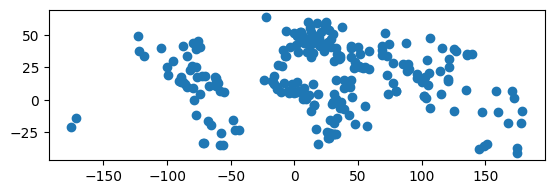

In [52]:
cities.plot()

In [53]:
americanCities = gpd.read_file(americanCitiesPath)

<Axes: >

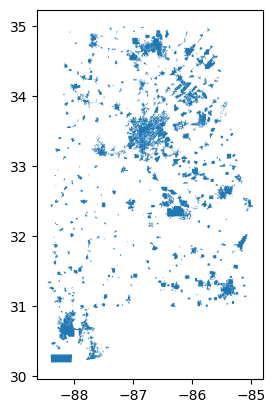

In [54]:
americanCities.plot()

In [55]:
americanCities

,STATEFP,PLACEFP,PLACENS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,PCICBSA,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,01,64152,02407196,0164152,1600000US0164152,Rehobeth,Rehobeth town,43,C1,N,G4110,A,20706750,104646,+31.1225476,-085.4396483,"MULTIPOLYGON (((-85.41906 31.16199, -85.41884 ..."
1,01,17176,02406310,0117176,1600000US0117176,Coosada,Coosada town,43,C1,N,G4110,A,17855615,620670,+32.4953941,-086.3265431,"POLYGON ((-86.35632 32.4964, -86.35502 32.4964..."
2,01,23656,02406444,0123656,1600000US0123656,Elmore,Elmore town,43,C1,N,G4110,A,16250483,362263,+32.5566058,-086.3410246,"MULTIPOLYGON (((-86.32853 32.56198, -86.32746 ..."
3,01,81720,02405723,0181720,1600000US0181720,Wetumpka,Wetumpka city,25,C1,N,G4110,A,29802978,1136032,+32.5420184,-086.2053074,"MULTIPOLYGON (((-86.2444 32.58002, -86.24428 3..."
4,01,00460,02403063,0100460,1600000US0100460,Adamsville,Adamsville city,25,C1,N,G4110,A,67897213,540470,+33.6023153,-086.9715269,"MULTIPOLYGON (((-86.91236 33.57605, -86.91211 ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589,01,69180,02402837,0169180,1600000US0169180,Selmont-West Selmont,Selmont-West Selmont CDP,57,U2,N,G4210,S,8491008,100742,+32.3782527,-087.0068876,"POLYGON ((-87.02226 32.38182, -87.02188 32.382..."
590,01,71201,02402861,0171201,1600000US0171201,Smoke Rise,Smoke Rise CDP,57,U1,N,G4210,S,14827454,32672,+33.8799418,-086.8246833,"POLYGON ((-86.84889 33.88657, -86.84882 33.886..."
591,01,72672,02628604,0172672,1600000US0172672,Spruce Pine,Spruce Pine CDP,57,U1,N,G4210,S,2403083,2825,+34.3928704,-087.7295968,"POLYGON ((-87.74194 34.397, -87.74092 34.39696..."
592,01,73272,02633318,0173272,1600000US0173272,Stockton,Stockton CDP,57,U1,N,G4210,S,24197952,743568,+31.0012455,-087.8739291,"POLYGON ((-87.89301 31.00656, -87.89296 31.006..."


<Axes: >

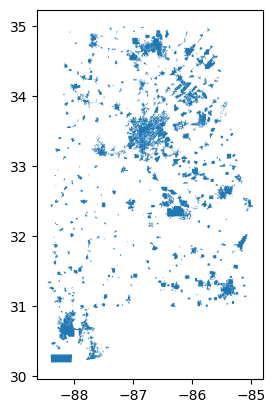

In [56]:
americanCities.plot()

In [57]:
anotherAmericanCities = gpd.read_file(anotherAmericanCitiesPath)

Source for good data on cities coordinates: https://www2.census.gov/geo/tiger/GENZ2024/shp/cb_2024_us_place_500k.zip

<Axes: >

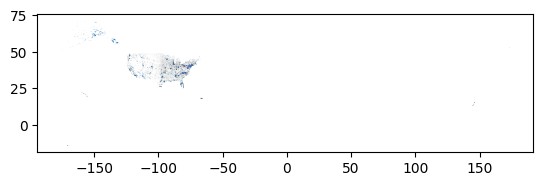

In [58]:
anotherAmericanCities.plot()

In [59]:
anotherAmericanCities.length

C:\Users\eagle\AppData\Local\Temp\ipykernel_17792\3405353109.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  anotherAmericanCities.length


0        1.237359
1        0.129710
2        1.196638
3        0.159147
4        0.059843
           ...   
32607    0.174668
32608    0.148310
32609    0.120391
32610    0.086702
32611    0.088415
Length: 32612, dtype: float64

In [60]:
anotherAmericanCities.head()

,STATEFP,PLACEFP,PLACENS,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
0,12,53150,02404445,1600000US1253150,1253150,Ormond Beach,Ormond Beach city,FL,Florida,25,90951810,10688642,"MULTIPOLYGON (((-81.13629 29.35995, -81.13167 ..."
1,17,55899,02399571,1600000US1755899,1755899,Olmsted,Olmsted village,IL,Illinois,47,8714516,338372,"POLYGON ((-89.10348 37.16677, -89.10003 37.171..."
2,06,02000,02409704,1600000US0602000,0602000,Anaheim,Anaheim city,CA,California,25,130232149,1567025,"POLYGON ((-118.01742 33.82446, -118.01644 33.8..."
3,17,47774,02399280,1600000US1747774,1747774,Maywood,Maywood village,IL,Illinois,47,7038039,0,"POLYGON ((-87.86316 41.87118, -87.85902 41.871..."
4,19,76665,02396013,1600000US1976665,1976665,Swan,Swan city,IA,Iowa,25,1597912,0,"POLYGON ((-93.32005 41.47225, -93.30106 41.472..."


In [61]:
amerCitiesGeom = anotherAmericanCities[['NAME', 'NAMELSAD', 'STUSPS', 'STATE_NAME', 'geometry']]

In [62]:
truncH1BData = pandas.read_csv(truncatedDataPath)

In [63]:
truncH1BData

,Unnamed: 0,CASE_STATUS,JOB_TITLE,SOC_TITLE,PREVAILING_WAGE,PW_UNIT_OF_PAY,BEGIN_DATE,END_DATE,NEW_EMPLOYMENT,CONTINUED_EMPLOYMENT,...,CHANGE_EMPLOYER,EMPLOYER_NAME,PW_WAGE_LEVEL,EMPLOYER_CITY,EMPLOYER_STATE,WORKSITE_WORKERS,WORKSITE_CITY,WORKSITE_COUNTY,WORKSITE_STATE,WORKSITE_POSTAL_CODE
0,0,Withdrawn,Database Administrator,Database Administrators,$42.53,Hour,1/13/2025,1/12/2028,0,0,...,0,"FIRST TEK, INC.",II,"Piscataway,",NJ,1,Mountain House,SAN JOAQUIN,CA,95391
1,1,Withdrawn,Abdominal Radiologist Assistant Professor Clin...,Radiologists,"$134,347.00",Year,6/13/2025,6/12/2028,1,0,...,0,University of Utah Office of General Counsel,II,Salt Lake City,UT,1,Salt Lake City,SALT LAKE,UT,84132
2,2,Withdrawn,PROJECT MANAGER,Information Technology Project Managers,"$90,002.00",Year,1/7/2025,1/6/2028,0,0,...,0,CYBAGE SOFTWARE INC,II,PRINCETON JUNCTION,NJ,1,EDISON,MIDDLESEX,NJ,08820
3,3,Withdrawn,Database Administrators,Database Administrators,"$69,326.00",Year,12/31/2024,12/30/2027,0,0,...,0,L&T Technology Services Limited,II,Edison,NJ,1,Gregory,SAN PATRICIO,TX,78359
4,4,Withdrawn,Computer Systems Analyst,Computer Systems Analysts,"$100,714.00",Year,12/31/2024,12/30/2027,0,0,...,0,"TECH MAHINDRA (AMERICAS), INC",II,BEDMINSTER,NJ,1,IRVING,DALLAS,TX,75039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107409,107409,Certified - Withdrawn,SENIOR SALESFORCE DEVELOPER,Computer Systems Analysts,"$146,682.00",Year,9/29/2021,9/28/2024,0,0,...,1,Snowflake Inc.,IV,San Mateo,CA,1,DUBLIN,ALAMEDA,CA,94568
107410,107410,Certified - Withdrawn,Post Doctoral Researcher (Behavioral Health & ...,Food Scientists and Technologists,"$35,942.00",Year,10/1/2021,9/30/2024,1,0,...,0,UNIVERSITY OF DELAWARE,I,NEWARK,DE,1,Newark,NEW CASTLE,DE,19711
107411,107411,Certified - Withdrawn,Postdoctoral Research Associate,Biochemists and Biophysicists,"$40,768.00",Year,10/2/2021,10/1/2024,0,1,...,0,Georgia State University,I,Atlanta,GA,1,Atlanta,FULTON,GA,30303
107412,107412,Certified - Withdrawn,Post Doctoral Researcher (Behavioral Health & ...,Food Scientists and Technologists,"$38,979.00",Year,10/1/2021,9/30/2024,1,0,...,0,UNIVERSITY OF DELAWARE,I,NEWARK,DE,1,Newark,NEW CASTLE,DE,19711


In [64]:
truncH1BData['EMPLOYER_CITY'] = truncH1BData['EMPLOYER_CITY'].str.split(',').str[0]
truncH1BData['EMPLOYER_CITY'] = truncH1BData['EMPLOYER_CITY'].str.lower().str.title()

In [65]:
truncH1BData

,Unnamed: 0,CASE_STATUS,JOB_TITLE,SOC_TITLE,PREVAILING_WAGE,PW_UNIT_OF_PAY,BEGIN_DATE,END_DATE,NEW_EMPLOYMENT,CONTINUED_EMPLOYMENT,...,CHANGE_EMPLOYER,EMPLOYER_NAME,PW_WAGE_LEVEL,EMPLOYER_CITY,EMPLOYER_STATE,WORKSITE_WORKERS,WORKSITE_CITY,WORKSITE_COUNTY,WORKSITE_STATE,WORKSITE_POSTAL_CODE
0,0,Withdrawn,Database Administrator,Database Administrators,$42.53,Hour,1/13/2025,1/12/2028,0,0,...,0,"FIRST TEK, INC.",II,Piscataway,NJ,1,Mountain House,SAN JOAQUIN,CA,95391
1,1,Withdrawn,Abdominal Radiologist Assistant Professor Clin...,Radiologists,"$134,347.00",Year,6/13/2025,6/12/2028,1,0,...,0,University of Utah Office of General Counsel,II,Salt Lake City,UT,1,Salt Lake City,SALT LAKE,UT,84132
2,2,Withdrawn,PROJECT MANAGER,Information Technology Project Managers,"$90,002.00",Year,1/7/2025,1/6/2028,0,0,...,0,CYBAGE SOFTWARE INC,II,Princeton Junction,NJ,1,EDISON,MIDDLESEX,NJ,08820
3,3,Withdrawn,Database Administrators,Database Administrators,"$69,326.00",Year,12/31/2024,12/30/2027,0,0,...,0,L&T Technology Services Limited,II,Edison,NJ,1,Gregory,SAN PATRICIO,TX,78359
4,4,Withdrawn,Computer Systems Analyst,Computer Systems Analysts,"$100,714.00",Year,12/31/2024,12/30/2027,0,0,...,0,"TECH MAHINDRA (AMERICAS), INC",II,Bedminster,NJ,1,IRVING,DALLAS,TX,75039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107409,107409,Certified - Withdrawn,SENIOR SALESFORCE DEVELOPER,Computer Systems Analysts,"$146,682.00",Year,9/29/2021,9/28/2024,0,0,...,1,Snowflake Inc.,IV,San Mateo,CA,1,DUBLIN,ALAMEDA,CA,94568
107410,107410,Certified - Withdrawn,Post Doctoral Researcher (Behavioral Health & ...,Food Scientists and Technologists,"$35,942.00",Year,10/1/2021,9/30/2024,1,0,...,0,UNIVERSITY OF DELAWARE,I,Newark,DE,1,Newark,NEW CASTLE,DE,19711
107411,107411,Certified - Withdrawn,Postdoctoral Research Associate,Biochemists and Biophysicists,"$40,768.00",Year,10/2/2021,10/1/2024,0,1,...,0,Georgia State University,I,Atlanta,GA,1,Atlanta,FULTON,GA,30303
107412,107412,Certified - Withdrawn,Post Doctoral Researcher (Behavioral Health & ...,Food Scientists and Technologists,"$38,979.00",Year,10/1/2021,9/30/2024,1,0,...,0,UNIVERSITY OF DELAWARE,I,Newark,DE,1,Newark,NEW CASTLE,DE,19711


In [66]:
testH1BData = truncH1BData.head(20)

In [67]:
testH1BData

,Unnamed: 0,CASE_STATUS,JOB_TITLE,SOC_TITLE,PREVAILING_WAGE,PW_UNIT_OF_PAY,BEGIN_DATE,END_DATE,NEW_EMPLOYMENT,CONTINUED_EMPLOYMENT,...,CHANGE_EMPLOYER,EMPLOYER_NAME,PW_WAGE_LEVEL,EMPLOYER_CITY,EMPLOYER_STATE,WORKSITE_WORKERS,WORKSITE_CITY,WORKSITE_COUNTY,WORKSITE_STATE,WORKSITE_POSTAL_CODE
0,0,Withdrawn,Database Administrator,Database Administrators,$42.53,Hour,1/13/2025,1/12/2028,0,0,...,0,"FIRST TEK, INC.",II,Piscataway,NJ,1,Mountain House,SAN JOAQUIN,CA,95391
1,1,Withdrawn,Abdominal Radiologist Assistant Professor Clin...,Radiologists,"$134,347.00",Year,6/13/2025,6/12/2028,1,0,...,0,University of Utah Office of General Counsel,II,Salt Lake City,UT,1,Salt Lake City,SALT LAKE,UT,84132
2,2,Withdrawn,PROJECT MANAGER,Information Technology Project Managers,"$90,002.00",Year,1/7/2025,1/6/2028,0,0,...,0,CYBAGE SOFTWARE INC,II,Princeton Junction,NJ,1,EDISON,MIDDLESEX,NJ,08820
3,3,Withdrawn,Database Administrators,Database Administrators,"$69,326.00",Year,12/31/2024,12/30/2027,0,0,...,0,L&T Technology Services Limited,II,Edison,NJ,1,Gregory,SAN PATRICIO,TX,78359
4,4,Withdrawn,Computer Systems Analyst,Computer Systems Analysts,"$100,714.00",Year,12/31/2024,12/30/2027,0,0,...,0,"TECH MAHINDRA (AMERICAS), INC",II,Bedminster,NJ,1,IRVING,DALLAS,TX,75039
5,5,Withdrawn,Assistant Professor,"Physicians, All Other","$65,936.00",Year,7/1/2025,6/30/2028,0,1,...,0,Board of Regents of the University of Nebraska,I,Omaha,NE,1,Omaha,SARPY,NE,68123
6,6,Denied,GENERAL MANAGER,General and Operations Managers,$27.36,Hour,1/31/2025,1/30/2027,1,1,...,0,H & S RESTAURANTS INC,I,Suffolk,VA,1,SUFFOLK,SUFFOLK CITY,VA,23435
7,7,Withdrawn,Oracle EBS Consultant,Software Developers,"$155,605.00",Year,4/2/2025,4/1/2026,0,1,...,0,"Intelecox, Inc.",II,San Diego,CA,1,Fremont,ALAMEDA,CA,94538
8,8,Denied,Project Engineer,Mechanical Engineers,"$73,500.00",Year,1/9/2025,1/9/2028,0,1,...,0,ECOTRON CORPORATION,NaN,Torrance,CA,1,Torrance,LOS ANGELES,CA,90503
9,9,Denied,Developer,Software Developers,"$96,555.00",Year,4/25/2025,4/24/2028,0,1,...,0,Barclays Services Corp.,NaN,New York,NY,1,Whippany,MORRIS,NJ,07981


In [68]:
testH1BDataGeom = testH1BData.merge(
    amerCitiesGeom[['NAME', 'STUSPS', 'geometry']],
    left_on=['EMPLOYER_CITY', 'EMPLOYER_STATE'],
    right_on=['NAME', 'STUSPS'],
    how='left'
)

In [69]:
testH1BDataGeom

,Unnamed: 0,CASE_STATUS,JOB_TITLE,SOC_TITLE,PREVAILING_WAGE,PW_UNIT_OF_PAY,BEGIN_DATE,END_DATE,NEW_EMPLOYMENT,CONTINUED_EMPLOYMENT,...,EMPLOYER_CITY,EMPLOYER_STATE,WORKSITE_WORKERS,WORKSITE_CITY,WORKSITE_COUNTY,WORKSITE_STATE,WORKSITE_POSTAL_CODE,NAME,STUSPS,geometry
0,0,Withdrawn,Database Administrator,Database Administrators,$42.53,Hour,1/13/2025,1/12/2028,0,0,...,Piscataway,NJ,1,Mountain House,SAN JOAQUIN,CA,95391,NaN,NaN,None
1,1,Withdrawn,Abdominal Radiologist Assistant Professor Clin...,Radiologists,"$134,347.00",Year,6/13/2025,6/12/2028,1,0,...,Salt Lake City,UT,1,Salt Lake City,SALT LAKE,UT,84132,Salt Lake City,UT,"POLYGON ((-112.10135 40.82714, -112.07278 40.8..."
2,2,Withdrawn,PROJECT MANAGER,Information Technology Project Managers,"$90,002.00",Year,1/7/2025,1/6/2028,0,0,...,Princeton Junction,NJ,1,EDISON,MIDDLESEX,NJ,08820,Princeton Junction,NJ,"POLYGON ((-74.62923 40.33869, -74.62788 40.337..."
3,3,Withdrawn,Database Administrators,Database Administrators,"$69,326.00",Year,12/31/2024,12/30/2027,0,0,...,Edison,NJ,1,Gregory,SAN PATRICIO,TX,78359,NaN,NaN,None
4,4,Withdrawn,Computer Systems Analyst,Computer Systems Analysts,"$100,714.00",Year,12/31/2024,12/30/2027,0,0,...,Bedminster,NJ,1,IRVING,DALLAS,TX,75039,Bedminster,NJ,"POLYGON ((-74.68078 40.67414, -74.67787 40.675..."
5,5,Withdrawn,Assistant Professor,"Physicians, All Other","$65,936.00",Year,7/1/2025,6/30/2028,0,1,...,Omaha,NE,1,Omaha,SARPY,NE,68123,Omaha,NE,"POLYGON ((-96.26804 41.2947, -96.26803 41.2950..."
6,6,Denied,GENERAL MANAGER,General and Operations Managers,$27.36,Hour,1/31/2025,1/30/2027,1,1,...,Suffolk,VA,1,SUFFOLK,SUFFOLK CITY,VA,23435,Suffolk,VA,"POLYGON ((-76.92765 36.56239, -76.92804 36.565..."
7,7,Withdrawn,Oracle EBS Consultant,Software Developers,"$155,605.00",Year,4/2/2025,4/1/2026,0,1,...,San Diego,CA,1,Fremont,ALAMEDA,CA,94538,NaN,NaN,None
8,8,Denied,Project Engineer,Mechanical Engineers,"$73,500.00",Year,1/9/2025,1/9/2028,0,1,...,Torrance,CA,1,Torrance,LOS ANGELES,CA,90503,Torrance,CA,"POLYGON ((-118.39168 33.81104, -118.39096 33.8..."
9,9,Denied,Developer,Software Developers,"$96,555.00",Year,4/25/2025,4/24/2028,0,1,...,New York,NY,1,Whippany,MORRIS,NJ,07981,New York,NY,"MULTIPOLYGON (((-73.77242 40.85954, -73.7705 4..."


In [70]:
amerCitiesGeom[
    amerCitiesGeom['NAMELSAD'].str.contains('Edison', case=False, na=False)
][['NAME', 'NAMELSAD', 'STUSPS']]

,NAME,NAMELSAD,STUSPS
35,Edison,Edison city,GA
306,Edison,Edison village,OH
15854,Edison,Edison CDP,WA
18553,Edison,Edison CDP,CA
31430,Edison,Edison village,NE


Looks like it seems to miss places which might have a different name because of how its administrative body ends up calling it.

# Since its a little obvious what the patterns might be for states with companies that can sponsor easily, let's see what other states that don't have such companies would show.

#### At least for the class assignment...

In [90]:
truncH1BData.head()

,Unnamed: 0,CASE_STATUS,JOB_TITLE,SOC_TITLE,PREVAILING_WAGE,PW_UNIT_OF_PAY,BEGIN_DATE,END_DATE,NEW_EMPLOYMENT,CONTINUED_EMPLOYMENT,...,CHANGE_EMPLOYER,EMPLOYER_NAME,PW_WAGE_LEVEL,EMPLOYER_CITY,EMPLOYER_STATE,WORKSITE_WORKERS,WORKSITE_CITY,WORKSITE_COUNTY,WORKSITE_STATE,WORKSITE_POSTAL_CODE
0,0,Withdrawn,Database Administrator,Database Administrators,$42.53,Hour,1/13/2025,1/12/2028,0,0,...,0,"FIRST TEK, INC.",II,Piscataway,NJ,1,Mountain House,SAN JOAQUIN,CA,95391
1,1,Withdrawn,Abdominal Radiologist Assistant Professor Clin...,Radiologists,"$134,347.00",Year,6/13/2025,6/12/2028,1,0,...,0,University of Utah Office of General Counsel,II,Salt Lake City,UT,1,Salt Lake City,SALT LAKE,UT,84132
2,2,Withdrawn,PROJECT MANAGER,Information Technology Project Managers,"$90,002.00",Year,1/7/2025,1/6/2028,0,0,...,0,CYBAGE SOFTWARE INC,II,Princeton Junction,NJ,1,EDISON,MIDDLESEX,NJ,08820
3,3,Withdrawn,Database Administrators,Database Administrators,"$69,326.00",Year,12/31/2024,12/30/2027,0,0,...,0,L&T Technology Services Limited,II,Edison,NJ,1,Gregory,SAN PATRICIO,TX,78359
4,4,Withdrawn,Computer Systems Analyst,Computer Systems Analysts,"$100,714.00",Year,12/31/2024,12/30/2027,0,0,...,0,"TECH MAHINDRA (AMERICAS), INC",II,Bedminster,NJ,1,IRVING,DALLAS,TX,75039


Since we are interested in Alaska, Wyoming, South Dakota, West Virginia and New Mexico, let's filter it likewise

In [72]:
statesOfInterest = {'Alaska', 'Wyoming', 'South Dakota', 'West Virginia', 'New Mexico'}

In [88]:
statesToJoin = americanStates[americanStates['NAME'].isin(statesOfInterest)][['STUSPS', 'NAME', 'geometry']]

In [95]:
statesToJoin

,STUSPS,NAME,geometry
4,WV,West Virginia,"POLYGON ((-82.6432 38.16909, -82.643 38.16956,..."
12,NM,New Mexico,"POLYGON ((-109.05017 31.48, -109.04984 31.4995..."
14,SD,South Dakota,"POLYGON ((-104.05788 44.9976, -104.05078 44.99..."
24,WY,Wyoming,"POLYGON ((-111.05456 45.00096, -111.04507 45.0..."
27,AK,Alaska,"MULTIPOLYGON (((179.48246 51.98283, 179.48656 ..."


In [94]:
applicantsOfInterest = truncH1BData[truncH1BData['WORKSITE_STATE'].isin(set(statesToJoin['STUSPS']))]

In [97]:
applicantsOfInterest.head()

,Unnamed: 0,CASE_STATUS,JOB_TITLE,SOC_TITLE,PREVAILING_WAGE,PW_UNIT_OF_PAY,BEGIN_DATE,END_DATE,NEW_EMPLOYMENT,CONTINUED_EMPLOYMENT,...,CHANGE_EMPLOYER,EMPLOYER_NAME,PW_WAGE_LEVEL,EMPLOYER_CITY,EMPLOYER_STATE,WORKSITE_WORKERS,WORKSITE_CITY,WORKSITE_COUNTY,WORKSITE_STATE,WORKSITE_POSTAL_CODE
47,47,Certified,Process Engineer,Materials Engineers,"$90,272.00",Year,12/26/2024,12/25/2027,0,0,...,0,Intel Corporation,II,Santa Clara,CA,1,Rio Rancho,SANDOVAL,NM,87124
59,59,Certified,Web Application Developer,Software Developers,"$64,106.00",Year,5/24/2025,5/23/2028,0,1,...,0,"iZeal, Inc",I,Sterling,VA,1,Charleston,KANAWHA,WV,25301
607,607,Certified,Managing Director,Financial and Investment Analysts,"$144,123.00",Year,2/4/2025,2/3/2027,0,1,...,0,SUN MOUNTAIN CAPITAL LLC,IV,Santa Fe,NM,1,Santa Fe,SANTA FE,NM,87505
823,823,Certified,Registered Nurse Float Pool,Registered Nurses,$30.38,Hour,12/20/2024,12/19/2027,1,0,...,0,"Avant Healthcare Professionals, LLC.",II,Maitland,FL,1,Rapid City,PENNINGTON,SD,57701-7393
988,988,Certified,Registered Nurse Float Pool,Registered Nurses,$30.38,Hour,12/20/2024,12/19/2027,1,0,...,0,"Avant Healthcare Professionals, LLC.",II,Maitland,FL,1,Rapid City,PENNINGTON,SD,57701-7393


We will consider aggregation decisions in future commits.

In [98]:
applicantsOfInterest['WORKSITE_COUNTY'].value_counts()

WORKSITE_COUNTY
BERNALILLO         65
LOS ALAMOS         43
PENNINGTON         29
MONONGALIA         25
MINNEHAHA          20
                   ..
UNION               1
PARK                1
KENAI PENINSULA     1
HAMPSHIRE           1
LAKE                1
Name: count, Length: 72, dtype: int64

# Figuring out how to combine years of data

Keep https://observablehq.com/@kylebarron/geoarrow-and-geoparquet-in-deck-gl and https://github.com/geoarrow/deck.gl-layers and https://deck.gl/docs/developer-guide/performance and https://observablehq.com/@kylebarron/prototyping-georust-geoarrow-in-webassembly in mind when considering rendering performance

In [6]:
dataFolder = r'C:\Users\eagle\OneDrive\Documents\Data\H1B\CSV'

In [7]:
import csv

In [8]:
for filename in os.listdir(dataFolder):
    if filename.lower().endswith(".csv"):
        file_path = os.path.join(dataFolder, filename)
        
        try:
            with open(file_path, newline='', encoding='utf-8') as f:
                reader = csv.reader(f)
                header = next(reader, None)
                
                print(f"{filename}:")
                print(header)
                print("-" * 40)
                
        except Exception as e:
            print(f"{filename}: ERROR -> {e}")

H-1B_Case_Data_FY2008.csv:
['SUBMITTED_DATE', 'CASE_NO', 'PROGRAM', 'NAME', 'ADDRESS1', 'ADDRESS2', 'CITY', 'STATE', 'POSTAL_CODE', 'NBR_IMMIGRANTS', 'BEGIN_DATE', 'END_DATE', 'JOB_TITLE', 'DOL_DECISION_DATE', 'CERTIFIED_BEGIN_DATE', 'CERTIFIED_END_DATE', 'JOB_CODE', 'APPROVAL_STATUS', 'WAGE_RATE_1', 'RATE_PER_1', 'MAX_RATE_1', 'PART_TIME_1', 'CITY_1', 'STATE_1', 'PREVAILING_WAGE_1', 'WAGE_SOURCE_1', 'YR_SOURCE_PUB_1', 'OTHER_WAGE_SOURCE_1', 'WAGE_RATE_2', 'RATE_PER_2', 'MAX_RATE_2', 'PART_TIME_2', 'CITY_2', 'STATE_2', 'PREVAILING_WAGE_2', 'WAGE_SOURCE_2', 'YR_SOURCE_PUB_2', 'OTHER_WAGE_SOURCE_2', 'WITHDRAWN', 'OCCUPATIONAL_TITLE']
----------------------------------------
H-1B_Case_Data_FY2009.csv:
['SUBMITTED_DATE', 'CASE_NO', 'PROGRAM_DESIGNATION', 'EMPLOYER_NAME', 'EMPLOYER_ADDRESS1', 'EMPLOYER_ADDRESS2', 'EMPLOYER_CITY', 'EMPLOYER_STATE', 'EMPLOYER_COUNTY', 'EMPLOYER_POSTAL_CODE', 'NBR_IMMIGRANTS', 'BEGIN_DATE', 'END_DATE', 'JOB_TITLE', 'DOL_DECISION_DATE', 'OCCUPATIONAL_CODE', 'OC

## Maybe we have to do a file by file head inspection

In [12]:
os.listdir(dataFolder)[0]

'H-1B_Case_Data_FY2008.csv'

In [17]:
pd.read_csv(os.path.join(dataFolder, os.listdir(dataFolder)[0]))['WAGE_RATE_1'].value_counts()

WAGE_RATE_1
60000.0     29785
50000.0     13074
55000.0     11911
65000.0      7648
45000.0      6640
            ...  
65676.0         1
42761.0         1
122304.0        1
39627.0         1
85675.0         1
Name: count, Length: 38776, dtype: int64

In [14]:
pd.read_csv(os.path.join(dataFolder, os.listdir(dataFolder)[0])).columns

Index(['SUBMITTED_DATE', 'CASE_NO', 'PROGRAM', 'NAME', 'ADDRESS1', 'ADDRESS2',
       'CITY', 'STATE', 'POSTAL_CODE', 'NBR_IMMIGRANTS', 'BEGIN_DATE',
       'END_DATE', 'JOB_TITLE', 'DOL_DECISION_DATE', 'CERTIFIED_BEGIN_DATE',
       'CERTIFIED_END_DATE', 'JOB_CODE', 'APPROVAL_STATUS', 'WAGE_RATE_1',
       'RATE_PER_1', 'MAX_RATE_1', 'PART_TIME_1', 'CITY_1', 'STATE_1',
       'PREVAILING_WAGE_1', 'WAGE_SOURCE_1', 'YR_SOURCE_PUB_1',
       'OTHER_WAGE_SOURCE_1', 'WAGE_RATE_2', 'RATE_PER_2', 'MAX_RATE_2',
       'PART_TIME_2', 'CITY_2', 'STATE_2', 'PREVAILING_WAGE_2',
       'WAGE_SOURCE_2', 'YR_SOURCE_PUB_2', 'OTHER_WAGE_SOURCE_2', 'WITHDRAWN',
       'OCCUPATIONAL_TITLE'],
      dtype='object')

We keep 'NAME', 'CITY', 'STATE', 'NBR_IMMIGRANTS' == 1, 'BEGIN_DATE', 'END_DATE', 'JOB_TITLE', 'CERTIFIED_BEGIN_DATE', 'CERTIFIED_END_DATE', 'JOB_CODE', 'APPROVAL_STATUS' 

# Geocoding Exercise

In [2]:
import requests

In [3]:
def geocode_city(city, state):
    url = "https://geocoding.geo.census.gov/geocoder/locations/onelineaddress"
    params = {
        "address": f"{city}, {state}",
        "benchmark": "Public_AR_Current",
        "format": "json"
    }
    r = requests.get(url, params=params)
    data = r.json()

    try:
        coords = data["result"]["addressMatches"][0]["coordinates"]
        return coords["y"], coords["x"]  # lat, lon
    except:
        return None, None


In [9]:
geocode_city("Madison", "Wisconsin")

(None, None)

In [5]:
selectedApplicants = pd.read_csv("ApplicantsOfInterest.csv")

In [6]:
unique = selectedApplicants[["WORKSITE_CITY", "WORKSITE_STATE"]].drop_duplicates()

unique["lat"], unique["lon"] = zip(*unique.apply(
    lambda r: geocode_city(r["WORKSITE_CITY"], r["WORKSITE_STATE"]),
    axis=1
))

NameError: name 'geocode_city' is not defined

In [7]:
unique

,WORKSITE_CITY,WORKSITE_STATE,lat,lon
0,Rio Rancho,NM,None,None
1,Charleston,WV,None,None
2,Santa Fe,NM,None,None
3,Rapid City,SD,None,None
7,Albuquerque,NM,None,None
...,...,...,...,...
459,Veguita,NM,None,None
460,Saint Francis,SD,None,None
464,Romney,WV,None,None
469,MADISON,SD,None,None


In [7]:
wy = pd.read_csv("WY_gaz.txt", sep="|")
sd = pd.read_csv("SD_gaz.txt", sep="|")

In [8]:
sd

,USPS,GEOID,GEOIDFQ,ANSICODE,NAME,LSAD,FUNCSTAT,ALAND,AWATER,ALAND_SQMI,AWATER_SQMI,INTPTLAT,INTPTLONG
0,SD,4600100,1600000US4600100,1267258,Aberdeen city,25,A,42917116,207389,16.570,0.080,45.464678,-98.468104
1,SD,4600460,1600000US4600460,1267259,Agar town,43,A,531132,0,0.205,0.000,44.839735,-100.073450
2,SD,4600520,1600000US4600520,2584542,Agency Village CDP,57,S,18522984,46111,7.152,0.018,45.581339,-97.072037
3,SD,4600540,1600000US4600540,1267260,Akaska town,43,A,1581684,0,0.611,0.000,45.331026,-100.120861
4,SD,4600620,1600000US4600620,1267261,Albee town,43,A,338765,0,0.131,0.000,45.051287,-96.553528
...,...,...,...,...,...,...,...,...,...,...,...,...,...
480,SD,4672700,1600000US4672700,1267662,Woonsocket city,25,A,2030925,28457,0.784,0.011,44.054198,-98.271711
481,SD,4672820,1600000US4672820,1267663,Worthing city,25,A,1452914,0,0.561,0.000,43.330046,-96.768247
482,SD,4672900,1600000US4672900,2393868,Wounded Knee CDP,57,S,2771665,0,1.070,0.000,43.143548,-102.368236
483,SD,4673020,1600000US4673020,1267664,Yale town,43,A,376184,9518,0.145,0.004,44.433455,-97.987907


In [9]:
print(wy.columns)
print(sd.columns)

Index(['USPS', 'GEOID', 'GEOIDFQ', 'ANSICODE', 'NAME', 'LSAD', 'FUNCSTAT',
       'ALAND', 'AWATER', 'ALAND_SQMI', 'AWATER_SQMI', 'INTPTLAT',
       'INTPTLONG'],
      dtype='object')
Index(['USPS', 'GEOID', 'GEOIDFQ', 'ANSICODE', 'NAME', 'LSAD', 'FUNCSTAT',
       'ALAND', 'AWATER', 'ALAND_SQMI', 'AWATER_SQMI', 'INTPTLAT',
       'INTPTLONG'],
      dtype='object')


In [10]:
gaz = pd.concat([wy, sd], ignore_index=True)

In [11]:
gaz["NAME"] = gaz["NAME"].str.strip().str.lower()
gaz["USPS"] = gaz["USPS"].str.strip().str.upper()

In [12]:
gaz

,USPS,GEOID,GEOIDFQ,ANSICODE,NAME,LSAD,FUNCSTAT,ALAND,AWATER,ALAND_SQMI,AWATER_SQMI,INTPTLAT,INTPTLONG
0,WY,5600245,1600000US5600245,2412337,afton town,43,A,11536843,15902,4.454,0.006,42.726340,-110.932032
1,WY,5600680,1600000US5600680,2407710,albany cdp,57,S,28417514,0,10.972,0.000,41.186857,-106.125490
2,WY,5600825,1600000US5600825,2412343,albin town,43,A,379882,0,0.147,0.000,41.416941,-104.101549
3,WY,5601115,1600000US5601115,2407712,alcova cdp,57,S,3138502,98270,1.212,0.038,42.553333,-106.729461
4,WY,5601695,1600000US5601695,2412353,alpine town,43,A,2695456,6843,1.041,0.003,43.172857,-111.020875
...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,SD,4672700,1600000US4672700,1267662,woonsocket city,25,A,2030925,28457,0.784,0.011,44.054198,-98.271711
686,SD,4672820,1600000US4672820,1267663,worthing city,25,A,1452914,0,0.561,0.000,43.330046,-96.768247
687,SD,4672900,1600000US4672900,2393868,wounded knee cdp,57,S,2771665,0,1.070,0.000,43.143548,-102.368236
688,SD,4673020,1600000US4673020,1267664,yale town,43,A,376184,9518,0.145,0.004,44.433455,-97.987907


In [13]:
selectedApplicants["WORKSITE_CITY"] = selectedApplicants["WORKSITE_CITY"].str.strip().str.lower()
selectedApplicants["WORKSITE_STATE"] = selectedApplicants["WORKSITE_STATE"].str.strip().str.upper()

In [16]:
selectedApplicants = selectedApplicants.merge(
    gaz[["NAME", "USPS", "INTPTLAT", "INTPTLONG"]],
    left_on=["WORKSITE_CITY", "WORKSITE_STATE"],
    right_on=["NAME", "USPS"],
    how="left"
)

In [17]:
selectedApplicants = selectedApplicants.rename(columns={
    "INTPTLAT": "lat",
    "INTPTLONG": "lon"
})

In [19]:
selectedApplicants

,Unnamed: 0.1,Unnamed: 0,CASE_STATUS,JOB_TITLE,SOC_TITLE,PREVAILING_WAGE,PW_UNIT_OF_PAY,BEGIN_DATE,END_DATE,NEW_EMPLOYMENT,...,EMPLOYER_STATE,WORKSITE_WORKERS,WORKSITE_CITY,WORKSITE_COUNTY,WORKSITE_STATE,WORKSITE_POSTAL_CODE,NAME,USPS,lat,lon
0,47,47,Certified,Process Engineer,Materials Engineers,"$90,272.00",Year,12/26/2024,12/25/2027,0,...,CA,1,rio rancho,SANDOVAL,NM,87124,NaN,NaN,NaN,NaN
1,59,59,Certified,Web Application Developer,Software Developers,"$64,106.00",Year,5/24/2025,5/23/2028,0,...,VA,1,charleston,KANAWHA,WV,25301,NaN,NaN,NaN,NaN
2,607,607,Certified,Managing Director,Financial and Investment Analysts,"$144,123.00",Year,2/4/2025,2/3/2027,0,...,NM,1,santa fe,SANTA FE,NM,87505,NaN,NaN,NaN,NaN
3,823,823,Certified,Registered Nurse Float Pool,Registered Nurses,$30.38,Hour,12/20/2024,12/19/2027,1,...,FL,1,rapid city,PENNINGTON,SD,57701-7393,NaN,NaN,NaN,NaN
4,988,988,Certified,Registered Nurse Float Pool,Registered Nurses,$30.38,Hour,12/20/2024,12/19/2027,1,...,FL,1,rapid city,PENNINGTON,SD,57701-7393,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478,106211,106211,Certified,Clincial Dietician,Dietitians and Nutritionists,"$51,584.00",Year,10/21/2024,10/20/2027,1,...,WV,1,morgantown,MONONGALIA,WV,26506,NaN,NaN,NaN,NaN
479,106652,106652,Certified,Sr. Process Engineer,Industrial Engineers,"$89,211.00",Year,9/30/2024,9/29/2027,1,...,MA,1,weirton,BROOKE,WV,26062,NaN,NaN,NaN,NaN
480,106793,106793,Certified,Software Developer,Software Developers,"$90,085.00",Year,9/24/2024,9/23/2027,0,...,MI,1,santa fe,SANTA FE,NM,87501,NaN,NaN,NaN,NaN
481,107259,107259,Certified - Withdrawn,"Assistant Professor, Clinician Track, Radiology","Health Specialties Teachers, Postsecondary","$50,700.00",Year,8/26/2024,8/25/2027,1,...,WV,1,morgantown,MONONGALIA,WV,26506,NaN,NaN,NaN,NaN


In [14]:
gaz[gaz["NAME"].str.contains("rapid", case=False, na=False)]

,USPS,GEOID,GEOIDFQ,ANSICODE,NAME,LSAD,FUNCSTAT,ALAND,AWATER,ALAND_SQMI,AWATER_SQMI,INTPTLAT,INTPTLONG
323,SD,4615980,1600000US4615980,1267351,dell rapids city,25,A,5837874,177175,2.254,0.068,43.824824,-96.714590
559,SD,4652980,1600000US4652980,1267543,rapid city city,25,A,145005917,159937,55.987,0.062,44.071071,-103.217924
560,SD,4653007,1600000US4653007,2393201,rapid valley cdp,57,S,16599860,0,6.409,0.000,44.067338,-103.122261


In [15]:
gaz["NAME_raw"] = gaz["NAME"]

gaz["city_key"] = (
    gaz["NAME"]
    .str.lower()
    .str.replace(r"\s+(city|town|village|cdp)$", "", regex=True)
    .str.strip()
)

In [16]:
WYSDApplicants = selectedApplicants[selectedApplicants["WORKSITE_STATE"].isin(["SD", "WY"])].copy()

In [17]:
WYSDApplicants

,Unnamed: 0.1,Unnamed: 0,CASE_STATUS,JOB_TITLE,SOC_TITLE,PREVAILING_WAGE,PW_UNIT_OF_PAY,BEGIN_DATE,END_DATE,NEW_EMPLOYMENT,...,CHANGE_EMPLOYER,EMPLOYER_NAME,PW_WAGE_LEVEL,EMPLOYER_CITY,EMPLOYER_STATE,WORKSITE_WORKERS,WORKSITE_CITY,WORKSITE_COUNTY,WORKSITE_STATE,WORKSITE_POSTAL_CODE
3,823,823,Certified,Registered Nurse Float Pool,Registered Nurses,$30.38,Hour,12/20/2024,12/19/2027,1,...,0,"Avant Healthcare Professionals, LLC.",II,Maitland,FL,1,rapid city,PENNINGTON,SD,57701-7393
4,988,988,Certified,Registered Nurse Float Pool,Registered Nurses,$30.38,Hour,12/20/2024,12/19/2027,1,...,0,"Avant Healthcare Professionals, LLC.",II,Maitland,FL,1,rapid city,PENNINGTON,SD,57701-7393
5,2699,2699,Certified,Registered Nurse Float Pool,Registered Nurses,$30.38,Hour,12/20/2024,12/19/2027,1,...,0,"Avant Healthcare Professionals, LLC.",II,Maitland,FL,1,rapid city,PENNINGTON,SD,57701-7393
6,3333,3333,Certified,Registered Nurse Float Pool,Registered Nurses,$30.38,Hour,12/19/2024,12/18/2027,1,...,0,"Avant Healthcare Professionals, LLC.",II,Maitland,FL,1,rapid city,PENNINGTON,SD,57701-7393
8,3691,3691,Certified,Programmer Analyst,"Computer Occupations, All Other","$53,186.00",Year,2/1/2025,1/31/2028,0,...,0,Augustana University,I,Sioux Falls,SD,1,sioux falls,MINNEHAHA,SD,57197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
460,102924,102924,Certified,Middle School Teacher,"Middle School Teachers, Except Special and Car...","$45,420.00",Year,12/13/2024,12/12/2027,0,...,0,Sicangu Oyate Ho Inc.,I,Saint Francis,SD,1,saint francis,TODD,SD,57572
461,103149,103149,Certified,Systems Analyst,Computer Systems Analysts,"$85,051.00",Year,10/3/2024,10/2/2027,0,...,0,"COMPUNNEL SOFTWARE GROUP, INC",II,Plainsboro,NJ,1,sioux falls,LINCOLN,SD,57108
468,104288,104288,Certified,SOFTWARE ENGINEER,Computer Programmers,"$64,709.00",Year,10/1/2024,9/30/2027,1,...,0,ULTIMUS SOLUTIONS INC,II,Sioux Falls,SD,1,sioux falls,MINNEHAHA,SD,57103
469,104420,104420,Certified,ASSISTANT PROFESSOR - ARTIFICIAL INTELLIGENCE,"Computer Science Teachers, Postsecondary","$58,270.00",Year,12/22/2024,12/21/2027,1,...,0,Dakota State University,I,Madison,SD,1,madison,LAKE,SD,57042


In [18]:
WYSDApplicants["city_key"] = (
    WYSDApplicants["WORKSITE_CITY"]
    .str.lower()
    .str.strip()
)

In [23]:
WYSDApplicants = WYSDApplicants.merge(
    gaz[["city_key", "USPS", "INTPTLAT", "INTPTLONG", "NAME_raw"]],
    left_on=["city_key", "WORKSITE_STATE"],
    right_on=["city_key", "USPS"],
    how="left"
)

In [35]:
WYSDApplicants

,Unnamed: 0.1,Unnamed: 0,CASE_STATUS,JOB_TITLE,SOC_TITLE,PREVAILING_WAGE,PW_UNIT_OF_PAY,BEGIN_DATE,END_DATE,NEW_EMPLOYMENT,...,WORKSITE_WORKERS,WORKSITE_CITY,WORKSITE_COUNTY,WORKSITE_STATE,WORKSITE_POSTAL_CODE,city_key,USPS,INTPTLAT,INTPTLONG,NAME_raw
0,823,823,Certified,Registered Nurse Float Pool,Registered Nurses,$30.38,Hour,12/20/2024,12/19/2027,1,...,1,rapid city,PENNINGTON,SD,57701-7393,rapid city,SD,44.071071,-103.217924,rapid city city
1,988,988,Certified,Registered Nurse Float Pool,Registered Nurses,$30.38,Hour,12/20/2024,12/19/2027,1,...,1,rapid city,PENNINGTON,SD,57701-7393,rapid city,SD,44.071071,-103.217924,rapid city city
2,2699,2699,Certified,Registered Nurse Float Pool,Registered Nurses,$30.38,Hour,12/20/2024,12/19/2027,1,...,1,rapid city,PENNINGTON,SD,57701-7393,rapid city,SD,44.071071,-103.217924,rapid city city
3,3333,3333,Certified,Registered Nurse Float Pool,Registered Nurses,$30.38,Hour,12/19/2024,12/18/2027,1,...,1,rapid city,PENNINGTON,SD,57701-7393,rapid city,SD,44.071071,-103.217924,rapid city city
4,3691,3691,Certified,Programmer Analyst,"Computer Occupations, All Other","$53,186.00",Year,2/1/2025,1/31/2028,0,...,1,sioux falls,MINNEHAHA,SD,57197,sioux falls,SD,43.540696,-96.731962,sioux falls city
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,102924,102924,Certified,Middle School Teacher,"Middle School Teachers, Except Special and Car...","$45,420.00",Year,12/13/2024,12/12/2027,0,...,1,saint francis,TODD,SD,57572,saint francis,SD,43.142605,-100.902786,st. francis town
119,103149,103149,Certified,Systems Analyst,Computer Systems Analysts,"$85,051.00",Year,10/3/2024,10/2/2027,0,...,1,sioux falls,LINCOLN,SD,57108,sioux falls,SD,43.540696,-96.731962,sioux falls city
120,104288,104288,Certified,SOFTWARE ENGINEER,Computer Programmers,"$64,709.00",Year,10/1/2024,9/30/2027,1,...,1,sioux falls,MINNEHAHA,SD,57103,sioux falls,SD,43.540696,-96.731962,sioux falls city
121,104420,104420,Certified,ASSISTANT PROFESSOR - ARTIFICIAL INTELLIGENCE,"Computer Science Teachers, Postsecondary","$58,270.00",Year,12/22/2024,12/21/2027,1,...,1,madison,LAKE,SD,57042,madison,SD,44.006223,-97.108481,madison city


In [19]:
gaz[gaz["NAME"].str.contains("francis", case=False, na=False)]

,USPS,GEOID,GEOIDFQ,ANSICODE,NAME,LSAD,FUNCSTAT,ALAND,AWATER,ALAND_SQMI,AWATER_SQMI,INTPTLAT,INTPTLONG,NAME_raw,city_key
583,SD,4657140,1600000US4657140,1267558,st. francis town,43,A,937849,0,0.362,0.0,43.142605,-100.902786,st. francis town,st. francis


In [20]:
gaz["city_key"] = gaz["city_key"].str.replace(".", "", regex=False)

In [21]:
gaz["city_key"] = gaz["city_key"].str.replace("st ", "saint ", regex=False)

In [25]:
WYSDApplicants["INTPTLAT"] = pd.to_numeric(WYSDApplicants["INTPTLAT"], errors="coerce")
WYSDApplicants["INTPTLONG"] = pd.to_numeric(WYSDApplicants["INTPTLONG"], errors="coerce")

In [26]:
WYSDApplicantsGeo = gpd.GeoDataFrame(
    WYSDApplicants,
    geometry=gpd.points_from_xy(
        WYSDApplicants["INTPTLONG"],   # X = longitude
        WYSDApplicants["INTPTLAT"]     # Y = latitude
    ),
    crs="EPSG:4326"  # WGS84 (standard lat/lon)
)

In [34]:
WYSDApplicantsGeo["BEGIN_DATE"] = pd.to_datetime(
    WYSDApplicantsGeo["BEGIN_DATE"],
    errors="coerce"
)

WYSDApplicantsGeo["END_DATE"] = pd.to_datetime(
    WYSDApplicantsGeo["END_DATE"],
    errors="coerce"
)

In [37]:
WYSDApplicantsGeo["duration"] = (
    WYSDApplicantsGeo["END_DATE"] - WYSDApplicantsGeo["BEGIN_DATE"]
)

In [44]:
WYSDApplicantsGeo.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'CASE_STATUS', 'JOB_TITLE', 'SOC_TITLE',
       'PREVAILING_WAGE', 'PW_UNIT_OF_PAY', 'BEGIN_DATE', 'END_DATE',
       'NEW_EMPLOYMENT', 'CONTINUED_EMPLOYMENT', 'CHANGE_PREVIOUS_EMPLOYMENT',
       'NEW_CONCURRENT_EMPLOYMENT', 'CHANGE_EMPLOYER', 'EMPLOYER_NAME',
       'PW_WAGE_LEVEL', 'EMPLOYER_CITY', 'EMPLOYER_STATE', 'WORKSITE_WORKERS',
       'WORKSITE_CITY', 'WORKSITE_COUNTY', 'WORKSITE_STATE',
       'WORKSITE_POSTAL_CODE', 'city_key', 'USPS', 'INTPTLAT', 'INTPTLONG',
       'NAME_raw', 'geometry', 'duration'],
      dtype='object')

In [48]:
cols = ["WORKSITE_CITY", "WORKSITE_STATE", "EMPLOYER_CITY", "EMPLOYER_STATE"]

for c in cols:
    WYSDApplicantsGeo[c] = (
        WYSDApplicantsGeo[c]
        .astype(str)
        .str.strip()
        .str.upper()
    )

In [51]:
diff_df = WYSDApplicantsGeo[
    (WYSDApplicantsGeo["WORKSITE_STATE"] != WYSDApplicantsGeo["EMPLOYER_STATE"])
]

In [56]:
same_df = WYSDApplicantsGeo[
    (WYSDApplicantsGeo["WORKSITE_STATE"] == WYSDApplicantsGeo["EMPLOYER_STATE"])
]

In [58]:
same_df['EMPLOYER_NAME'].value_counts()

EMPLOYER_NAME
University of Wyoming                          10
South Dakota State University                   8
ULTIMUS SOLUTIONS INC                           7
Sicangu Oyate Ho, Inc.                          4
South Dakota School of Mines and Technology     4
Crow Creek Tribal School                        3
Tiospa Zina Tribal School                       3
Standing Rock - Rock Creek School               2
QRESTIK TECHNOLOGIES LLC                        2
LUTHER CLASSICAL COLLEGE                        2
Sioux Falls School District 49-5                2
IWS Energy Services, LLC                        2
Sanford Health                                  1
Strider Education Foundation Inc.               1
Augustana University                            1
Monument Health Rapid City Hospital, Inc.       1
Avera St. Luke's Hospital                       1
American Horse School                           1
Tiospaye Topa School                            1
Spring Investments, Inc.            

In [53]:
WYSDApplicantsGeo[['EMPLOYER_NAME', 'WORKSITE_STATE', 'EMPLOYER_STATE']]

,EMPLOYER_NAME,WORKSITE_STATE,EMPLOYER_STATE
0,"Avant Healthcare Professionals, LLC.",SD,FL
1,"Avant Healthcare Professionals, LLC.",SD,FL
2,"Avant Healthcare Professionals, LLC.",SD,FL
3,"Avant Healthcare Professionals, LLC.",SD,FL
4,Augustana University,SD,SD
...,...,...,...
118,Sicangu Oyate Ho Inc.,SD,SD
119,"COMPUNNEL SOFTWARE GROUP, INC",SD,NJ
120,ULTIMUS SOLUTIONS INC,SD,SD
121,Dakota State University,SD,SD


In [ ]:
diff_df['EMPLOYER_NAME'].value_counts()

EMPLOYER_NAME
Avant Healthcare Professionals, LLC.      23
Sanford                                    4
Tata Consultancy Services Limited          2
Microsoft Corporation                      2
NEXZENTEK SOLUTIONS, INC.                  2
COMPUNNEL SOFTWARE GROUP, INC              2
COGNIZANT TECHNOLOGY SOLUTIONS US CORP     2
COD CORES INC                              1
Plenty Unlimited Inc.                      1
Populus Group LLC                          1
Coforge Limited                            1
IT Face, Inc.                              1
Health Carousel LLC                        1
Mark 1 Restoration Company                 1
CNH Industrial America LLC                 1
Plenty Unlimited, Inc.                     1
Bhrius Inc.                                1
Bitsilica, Inc.                            1
Cloud Takers INC                           1
Safran Passenger Innovations LLC           1
Bhrigus Inc.                               1
Intento, Inc.                            

In [67]:
gdf.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'CASE_STATUS', 'JOB_TITLE', 'SOC_TITLE',
       'PREVAILING_WAGE', 'PW_UNIT_OF_PAY', 'BEGIN_DATE', 'END_DATE',
       'NEW_EMPLOYMENT', 'CONTINUED_EMPLOYMENT', 'CHANGE_PREVIOUS_EMPLOYMENT',
       'NEW_CONCURRENT_EMPLOYMENT', 'CHANGE_EMPLOYER', 'EMPLOYER_NAME',
       'PW_WAGE_LEVEL', 'EMPLOYER_CITY', 'EMPLOYER_STATE', 'WORKSITE_WORKERS',
       'WORKSITE_CITY', 'WORKSITE_COUNTY', 'WORKSITE_STATE',
       'WORKSITE_POSTAL_CODE', 'city_key', 'USPS', 'INTPTLAT', 'INTPTLONG',
       'NAME_raw', 'geometry', 'duration', 'wage_annual', 'wage_log',
       'state_key'],
      dtype='object')

In [81]:
import mapclassify
import matplotlib.pyplot as plt

In [76]:
americanCountiesPath = r"C:\Users\eagle\OneDrive\Documents\Data\cb_2018_us_county_500k\cb_2018_us_county_500k.shp"

americanCounties = gpd.read_file(americanCountiesPath)

In [77]:
americanCounties.head()

,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,LSAD,ALAND,AWATER,geometry
0,21,007,00516850,0500000US21007,21007,Ballard,06,639387454,69473325,"POLYGON ((-89.18137 37.0463, -89.17938 37.0530..."
1,21,017,00516855,0500000US21017,21017,Bourbon,06,750439351,4829777,"POLYGON ((-84.44266 38.28324, -84.44114 38.283..."
2,21,031,00516862,0500000US21031,21031,Butler,06,1103571974,13943044,"POLYGON ((-86.94486 37.07341, -86.94346 37.074..."
3,21,065,00516879,0500000US21065,21065,Estill,06,655509930,6516335,"POLYGON ((-84.12662 37.6454, -84.12483 37.6461..."
4,21,069,00516881,0500000US21069,21069,Fleming,06,902727151,7182793,"POLYGON ((-83.98428 38.44549, -83.98246 38.450..."


In [73]:
americanStates.columns

Index(['STATEFP', 'STATENS', 'AFFGEOID', 'GEOID', 'STUSPS', 'NAME', 'LSAD',
       'ALAND', 'AWATER', 'geometry'],
      dtype='object')

<Axes: >

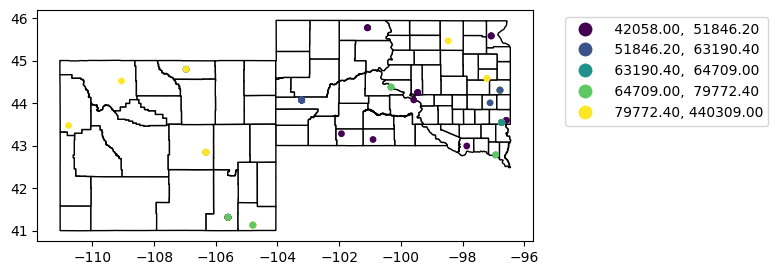

In [83]:
#ax = americanStates[americanStates["STUSPS"].isin(["SD", "WY"])].plot(color="white", edgecolor="black")

ax = americanCounties[americanCounties["STATEFP"].isin(["46", "56"])].plot(color = "white", edgecolor = "black")

gdf.plot(column = "wage_annual", 
    ax=ax, 
    markersize=15, 
    legend = True,
    scheme = "quantiles",
    k = 5,
    legend_kwds={
        "loc": "upper left",
        "bbox_to_anchor": (1.05, 1)
})

In [28]:
WYSDApplicantsGeo["PREVAILING_WAGE"].describe()

count         123
unique         79
top       $30.38 
freq           23
Name: PREVAILING_WAGE, dtype: object

In [29]:
WYSDApplicantsGeo["PW_UNIT_OF_PAY"].value_counts()

PW_UNIT_OF_PAY
Year     87
Hour     34
Month     2
Name: count, dtype: int64

In [39]:
import numpy as np

gdf = WYSDApplicantsGeo.copy()

gdf["PREVAILING_WAGE"] = (
    gdf["PREVAILING_WAGE"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

gdf["PREVAILING_WAGE"] = pd.to_numeric(
    gdf["PREVAILING_WAGE"],
    errors="coerce"
)

gdf["PW_UNIT_OF_PAY"] = (
    gdf["PW_UNIT_OF_PAY"]
    .astype(str)
    .str.strip()
)

def to_annual(row):
    wage = row["PREVAILING_WAGE"]
    unit = row["PW_UNIT_OF_PAY"]

    if pd.isna(wage):
        return None
    if unit == "Hour":
        return wage * 2080
    elif unit == "Week":
        return wage * 52
    elif unit == "Month":
        return wage * 12
    elif unit == "Year":
        return wage
    else:
        return None

gdf["wage_annual"] = gdf.apply(to_annual, axis=1)

gdf = gdf[gdf["wage_annual"].notna()].copy()

gdf["wage_log"] = np.log1p(gdf["wage_annual"])

gdf["city_key"] = (
    gdf["WORKSITE_CITY"]
    .astype(str)
    .str.lower()
    .str.replace(".", "", regex=False)
    .str.strip()
)

gdf["state_key"] = (
    gdf["WORKSITE_STATE"]
    .astype(str)
    .str.upper()
    .str.strip()
)

print("Rows after cleaning:", len(gdf))
print(gdf[["PREVAILING_WAGE", "wage_annual", "wage_log"]].describe())

Rows after cleaning: 123
       PREVAILING_WAGE    wage_annual    wage_log
count       123.000000     123.000000  123.000000
mean      50793.277642   70187.829268   11.093793
std       50421.130302   39391.688358    0.311483
min          21.840000   42058.000000   10.646829
25%          46.215000   55444.000000   10.923147
50%       55435.000000   63190.400000   11.053923
75%       69409.500000   73986.000000   11.211641
max      440309.000000  440309.000000   12.995234


In [43]:
gdf["duration"].value_counts()

duration
1094 days    76
1095 days    32
1093 days     2
1092 days     2
1087 days     2
922 days      1
729 days      1
972 days      1
730 days      1
1072 days     1
1073 days     1
1063 days     1
925 days      1
1083 days     1
Name: count, dtype: int64

Goals:
- wage clustering (Level 1 vs mixed levels)
- job title repetition
- worksite dispersion
- filing volume vs role specificity
- difference of remote work before and after pandemic

# Bivariate Map of Java Developers Salary and Wage Levels

In [4]:
data.columns

Index(['CASE_NUMBER', 'CASE_STATUS', 'RECEIVED_DATE', 'DECISION_DATE',
       'ORIGINAL_CERT_DATE', 'VISA_CLASS', 'JOB_TITLE', 'SOC_CODE',
       'SOC_TITLE', 'FULL_TIME_POSITION', 'BEGIN_DATE', 'END_DATE',
       'TOTAL_WORKER_POSITIONS', 'NEW_EMPLOYMENT', 'CONTINUED_EMPLOYMENT',
       'CHANGE_PREVIOUS_EMPLOYMENT', 'NEW_CONCURRENT_EMPLOYMENT',
       'CHANGE_EMPLOYER', 'AMENDED_PETITION', 'EMPLOYER_NAME',
       'TRADE_NAME_DBA', 'EMPLOYER_ADDRESS1', 'EMPLOYER_ADDRESS2',
       'EMPLOYER_CITY', 'EMPLOYER_STATE', 'EMPLOYER_POSTAL_CODE',
       'EMPLOYER_COUNTRY', 'EMPLOYER_PROVINCE', 'EMPLOYER_PHONE',
       'EMPLOYER_PHONE_EXT', 'EMPLOYER_FEIN', 'NAICS_CODE',
       'EMPLOYER_POC_LAST_NAME', 'EMPLOYER_POC_FIRST_NAME',
       'EMPLOYER_POC_MIDDLE_NAME', 'EMPLOYER_POC_JOB_TITLE',
       'EMPLOYER_POC_ADDRESS1', 'EMPLOYER_POC_ADDRESS2', 'EMPLOYER_POC_CITY',
       'EMPLOYER_POC_STATE', 'EMPLOYER_POC_POSTAL_CODE',
       'EMPLOYER_POC_COUNTRY', 'EMPLOYER_POC_PROVINCE', 'EMPLOYER_POC_PHON

In [5]:
filteredData = data[
    (data['VISA_CLASS'] == 'H-1B') &
    (data['CASE_STATUS'] == 'Certified') &
    (data['FULL_TIME_POSITION'] == 'Y')
].copy()

In [78]:
searchTitle = filteredData[['CASE_NUMBER', 'JOB_TITLE', 'SOC_TITLE', 'SOC_CODE',
                            'WAGE_RATE_OF_PAY_FROM', 'WAGE_RATE_OF_PAY_TO', 'WAGE_UNIT_OF_PAY',
                            'PREVAILING_WAGE', 'PW_UNIT_OF_PAY', 'PW_WAGE_LEVEL',
                            'WORKSITE_COUNTY', 'WORKSITE_STATE']].dropna()

In [79]:
javaDevs = searchTitle[searchTitle['JOB_TITLE'].str.lower().str.contains('java') &
                       (searchTitle['PW_UNIT_OF_PAY'] == 'Year') &
                       (searchTitle['WAGE_UNIT_OF_PAY'] == 'Year')]

In [82]:
javaDevs['SOC_CODE'].value_counts()

SOC_CODE
15-1252.00    163
15-1251.00     28
15-1254.00      4
15-1211.00      2
15-1299.08      2
15-1253.00      2
15-1255.00      1
15-1232.00      1
15-1299.00      1
15-1252         1
Name: count, dtype: int64

In [57]:
javaDevs['WAGE_RATE_DIFF'] = (javaDevs['WAGE_RATE_OF_PAY_TO']
                              .str.replace('[$, ]', '', regex = True).astype(float) - 
                              javaDevs['WAGE_RATE_OF_PAY_FROM']
                              .str.replace('[$, ]', '', regex = True).astype(float))

C:\Users\eagle\AppData\Local\Temp\ipykernel_44376\3320283266.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  javaDevs['WAGE_RATE_DIFF'] = (javaDevs['WAGE_RATE_OF_PAY_TO']


In [58]:
javaDevs['WAGE_RATE_DIFF'] = np.where(javaDevs['WAGE_RATE_DIFF'] > 1000, 
                                      javaDevs['WAGE_RATE_DIFF'], 
                                      0)

C:\Users\eagle\AppData\Local\Temp\ipykernel_44376\2712541307.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  javaDevs['WAGE_RATE_DIFF'] = np.where(javaDevs['WAGE_RATE_DIFF'] > 1000,


In [66]:
javaDevs['AWPW_DIFF'] = (javaDevs['WAGE_RATE_OF_PAY_FROM']
                         .str.replace('[$, ]', '', regex = True).astype(float) -
                         javaDevs['PREVAILING_WAGE']
                         .str.replace('[$, ]', '', regex = True).astype(float))

C:\Users\eagle\AppData\Local\Temp\ipykernel_44376\4041181409.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  javaDevs['AWPW_DIFF'] = (javaDevs['WAGE_RATE_OF_PAY_FROM']


In [68]:
javaDevs['WAGE_MIN'] = javaDevs['WAGE_RATE_OF_PAY_FROM'].str.replace('[$, ]', '', regex = True).astype(float)

C:\Users\eagle\AppData\Local\Temp\ipykernel_44376\3185831455.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  javaDevs['WAGE_MIN'] = javaDevs['WAGE_RATE_OF_PAY_FROM'].str.replace('[$, ]', '', regex = True).astype(float)


In [69]:
javaDevs

,CASE_NUMBER,JOB_TITLE,SOC_TITLE,WAGE_RATE_OF_PAY_FROM,WAGE_RATE_OF_PAY_TO,WAGE_UNIT_OF_PAY,PREVAILING_WAGE,PW_UNIT_OF_PAY,PW_WAGE_LEVEL,WORKSITE_COUNTY,WORKSITE_STATE,WAGE_RATE_DIFF,AWPW_DIFF,WAGE_MIN
34,I-200-24358-566665,Java Developer,Software Developers,"$70,699.00","$70,700.00",Year,"$70,699.00",Year,I,INGHAM,MI,0.0,0.0,70699.0
694,I-200-24356-566260,"Senior Associate, Software Engineering: Java",Software Developers,"$117,300.00","$162,200.00",Year,"$105,997.00",Year,II,DALLAS,TX,44900.0,11303.0,117300.0
854,I-200-24355-562650,Staff Engineer - Java,Software Developers,"$149,781.00","$230,000.00",Year,"$149,781.00",Year,IV,DENTON,TX,80219.0,0.0,149781.0
2283,I-200-24355-562668,Java Backend Engineer,Software Developers,"$112,986.00","$113,000.00",Year,"$112,986.00",Year,II,MECKLENBURG,NC,0.0,0.0,112986.0
3002,I-200-24354-560076,Java Developer,Software Developers,"$96,387.00","$96,400.00",Year,"$96,387.00",Year,II,SALT LAKE,UT,0.0,0.0,96387.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104943,I-200-24269-364821,Java Developer,Software Developers,"$105,976.00","$105,977.00",Year,"$105,976.00",Year,II,MARICOPA,AZ,0.0,0.0,105976.0
105671,I-200-24268-362024,JAVA FULL STACK DEVELOPER,Software Developers,"$84,094.00","$84,095.00",Year,"$84,094.00",Year,I,COLLIN,TX,0.0,0.0,84094.0
105701,I-200-24268-361109,Java Developer,Software Developers,"$97,157.00","$97,160.00",Year,"$97,157.00",Year,I,MANASSAS CITY,VA,0.0,0.0,97157.0
105882,I-200-24268-360625,Staff Engineer - Java,Software Developers,"$155,709.00","$225,000.00",Year,"$155,709.00",Year,IV,WILLIAMSON,TX,69291.0,0.0,155709.0


In [85]:
javaWageAmtLvl = javaDevs[['WAGE_MIN', 'WAGE_RATE_DIFF', 'AWPW_DIFF', 'PW_WAGE_LEVEL',
                           'WORKSITE_COUNTY', 'WORKSITE_STATE']]

KeyError: "['WAGE_MIN', 'WAGE_RATE_DIFF', 'AWPW_DIFF'] not in index"

In [76]:
javaWageAmtLvl

,WAGE_MIN,WAGE_RATE_DIFF,AWPW_DIFF,PW_WAGE_LEVEL,WORKSITE_COUNTY,WORKSITE_STATE
34,70699.0,0.0,0.0,I,INGHAM,MI
694,117300.0,44900.0,11303.0,II,DALLAS,TX
854,149781.0,80219.0,0.0,IV,DENTON,TX
2283,112986.0,0.0,0.0,II,MECKLENBURG,NC
3002,96387.0,0.0,0.0,II,SALT LAKE,UT
...,...,...,...,...,...,...
104943,105976.0,0.0,0.0,II,MARICOPA,AZ
105671,84094.0,0.0,0.0,I,COLLIN,TX
105701,97157.0,0.0,0.0,I,MANASSAS CITY,VA
105882,155709.0,69291.0,0.0,IV,WILLIAMSON,TX


In [ ]:
javaWageAmtLvl['WAGE_LEVEL_NUM'] = javaWageAmtLvl['PW_WAGE_LEVEL'].map({
    'I': 1,
    'II': 2,
    'III': 3,
    'IV': 4
})

C:\Users\eagle\AppData\Local\Temp\ipykernel_44376\1621673735.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  javaWageAmtLvl['WAGE_LEVEL_NUM'] = javaDevs['PW_WAGE_LEVEL'].map({


In [86]:
javaWageAmtLvl

,WAGE_MIN,WAGE_RATE_DIFF,AWPW_DIFF,PW_WAGE_LEVEL,WORKSITE_COUNTY,WORKSITE_STATE,WAGE_LEVEL_NUM
34,70699.0,0.0,0.0,I,INGHAM,MI,1
694,117300.0,44900.0,11303.0,II,DALLAS,TX,2
854,149781.0,80219.0,0.0,IV,DENTON,TX,4
2283,112986.0,0.0,0.0,II,MECKLENBURG,NC,2
3002,96387.0,0.0,0.0,II,SALT LAKE,UT,2
...,...,...,...,...,...,...,...
104943,105976.0,0.0,0.0,II,MARICOPA,AZ,2
105671,84094.0,0.0,0.0,I,COLLIN,TX,1
105701,97157.0,0.0,0.0,I,MANASSAS CITY,VA,1
105882,155709.0,69291.0,0.0,IV,WILLIAMSON,TX,4


In [88]:
javaWageAmtLvlGrp = javaWageAmtLvl.groupby(['WORKSITE_COUNTY', 'WORKSITE_STATE']).agg({
    'WAGE_MIN': ['mean', 'max', 'min'],
    'WAGE_LEVEL_NUM': ['mean', 'max', 'min']
}).reset_index()

In [ ]:
javaWageAmtLvlGrp

WORKSITE_COUNTY WORKSITE_STATE  WAGE_MIN                      \
                                       mean       max       min   
0           ALBANY             NY   93538.0   93538.0   93538.0   
1        ALLEGHENY             PA   74734.0   74734.0   74734.0   
2     ANNE ARUNDEL             MD  124738.0  124738.0  124738.0   
3        BALTIMORE             MD  122335.5  124738.0  119933.0   
4           BENTON             AR  105976.0  105976.0  105976.0   
..             ...            ...       ...       ...       ...   
74           UNION             NJ  123656.0  123656.0  123656.0   
75            WAKE             NC   99026.0  109300.0   86500.0   
76           WAYNE             MI  141240.0  141240.0  141240.0   
77      WILLIAMSON             TX  114883.1  155709.0   64459.0   
78  WORCESTER CITY             MA  111758.0  111758.0  111758.0   

   WAGE_LEVEL_NUM          
             mean max min  
0            2.00   2   2  
1            2.00   2   2  
2            2.00   2   2  
3            2.50   3   2  
4            2.00   2   2  
..            ...  ..  ..  
74           2.00   2   2  
75           1.75   2   1  
76           4.00   4   4  
77           2.30   4   1  
78           2.00   2   2  

[79 rows x 8 columns]

: 

# Let's try selecting all data

In [3]:
HDir = r'C:\Users\eagle\OneDrive\Documents\Data\H1B\CSV'

In [10]:
file_paths = [
    os.path.join(HDir, f)
    for f in os.listdir(HDir)
    if os.path.isfile(os.path.join(HDir, f))
]

In [15]:
import csv
from pathlib import Path

input_dir = Path(HDir)

for file in input_dir.glob("*.csv"):
    with open(file, newline="", encoding="utf-8-sig") as f:  # handles BOM
        reader = csv.reader(f)
        header = next(reader)
        print(file.name, header)

H-1B_Case_Data_FY2008.csv ['SUBMITTED_DATE', 'CASE_NO', 'PROGRAM', 'NAME', 'ADDRESS1', 'ADDRESS2', 'CITY', 'STATE', 'POSTAL_CODE', 'NBR_IMMIGRANTS', 'BEGIN_DATE', 'END_DATE', 'JOB_TITLE', 'DOL_DECISION_DATE', 'CERTIFIED_BEGIN_DATE', 'CERTIFIED_END_DATE', 'JOB_CODE', 'APPROVAL_STATUS', 'WAGE_RATE_1', 'RATE_PER_1', 'MAX_RATE_1', 'PART_TIME_1', 'CITY_1', 'STATE_1', 'PREVAILING_WAGE_1', 'WAGE_SOURCE_1', 'YR_SOURCE_PUB_1', 'OTHER_WAGE_SOURCE_1', 'WAGE_RATE_2', 'RATE_PER_2', 'MAX_RATE_2', 'PART_TIME_2', 'CITY_2', 'STATE_2', 'PREVAILING_WAGE_2', 'WAGE_SOURCE_2', 'YR_SOURCE_PUB_2', 'OTHER_WAGE_SOURCE_2', 'WITHDRAWN', 'OCCUPATIONAL_TITLE']
H-1B_Case_Data_FY2009.csv ['SUBMITTED_DATE', 'CASE_NO', 'PROGRAM_DESIGNATION', 'EMPLOYER_NAME', 'EMPLOYER_ADDRESS1', 'EMPLOYER_ADDRESS2', 'EMPLOYER_CITY', 'EMPLOYER_STATE', 'EMPLOYER_COUNTY', 'EMPLOYER_POSTAL_CODE', 'NBR_IMMIGRANTS', 'BEGIN_DATE', 'END_DATE', 'JOB_TITLE', 'DOL_DECISION_DATE', 'OCCUPATIONAL_CODE', 'OCCUPATIONAL_TITLE', 'APPROVAL_STATUS', 'WAGE

In [16]:
CANONICAL_FIELDS = [
    "start_date",
    "job_title",
    "job_code",
    "employer_city",
    "employer_county",
    "employer_state",
    "worksite_city",
    "worksite_county",
    "worksite_state",
    "num_workers",
    "wage_min",
    "wage_unit",
    "prevailing_wage",
    "prevailing_wage_level"
]

In [20]:
MAPPING = {
    "start_date": [
        "BEGIN_DATE",
        "EMPLOYMENT_START_DATE",
        "PERIOD_OF_EMPLOYMENT_START_DATE",
        "LCA_CASE_EMPLOYMENT_START_DATE"
    ],

    "job_title": [
        "JOB_TITLE",
        "LCA_CASE_JOB_TITLE"
    ],

    "job_code": [
        "SOC_CODE",
        "JOB_CODE",
        "LCA_CASE_SOC_CODE",
        "OCCUPATIONAL_CODE"
    ],

    "employer_city": [
        "EMPLOYER_CITY",
        "LCA_CASE_EMPLOYER_CITY",
        "CITY"
    ],

    "employer_state": [
        "EMPLOYER_STATE",
        "LCA_CASE_EMPLOYER_STATE",
        "STATE"
    ],

    "worksite_city": [
        "WORKSITE_CITY",
        "WORKSITE_CITY_1",
        "LCA_CASE_WORKLOC1_CITY",
        "WORK_LOCATION_CITY1",
        "CITY_1"
    ],

    "worksite_county": [
        "WORKSITE_COUNTY",
        "WORKSITE_COUNTY_1"
    ],

    "worksite_state": [
        "WORKSITE_STATE",
        "WORKSITE_STATE_1",
        "LCA_CASE_WORKLOC1_STATE",
        "WORK_LOCATION_STATE1",
        "STATE_1"
    ],

    "num_workers": [
        "TOTAL_WORKERS",
        "TOTAL WORKERS",
        "TOTAL_WORKER_POSITIONS",
        "NBR_IMMIGRANTS"
    ],

    "wage_min": [
        "WAGE_RATE_OF_PAY_FROM",
        "WAGE_RATE_OF_PAY",
        "WAGE_RATE_1",
        "LCA_CASE_WAGE_RATE_FROM"
    ],

    "wage_unit": [
        "WAGE_UNIT_OF_PAY",
        "PW_UNIT_OF_PAY",
        "RATE_PER_1",
        "LCA_CASE_WAGE_RATE_UNIT"
    ],

    "prevailing_wage": [
        "PREVAILING_WAGE",
        "PREVAILING_WAGE_1",
        "PW_1"
    ],

    "prevailing_wage_level": [
        "PW_WAGE_LEVEL",
        "PW_WAGE_LEVEL_1"
    ]
}

In [21]:
def resolve_columns(header, mapping):
    header_set = set(header)
    resolved = {}

    for canon, options in mapping.items():
        for col in options:
            if col in header_set:
                resolved[canon] = col
                break
        else:
            resolved[canon] = None  # not found

    return resolved

In [22]:
import csv
from pathlib import Path

input_dir = Path(HDir)

for file in input_dir.glob("*.csv"):
    with open(file, newline="", encoding="utf-8-sig") as f:
        reader = csv.reader(f)
        header = next(reader)

        mapping = resolve_columns(header, MAPPING)

        print("\n", file.name)
        for k, v in mapping.items():
            print(f"{k:25} -> {v}")


 H-1B_Case_Data_FY2008.csv
start_date                -> BEGIN_DATE
job_title                 -> JOB_TITLE
job_code                  -> JOB_CODE
employer_city             -> CITY
employer_state            -> STATE
worksite_city             -> CITY_1
worksite_county           -> None
worksite_state            -> STATE_1
num_workers               -> NBR_IMMIGRANTS
wage_min                  -> WAGE_RATE_1
wage_unit                 -> RATE_PER_1
prevailing_wage           -> PREVAILING_WAGE_1
prevailing_wage_level     -> None

 H-1B_Case_Data_FY2009.csv
start_date                -> BEGIN_DATE
job_title                 -> JOB_TITLE
job_code                  -> OCCUPATIONAL_CODE
employer_city             -> EMPLOYER_CITY
employer_state            -> EMPLOYER_STATE
worksite_city             -> CITY_1
worksite_county           -> None
worksite_state            -> STATE_1
num_workers               -> NBR_IMMIGRANTS
wage_min                  -> WAGE_RATE_1
wage_unit                 -> RATE_PER_1


# Consider Value-by-Alpha

# Let's check out BLS data

In [3]:
may2024Path = r'C:\Users\eagle\OneDrive\Documents\Data\OES\oesm24st\state_M2024_dl.xlsx'
may2024CSVOutPath = r'C:\Users\eagle\OneDrive\Documents\Data\OES\oesm24st\state_M2024_dl.csv'

In [4]:
df = pd.read_excel(may2024Path)
df.to_csv(may2024CSVOutPath, index=False)

In [150]:
df = pd.read_csv(may2024CSVOutPath, dtype={"OCC_CODE": str, "AREA": str})

cols = ["AREA", "AREA_TITLE", "PRIM_STATE", "O_GROUP", "OCC_CODE", "TOT_EMP"]
df = df[cols]

In [151]:
df["SOC2"] = df["OCC_CODE"].str[:2]

In [152]:
df = df[df["OCC_CODE"] != "00-0000"]

In [153]:
df = df[df["TOT_EMP"].str.isnumeric()]

In [154]:
df['TOT_EMP'] = df['TOT_EMP'].astype(int)

In [155]:
agg = (
    df[df['O_GROUP'] == 'detailed']
    .groupby(["PRIM_STATE", "SOC2"], as_index=False)
    .agg({
        "TOT_EMP": "sum"
    })
)

In [156]:
agg

,PRIM_STATE,SOC2,TOT_EMP
0,AK,11,25440
1,AK,13,12410
2,AK,15,4990
3,AK,17,7130
4,AK,19,6520
...,...,...,...
1180,WY,45,670
1181,WY,47,25130
1182,WY,49,17360
1183,WY,51,13020


In [157]:
soc_agg = (
    agg
    .groupby(["SOC2"], as_index=False)
    .agg({
        "TOT_EMP": "sum"
    })
)

In [158]:
soc_agg.sort_values("TOT_EMP", ascending=False).head(10)

,SOC2,TOT_EMP
16,43,18332830
12,35,13662440
21,53,13599880
15,41,13398270
0,11,10747450
1,13,10412520
9,29,9546730
7,25,8944390
20,51,8733150
10,31,7462810


In [159]:
soc2_map = {
    "11": "Management",
    "13": "Business & Financial",
    "15": "Computer & Mathematical",
    "17": "Architecture & Engineering",
    "19": "Life, Physical & Social Science",
    "21": "Community & Social Service",
    "23": "Legal",
    "25": "Education",
    "27": "Arts, Design, Entertainment",
    "29": "Healthcare Practitioners",
    "31": "Healthcare Support",
    "33": "Protective Service",
    "35": "Food Preparation",
    "37": "Building & Grounds",
    "39": "Personal Care",
    "41": "Sales",
    "43": "Office Support",
    "45": "Farming, Fishing, Forestry",
    "47": "Construction",
    "49": "Installation, Maintenance, Repair",
    "51": "Production",
    "53": "Transportation",
    "55": "Military"
}

In [160]:
import matplotlib.pyplot as plt

In [161]:
soc_agg.sort_values("TOT_EMP", ascending=False).head(15)

,SOC2,TOT_EMP
16,43,18332830
12,35,13662440
21,53,13599880
15,41,13398270
0,11,10747450
1,13,10412520
9,29,9546730
7,25,8944390
20,51,8733150
10,31,7462810


Text(0, 0.5, '')

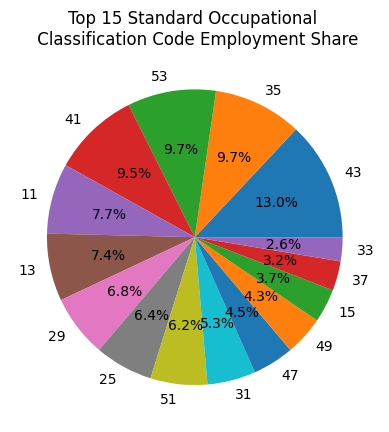

In [79]:
ax = (
    soc_agg.sort_values("TOT_EMP", ascending=False)
    .head(15)
    .plot.pie(
        y="TOT_EMP",
        labels=soc_agg.sort_values("TOT_EMP", ascending=False).head(15)["SOC2"],
        autopct='%1.1f%%',
        legend=False
    )
)

ax.set_title("Top 15 Standard Occupational \n Classification Code Employment Share")
ax.set_ylabel("")

In [30]:
H1B2024Path = r'C:\Users\eagle\OneDrive\Documents\Data\H1B\CSV'

In [31]:
file_pattern = os.path.join(H1B2024Path, "LCA_Disclosure_Data_FY2024_Q*.csv")

In [32]:
import glob

In [33]:
files = sorted(glob.glob(file_pattern))

In [ ]:
df_list = []

for file in files:
    df = pd.read_csv(file, dtype=str)
    df["source_file"] = os.path.basename(file)
    df_list.append(df)

lca_2024 = pd.concat(df_list, ignore_index=True)

In [47]:
lca_2024.columns

Index(['CASE_NUMBER', 'CASE_STATUS', 'RECEIVED_DATE', 'DECISION_DATE',
       'ORIGINAL_CERT_DATE', 'VISA_CLASS', 'JOB_TITLE', 'SOC_CODE',
       'SOC_TITLE', 'FULL_TIME_POSITION', 'BEGIN_DATE', 'END_DATE',
       'TOTAL_WORKER_POSITIONS', 'NEW_EMPLOYMENT', 'CONTINUED_EMPLOYMENT',
       'CHANGE_PREVIOUS_EMPLOYMENT', 'NEW_CONCURRENT_EMPLOYMENT',
       'CHANGE_EMPLOYER', 'AMENDED_PETITION', 'EMPLOYER_NAME',
       'TRADE_NAME_DBA', 'EMPLOYER_ADDRESS1', 'EMPLOYER_ADDRESS2',
       'EMPLOYER_CITY', 'EMPLOYER_STATE', 'EMPLOYER_POSTAL_CODE',
       'EMPLOYER_COUNTRY', 'EMPLOYER_PROVINCE', 'EMPLOYER_PHONE',
       'EMPLOYER_PHONE_EXT', 'EMPLOYER_FEIN', 'NAICS_CODE',
       'EMPLOYER_POC_LAST_NAME', 'EMPLOYER_POC_FIRST_NAME',
       'EMPLOYER_POC_MIDDLE_NAME', 'EMPLOYER_POC_JOB_TITLE',
       'EMPLOYER_POC_ADDRESS1', 'EMPLOYER_POC_ADDRESS2', 'EMPLOYER_POC_CITY',
       'EMPLOYER_POC_STATE', 'EMPLOYER_POC_POSTAL_CODE',
       'EMPLOYER_POC_COUNTRY', 'EMPLOYER_POC_PROVINCE', 'EMPLOYER_POC_PHON

In [48]:
lca_2024_summ = lca_2024[(lca_2024['CASE_STATUS'] == 'Certified') & (lca_2024['VISA_CLASS'] == 'H-1B')][['WORKSITE_STATE', 'SOC_CODE', 'WORKSITE_WORKERS']]

In [49]:
lca_2024_summ['SOC2'] = lca_2024_summ['SOC_CODE'].str[:2]

In [52]:
lca_2024_summ['WORKSITE_WORKERS'] = pd.to_numeric(lca_2024_summ['WORKSITE_WORKERS'], errors='coerce')

In [53]:
lca_2024_agg = (
    lca_2024_summ
    .groupby(['WORKSITE_STATE', 'SOC2'], as_index=False)
    .agg({'WORKSITE_WORKERS': 'sum'})
)

In [54]:
lca_2024_agg

,WORKSITE_STATE,SOC2,WORKSITE_WORKERS
0,AK,11,10
1,AK,13,4
2,AK,15,3
3,AK,17,9
4,AK,19,7
...,...,...,...
715,WY,21,2
716,WY,25,26
717,WY,27,1
718,WY,29,37


In [55]:
lca_soc_agg = (
    lca_2024_agg
    .groupby('SOC2', as_index=False)
    .agg({'WORKSITE_WORKERS': 'sum'})
)

In [67]:
lca_soc_agg.sort_values('WORKSITE_WORKERS', ascending=False).head(5)

,SOC2,WORKSITE_WORKERS
3,15,486722
4,17,73924
2,13,59042
12,29,43071
0,11,39326


<Axes: ylabel='WORKSITE_WORKERS'>

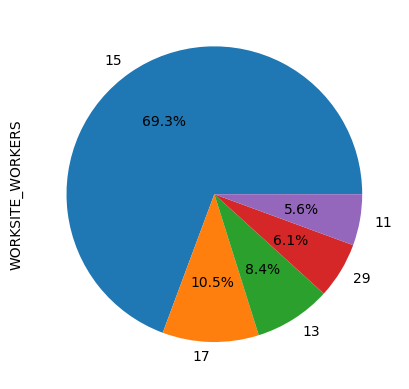

In [75]:
(lca_soc_agg
 .sort_values("WORKSITE_WORKERS", ascending=False)
 .head(5)
 .plot.pie(y="WORKSITE_WORKERS", 
           labels=lca_soc_agg.sort_values("WORKSITE_WORKERS", ascending=False).head(5)["SOC2"], 
           autopct='%1.1f%%', 
           legend = False))

In [58]:
bls_uscis_agg = merged = pd.merge(lca_soc_agg, soc_agg, on="SOC2", how="outer")

In [59]:
bls_uscis_agg

,SOC2,WORKSITE_WORKERS,TOT_EMP
0,11,39326,21760830.0
1,12,4,NaN
2,13,59042,20836160.0
3,15,486722,10386040.0
4,17,73924,5126510.0
5,19,22486,2864350.0
6,20,1,NaN
7,21,2331,5145560.0
8,23,2515,2531860.0
9,24,3,NaN


In [60]:
bls_uscis_agg.dropna()

,SOC2,WORKSITE_WORKERS,TOT_EMP
0,11,39326,21760830.0
2,13,59042,20836160.0
3,15,486722,10386040.0
4,17,73924,5126510.0
5,19,22486,2864350.0
7,21,2331,5145560.0
8,23,2515,2531860.0
10,25,19519,17955130.0
11,27,5507,4166710.0
12,29,43071,19198860.0


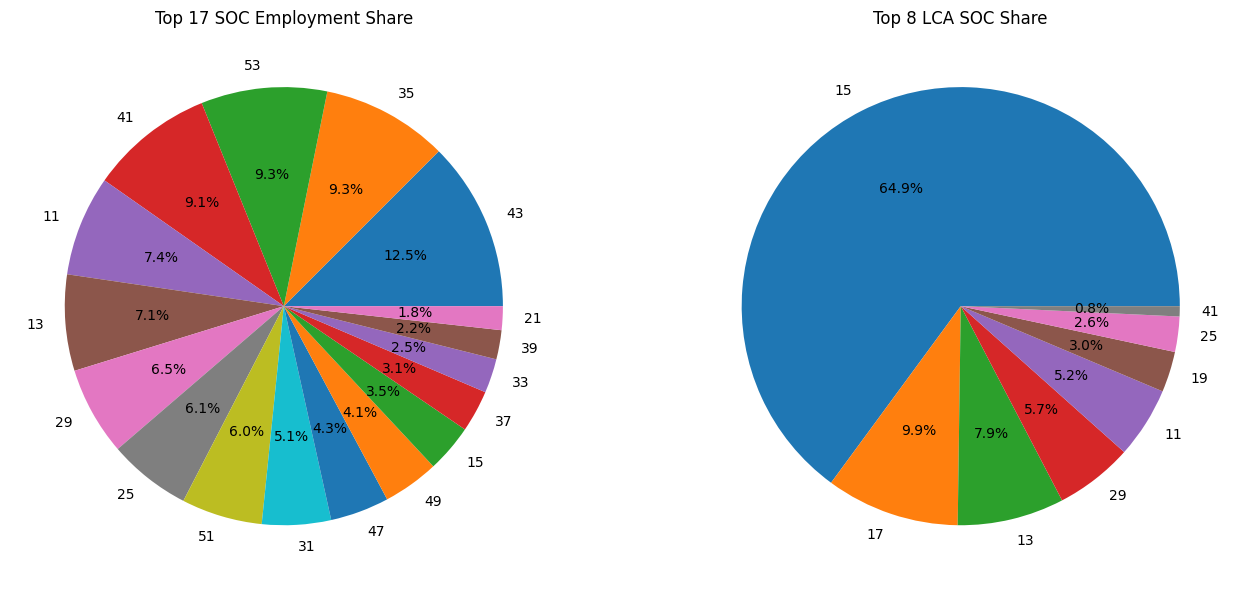

In [86]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: SOC employment ---
soc_top17 = soc_agg.sort_values("TOT_EMP", ascending=False).head(17)

soc_top17.plot.pie(
    y="TOT_EMP",
    labels=soc_top17["SOC2"],
    autopct='%1.1f%%',
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Top 17 SOC Employment Share")
axes[0].set_ylabel("")

# --- Right: LCA employment ---
lca_top8 = lca_soc_agg.sort_values("WORKSITE_WORKERS", ascending=False).head(8)

lca_top8.plot.pie(
    y="WORKSITE_WORKERS",
    labels=lca_top8["SOC2"],
    autopct='%1.1f%%',
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Top 8 LCA SOC Share")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [87]:
all_soc = pd.concat([
    soc_top17["SOC2"],
    lca_top8["SOC2"]
]).unique()

colors = plt.cm.tab20.colors  # stable categorical palette

color_map = {soc: colors[i % len(colors)] for i, soc in enumerate(all_soc)}

In [88]:
soc_colors = soc_top17["SOC2"].map(color_map)
lca_colors = lca_top8["SOC2"].map(color_map)

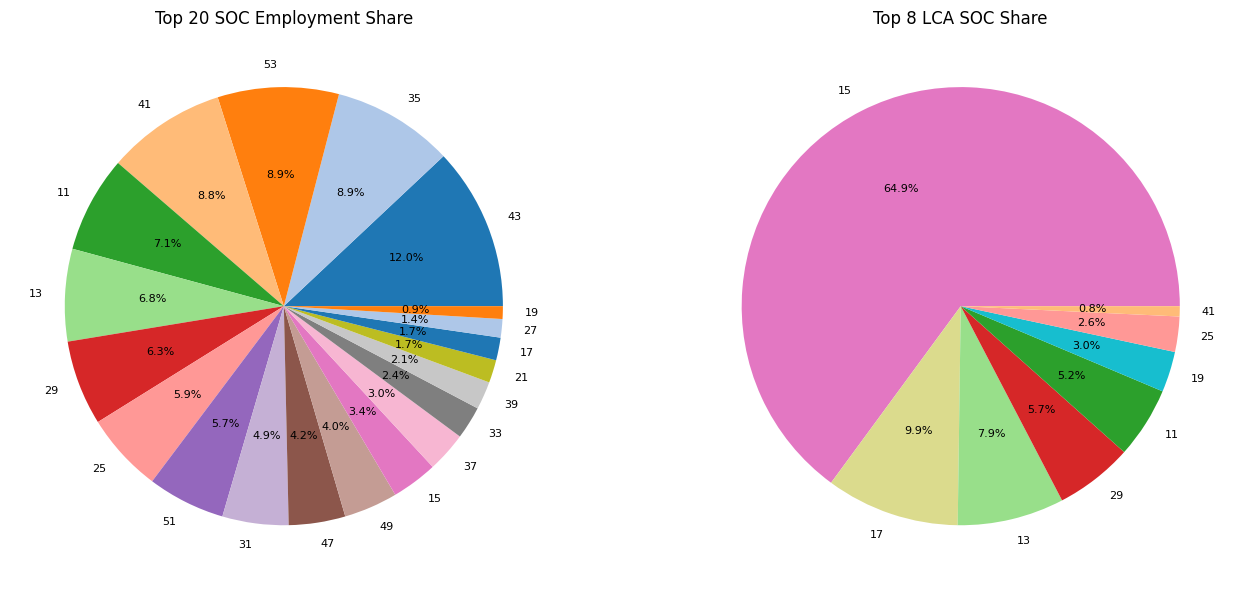

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

soc_top20 = soc_agg.sort_values("TOT_EMP", ascending=False).head(20)

soc_top20.plot.pie(
    y="TOT_EMP",
    labels=soc_top20["SOC2"],
    colors=soc_colors,
    autopct='%1.1f%%',
    textprops={'fontsize': 8},
    ax=axes[0],
    legend=False
)

axes[0].set_title("Top 20 SOC Employment Share")
axes[0].set_ylabel("")

lca_top8 = lca_soc_agg.sort_values("WORKSITE_WORKERS", ascending=False).head(8)

lca_top8.plot.pie(
    y="WORKSITE_WORKERS",
    labels=lca_top8["SOC2"],
    colors=lca_colors,
    autopct='%1.1f%%',
    textprops={'fontsize': 8},
    ax=axes[1],
    legend=False
)

axes[1].set_title("Top 8 LCA SOC Share")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

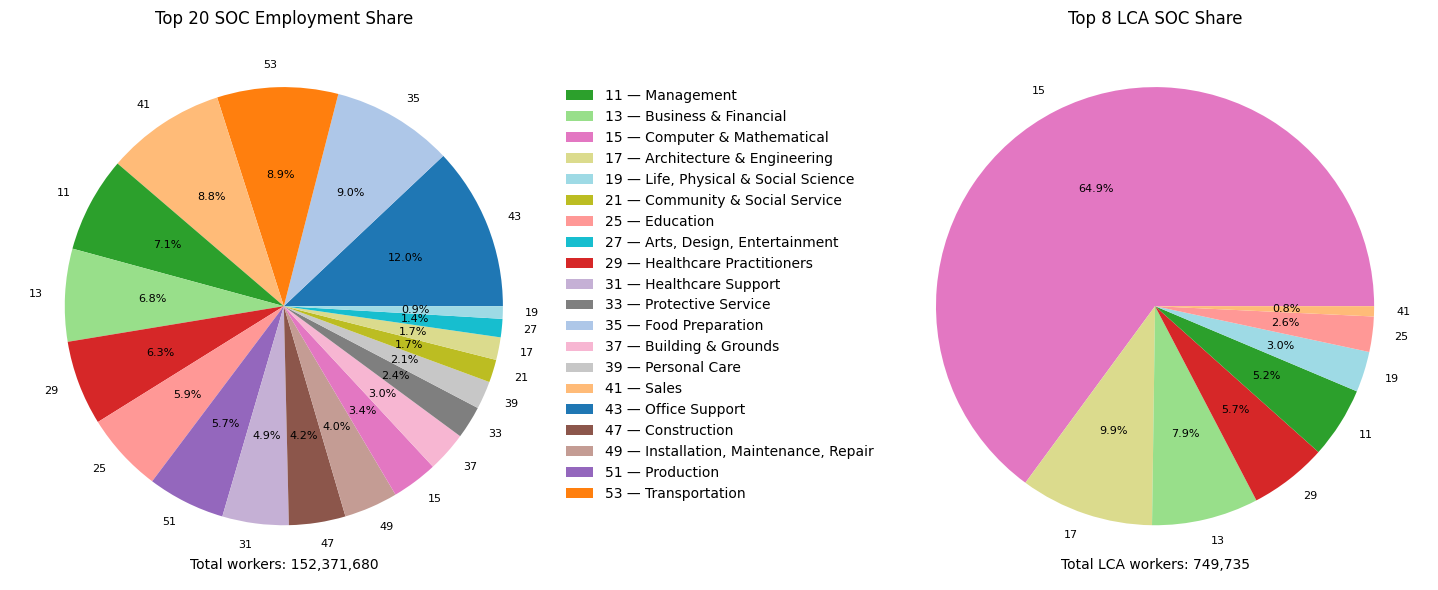

In [162]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# --- data ---
soc_top20 = soc_agg.sort_values("TOT_EMP", ascending=False).head(20)
lca_top8 = lca_soc_agg.sort_values("WORKSITE_WORKERS", ascending=False).head(8)

# --- pies ---
soc_top20.plot.pie(
    y="TOT_EMP",
    labels=soc_top20["SOC2"],
    colors=soc_colors,
    autopct='%1.1f%%',
    textprops={'fontsize': 8},
    ax=axes[0],
    legend=False
)

axes[0].set_title("Top 20 SOC Employment Share")
axes[0].set_ylabel("")

lca_top8.plot.pie(
    y="WORKSITE_WORKERS",
    labels=lca_top8["SOC2"],
    colors=lca_colors,
    autopct='%1.1f%%',
    textprops={'fontsize': 8},
    ax=axes[1],
    legend=False
)

axes[1].set_title("Top 8 LCA SOC Share")
axes[1].set_ylabel("")

all_soc = pd.concat([
    soc_top17["SOC2"],
    lca_top8["SOC2"]
]).unique()

from matplotlib.patches import Patch

legend_handles = [
    Patch(
        facecolor=color_map[soc.astype(str)],
        label=f"{soc} — {soc2_map.get(soc.astype(str), 'Unknown')}"
    )
    for soc in sorted(all_soc.astype(int))
]

fig.legend(
    handles=legend_handles,
    loc="center",
    ncol=1,
    frameon=False
)

soc_total = soc_top20["TOT_EMP"].sum()
lca_total = lca_top8["WORKSITE_WORKERS"].sum()

axes[0].text(
    0, -1.2,
    f"Total workers: {soc_total:,.0f}",
    ha="center",
    fontsize=10
)

axes[1].text(
    0, -1.2,
    f"Total LCA workers: {lca_total:,.0f}",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()
fig.savefig(r"C:\Users\eagle\OneDrive\Documents\Data\soc_lca_2024_pie.png", dpi=300)

In [123]:
soc_agg["TOT_EMP"].sum()

np.int64(309288880)

In [125]:
df = pd.read_csv(may2024CSVOutPath)

In [142]:
df[df['O_GROUP'] == 'total'][['TOT_EMP']].astype(int).sum()

TOT_EMP    155229230
dtype: int64

In [171]:
americanStatesPath

'C:\\Users\\eagle\\OneDrive\\Documents\\Data\\cb_2018_us_state_500k\\cb_2018_us_state_500k.shp'

In [182]:
agg

,PRIM_STATE,SOC2,TOT_EMP
0,AK,11,25440
1,AK,13,12410
2,AK,15,4990
3,AK,17,7130
4,AK,19,6520
...,...,...,...
1180,WY,45,670
1181,WY,47,25130
1182,WY,49,17360
1183,WY,51,13020


In [184]:
lca_2024_agg[lca_2024_agg['SOC2'].isin(['11', '13', '15', '17', '19', '25', '29'])]

,WORKSITE_STATE,SOC2,WORKSITE_WORKERS
0,AK,11,10
1,AK,13,4
2,AK,15,3
3,AK,17,9
4,AK,19,7
...,...,...,...
712,WY,15,143
713,WY,17,67
714,WY,19,8
716,WY,25,26


In [173]:
states = gpd.read_file(americanStatesPath)

states = states[["STUSPS", "geometry"]]

In [216]:
states

,STUSPS,geometry
0,MS,"MULTIPOLYGON (((-88.50297 30.21524, -88.49176 ..."
1,NC,"MULTIPOLYGON (((-75.72681 35.93584, -75.71827 ..."
2,OK,"POLYGON ((-103.00256 36.52659, -103.00219 36.6..."
3,VA,"MULTIPOLYGON (((-75.74241 37.80835, -75.74151 ..."
4,WV,"POLYGON ((-82.6432 38.16909, -82.643 38.16956,..."
5,LA,"MULTIPOLYGON (((-88.8677 29.86155, -88.86566 2..."
6,MI,"MULTIPOLYGON (((-83.19159 42.03537, -83.18993 ..."
7,MA,"MULTIPOLYGON (((-70.23405 41.28565, -70.22361 ..."
8,ID,"POLYGON ((-117.24267 44.39655, -117.23484 44.3..."
9,FL,"MULTIPOLYGON (((-80.17628 25.52505, -80.17395 ..."


In [175]:
agg_geo = agg.merge(
    states,
    left_on="PRIM_STATE",
    right_on="STUSPS",
    how="left"
)

lca_geo = lca_2024_agg.merge(
    states,
    left_on="WORKSITE_STATE",
    right_on="STUSPS",
    how="left"
)

In [219]:
lca_geo

,WORKSITE_STATE,SOC2,WORKSITE_WORKERS,STUSPS,geometry
0,AK,11,10,AK,"MULTIPOLYGON (((179.48246 51.98283, 179.48656 ..."
1,AK,13,4,AK,"MULTIPOLYGON (((179.48246 51.98283, 179.48656 ..."
2,AK,15,3,AK,"MULTIPOLYGON (((179.48246 51.98283, 179.48656 ..."
3,AK,17,9,AK,"MULTIPOLYGON (((179.48246 51.98283, 179.48656 ..."
4,AK,19,7,AK,"MULTIPOLYGON (((179.48246 51.98283, 179.48656 ..."
...,...,...,...,...,...
715,WY,21,2,WY,"POLYGON ((-111.05456 45.00096, -111.04507 45.0..."
716,WY,25,26,WY,"POLYGON ((-111.05456 45.00096, -111.04507 45.0..."
717,WY,27,1,WY,"POLYGON ((-111.05456 45.00096, -111.04507 45.0..."
718,WY,29,37,WY,"POLYGON ((-111.05456 45.00096, -111.04507 45.0..."


In [179]:
agg_geo = gpd.GeoDataFrame(
    agg_geo,
    geometry="geometry"
)

lca_geo = gpd.GeoDataFrame(
    lca_geo,
    geometry="geometry"
)

In [176]:
soc_list = ['11', '13', '15', '17', '19', '25', '29']

In [177]:
out_path = r"C:\Users\eagle\OneDrive\Documents\Data\370-lab-3-output"
os.makedirs(out_path, exist_ok=True)

In [180]:
for soc in soc_list:
    
    # filter both datasets
    agg_soc = agg_geo[agg_geo["SOC2"] == soc].copy()
    lca_soc = lca_geo[lca_geo["SOC2"] == soc].copy()
    
    # ensure geometry exists
    agg_soc = agg_soc.dropna(subset=["geometry"])
    lca_soc = lca_soc.dropna(subset=["geometry"])
    
    # save paths
    agg_file = os.path.join(out_path, f"agg_SOC2_{soc}.shp")
    lca_file = os.path.join(out_path, f"lca_SOC2_{soc}.shp")
    
    # export
    agg_soc.to_file(agg_file)
    lca_soc.to_file(lca_file)

C:\Users\eagle\AppData\Local\Temp\ipykernel_34572\4175482380.py:17: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  lca_soc.to_file(lca_file)
c:\Users\eagle\AppData\Local\Programs\Python\Python314\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'WORKSITE_STATE' to 'WORKSITE_S'
  ogr_write(
c:\Users\eagle\AppData\Local\Programs\Python\Python314\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'WORKSITE_WORKERS' to 'WORKSITE_W'
  ogr_write(
C:\Users\eagle\AppData\Local\Temp\ipykernel_34572\4175482380.py:17: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  lca_soc.to_file(lca_file)
c:\Users\eagle\AppData\Local\Programs\Python\Python314\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'WORKSITE_STATE' to 'WORKSITE_S'
  ogr_write(
c:\Users\eagle\AppData\Local\Programs\Pyth

In [191]:
bls = agg_geo.rename(columns={"PRIM_STATE": "STATE"})
lca = lca_geo.rename(columns={"WORKSITE_STATE": "STATE"})

merged = bls.merge(
    lca,
    on=["SOC2", "STATE"],
    how="left"
)

In [204]:
cleaned = merged[['STATE', 'SOC2', 'TOT_EMP', 'WORKSITE_WORKERS', 'geometry_x']].dropna()

In [205]:
cleaned["LCA_PER_BLS"] = (
    cleaned["WORKSITE_WORKERS"] / cleaned["TOT_EMP"]
)

In [207]:
soc_state_geo = gpd.GeoDataFrame(
    cleaned,
    geometry="geometry_x"
)

In [211]:
soc_state_geo['LCA_PER_10K_BLS'] =  soc_state_geo['LCA_PER_BLS'] * 10000

In [213]:
soc_state_geo

,STATE,SOC2,TOT_EMP,WORKSITE_WORKERS,geometry_x,LCA_PER_BLS,LCA_PER_10K_BLS
0,AK,11,25440,10.0,"MULTIPOLYGON (((179.48246 51.98283, 179.48656 ...",0.000393,3.930818
1,AK,13,12410,4.0,"MULTIPOLYGON (((179.48246 51.98283, 179.48656 ...",0.000322,3.223207
2,AK,15,4990,3.0,"MULTIPOLYGON (((179.48246 51.98283, 179.48656 ...",0.000601,6.012024
3,AK,17,7130,9.0,"MULTIPOLYGON (((179.48246 51.98283, 179.48656 ...",0.001262,12.622721
4,AK,19,6520,7.0,"MULTIPOLYGON (((179.48246 51.98283, 179.48656 ...",0.001074,10.736196
...,...,...,...,...,...,...,...
1168,WY,21,4000,2.0,"POLYGON ((-111.05456 45.00096, -111.04507 45.0...",0.000500,5.000000
1170,WY,25,19460,26.0,"POLYGON ((-111.05456 45.00096, -111.04507 45.0...",0.001336,13.360740
1171,WY,27,2100,1.0,"POLYGON ((-111.05456 45.00096, -111.04507 45.0...",0.000476,4.761905
1172,WY,29,14570,37.0,"POLYGON ((-111.05456 45.00096, -111.04507 45.0...",0.002539,25.394647


In [215]:
for soc in soc_list:

    soc_gdf = soc_state_geo[soc_state_geo["SOC2"] == soc].copy()

    # drop empty geometries
    soc_gdf = soc_gdf.dropna(subset=["geometry_x"])

    # optional: clean infinite/NaN ratios
    soc_gdf["LCA_PER_BLS"] = soc_gdf["LCA_PER_BLS"].replace([float("inf")], None)

    # output path
    out_file = os.path.join(out_path, f"soc2_LCA_per_BLS_{soc}.shp")

    # export
    soc_gdf.to_file(out_file)

C:\Users\eagle\AppData\Local\Temp\ipykernel_34572\2778744578.py:15: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  soc_gdf.to_file(out_file)
c:\Users\eagle\AppData\Local\Programs\Python\Python314\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'WORKSITE_WORKERS' to 'WORKSITE_W'
  ogr_write(
c:\Users\eagle\AppData\Local\Programs\Python\Python314\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'LCA_PER_BLS' to 'LCA_PER_BL'
  ogr_write(
c:\Users\eagle\AppData\Local\Programs\Python\Python314\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'LCA_PER_10K_BLS' to 'LCA_PER_10'
  ogr_write(
C:\Users\eagle\AppData\Local\Temp\ipykernel_34572\2778744578.py:15: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  soc_gdf.to_file(out_file)
c:\Users\eagle\AppData\Local\Programs\Python

In [237]:
soc2_map

{'11': 'Management',
 '13': 'Business & Financial',
 '15': 'Computer & Mathematical',
 '17': 'Architecture & Engineering',
 '19': 'Life, Physical & Social Science',
 '21': 'Community & Social Service',
 '23': 'Legal',
 '25': 'Education',
 '27': 'Arts, Design, Entertainment',
 '29': 'Healthcare Practitioners',
 '31': 'Healthcare Support',
 '33': 'Protective Service',
 '35': 'Food Preparation',
 '37': 'Building & Grounds',
 '39': 'Personal Care',
 '41': 'Sales',
 '43': 'Office Support',
 '45': 'Farming, Fishing, Forestry',
 '47': 'Construction',
 '49': 'Installation, Maintenance, Repair',
 '51': 'Production',
 '53': 'Transportation',
 '55': 'Military'}

In [229]:
soc_list

['11', '13', '15', '17', '19', '25', '29']

<Axes: ylabel='Frequency'>

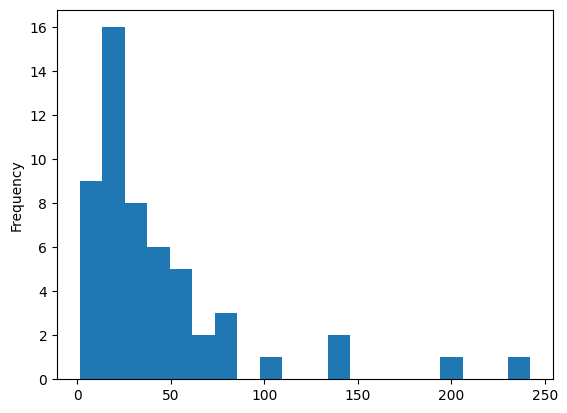

In [243]:
soc_state_geo[soc_state_geo['SOC2'] == '29']['LCA_PER_10K_BLS'].plot.hist(bins=20)

# Let's critique this article

In `Elon Musk is Right about H-1Bs`, written by George Fishman, a Senior Legal Fellow at the Center of Immigration Studies, and published in the beginning of last year, wrote a section called `...Or the Cheap and the Cheapest` juxtaposing the section critiquing the common `The Best and the Brightest` rhetoric that surrounds skilled immigration visas. Although it's very likely the data he is presenting in arguing against the current rate of compensation for H-1B workers is truthful, it's obvious that it is missing the spatial dimension to give a more nuanced look. 

In this section, he seems to begin talking about prevailing wages and how the majority of new applicants are in the bottom two levels. He then quotes the Department of Homeland Security on wages being set `below the local median` or how a Ronil Hira testifies before the Immigration and Citizenship Subcommittee of the House Judiciary Committee that salaries are lower than `local median salaries` citing large technology firms. He then provides an `Evidence` section but seems to make `nationwide` comparisons. This is where there is room for nuance.

For our initial analysis, we will move to one finer level of administrative unit analysis, that is, the `state` level. Normally, United States Citizenship and Immigration Services Labor Condition Applications and Bureau of Labor Statistics Occupational and Employment Wage Statistics report down to the city and metropolitan and non-metropolitan areas, respectively. An analysis at that finer level will be completed at a future time.

## Setup

In [7]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

We note that Labor Condition Applications filed from Jan 1, 2023 – June 30, 2023 use the May 2021 Occupational and Employment Wage Statistics estimates. Although the May 2022 data was released by the Bureau of Labor Statistics in April 2023, the Department of Labor did not implement it for Labor Condition Applications until July 1 of that year.Filings from July 1, 2023 – Dec 31, 2023 use the May 2022 Occupational and Employment Wage Statistics estimates. This dataset became effective for all labor certifications filed on or after July 1, 2023

### Initial File Processing

In [9]:
may2021OEWSpath = r'C:\Users\eagle\OneDrive\Documents\Data\OES\oesm21st\state_M2021_dl.xlsx'
may2022OEWSpath = r'C:\Users\eagle\OneDrive\Documents\Data\OES\oesm22st\state_M2022_dl.xlsx'
may2021OEWSCSVOutPath = r'C:\Users\eagle\OneDrive\Documents\Data\OES\oesm21st\state_M2021_dl.csv'
may2022OEWSCSVOutPath = r'C:\Users\eagle\OneDrive\Documents\Data\OES\oesm22st\state_M2022_dl.csv'
LCA2023Dir = r'C:\Users\eagle\OneDrive\Documents\Data\H1B\CSV\LCA_Disclosure_Data_FY2023_Q*'

In [6]:
pd.read_excel(may2021OEWSpath).to_csv(may2021OEWSCSVOutPath, index=False)
pd.read_excel(may2022OEWSpath).to_csv(may2022OEWSCSVOutPath, index=False)

In [10]:
files = glob.glob(LCA2023Dir)

In [11]:
files = sorted(files)

In [12]:
df_list = []

for f in files:
    df = pd.read_csv(f, low_memory=False)
    df_list.append(df)

### Tabular Standardization

In [13]:
LCA2023 = pd.concat(df_list, ignore_index=True)

In [15]:
OEWS2021 = pd.read_csv(may2021OEWSCSVOutPath, dtype={"OCC_CODE": str, "AREA": str})
OEWS2022 = pd.read_csv(may2022OEWSCSVOutPath, dtype={"OCC_CODE": str, "AREA": str})

In [17]:
LCA2023 = LCA2023[['CASE_NUMBER', 'RECEIVED_DATE', 'DECISION_DATE', 'ORIGINAL_CERT_DATE',
                   'CASE_STATUS', 'VISA_CLASS', 'JOB_TITLE', 'SOC_CODE', 
                   'NEW_EMPLOYMENT', 'CONTINUED_EMPLOYMENT',
                   'CHANGE_PREVIOUS_EMPLOYMENT', 'NEW_CONCURRENT_EMPLOYMENT',
                   'CHANGE_EMPLOYER', 'AMENDED_PETITION', 'EMPLOYER_NAME',
                   'WORKSITE_WORKERS', 'WAGE_RATE_OF_PAY_FROM', 'WAGE_RATE_OF_PAY_TO', 
                   'WAGE_UNIT_OF_PAY', 'PREVAILING_WAGE', 'PW_UNIT_OF_PAY', 'PW_WAGE_LEVEL', 
                   'WORKSITE_STATE']]

In [23]:
OEWS2021 = OEWS2021[['AREA', 'AREA_TITLE', 'PRIM_STATE', 'O_GROUP', 'OCC_CODE', 'TOT_EMP',
                     'OWN_CODE', 'JOBS_1000', 'PCT_TOTAL', 'PCT_RPT', 'LOC_QUOTIENT',
                     'H_MEAN', 'A_MEAN', 'H_PCT10', 'H_PCT25', 'H_MEDIAN',
                     'H_PCT75', 'H_PCT90', 'A_PCT10', 'A_PCT25', 'A_MEDIAN', 'A_PCT75',
                     'A_PCT90']]

In [24]:
OEWS2022 = OEWS2022[['AREA', 'AREA_TITLE', 'PRIM_STATE', 'O_GROUP', 'OCC_CODE', 'TOT_EMP',
                     'OWN_CODE', 'JOBS_1000', 'PCT_TOTAL', 'PCT_RPT', 'LOC_QUOTIENT',
                     'H_MEAN', 'A_MEAN', 'H_PCT10', 'H_PCT25', 'H_MEDIAN',
                     'H_PCT75', 'H_PCT90', 'A_PCT10', 'A_PCT25', 'A_MEDIAN', 'A_PCT75',
                     'A_PCT90']]

#### Labor Condition Application

##### Filtration and Aggregation

In [33]:
receivedDateRange = pd.to_datetime(LCA2023['RECEIVED_DATE'], errors='coerce')

In [34]:
receivedDateRange.min(), receivedDateRange.max()

(Timestamp('2019-10-03 00:00:00'), Timestamp('2023-09-30 00:00:00'))

In [37]:
receivedMonthlyDist = (
    receivedDateRange
    .dt.to_period('M')
    .value_counts()
    .sort_index()
)


In [38]:
receivedMonthlyDist

RECEIVED_DATE
2019-10      118
2019-11      149
2019-12      144
2020-01      265
2020-02      507
2020-03      625
2020-04      789
2020-05      773
2020-06      617
2020-07      514
2020-08      443
2020-09      504
2020-10      377
2020-11      660
2020-12      492
2021-01      511
2021-02      688
2021-03     1011
2021-04     1163
2021-05     1146
2021-06     1175
2021-07      745
2021-08      857
2021-09      843
2021-10      776
2021-11     1748
2021-12      902
2022-01      910
2022-02     1141
2022-03     1625
2022-04     1804
2022-05     1765
2022-06     1728
2022-07      950
2022-08     1101
2022-09    15335
2022-10    62647
2022-11    58817
2022-12    52442
2023-01    35677
2023-02    44802
2023-03    54100
2023-04    59278
2023-05    62239
2023-06    59013
2023-07    29538
2023-08    46094
2023-09    35059
Freq: M, Name: count, dtype: int64

In [40]:
certifiedDateRange = pd.to_datetime(LCA2023['ORIGINAL_CERT_DATE'], errors='coerce')

certifiedMonthlyDist = (
    certifiedDateRange
    .dt.to_period('M')
    .value_counts()
    .sort_index()
)

certifiedDateRange.min(), certifiedDateRange.max(), certifiedMonthlyDist

(Timestamp('2019-10-10 00:00:00'),
 Timestamp('2023-09-29 00:00:00'),
 ORIGINAL_CERT_DATE
 2019-10      81
 2019-11     161
 2019-12     152
 2020-01     208
 2020-02     434
 2020-03     651
 2020-04     738
 2020-05     758
 2020-06     716
 2020-07     495
 2020-08     438
 2020-09     526
 2020-10     423
 2020-11     653
 2020-12     469
 2021-01     471
 2021-02     585
 2021-03    1025
 2021-04    1103
 2021-05    1142
 2021-06    1207
 2021-07     798
 2021-08     842
 2021-09     827
 2021-10     794
 2021-11     886
 2021-12    1835
 2022-01     811
 2022-02    1036
 2022-03    1577
 2022-04    1731
 2022-05    1749
 2022-06    1847
 2022-07    1056
 2022-08    1116
 2022-09    1243
 2022-10    1593
 2022-11    1367
 2022-12    1036
 2023-01     767
 2023-02     880
 2023-03    1137
 2023-04    1220
 2023-05    1153
 2023-06     823
 2023-07     567
 2023-08     539
 2023-09     291
 Freq: M, Name: count, dtype: int64)

In [41]:
decisionDateRange = pd.to_datetime(LCA2023['DECISION_DATE'], errors='coerce')

decisionMonthlyDist = (
    decisionDateRange
    .dt.to_period('M')
    .value_counts()
    .sort_index()
)

decisionDateRange.min(), decisionDateRange.max(), decisionMonthlyDist

(Timestamp('2022-10-01 00:00:00'),
 Timestamp('2023-09-30 00:00:00'),
 DECISION_DATE
 2022-10    68010
 2022-11    65457
 2022-12    63269
 2023-01    33095
 2023-02    41635
 2023-03    58813
 2023-04    56557
 2023-05    67607
 2023-06    62225
 2023-07    33782
 2023-08    46409
 2023-09    47748
 Freq: M, Name: count, dtype: int64)

We choose decision dates between `2023-01` to `2023-06` so we use the `OEWS2021` dataset to compare our Labor Condition Applications against.

In [42]:
LCA2023['DECISION_DATE'] = pd.to_datetime(
    LCA2023['DECISION_DATE'], errors='coerce'
)

In [43]:
LCA2023Q12 = LCA2023[
    (LCA2023['DECISION_DATE'] >= '2023-01-01') &
    (LCA2023['DECISION_DATE'] <  '2023-07-01')
]

In [46]:
LCA2023Q12 = LCA2023Q12[
    (LCA2023Q12['VISA_CLASS'] == 'H-1B') &
    (LCA2023Q12['CASE_STATUS'] == 'Certified')
][['SOC_CODE', 'JOB_TITLE', 'WORKSITE_WORKERS', 'WORKSITE_STATE',
   'EMPLOYER_NAME', 'WAGE_RATE_OF_PAY_FROM', 'WAGE_RATE_OF_PAY_TO', 'WAGE_UNIT_OF_PAY',
   'PREVAILING_WAGE', 'PW_UNIT_OF_PAY', 'PW_WAGE_LEVEL']]

In [49]:
LCA2023Q12['WAGE_UNIT_OF_PAY'].value_counts(), LCA2023Q12['PW_UNIT_OF_PAY'].value_counts()

(WAGE_UNIT_OF_PAY
 Year         274797
 Hour          15649
 Month           216
 Bi-Weekly        45
 Week             33
 Name: count, dtype: int64,
 PW_UNIT_OF_PAY
 Year         274913
 Hour          15546
 Month           212
 Bi-Weekly        42
 Week             27
 Name: count, dtype: int64)

In [52]:
def annualize(wage, unit):
    if pd.isna(wage):
        return np.nan
    
    unit = str(unit).strip().upper()
    
    if unit == 'HOUR':
        return wage * 2080
    elif unit == 'WEEK':
        return wage * 52
    elif unit == 'BI-WEEKLY':
        return wage * 26
    elif unit == 'MONTH':
        return wage * 12
    elif unit == 'YEAR':
        return wage
    else:
        return np.nan

In [53]:
LCA2023Q12['W_FRM_ANNUAL'] = LCA2023Q12.apply(
    lambda r: annualize(r['WAGE_RATE_OF_PAY_FROM'], r['WAGE_UNIT_OF_PAY']),
    axis=1
)

LCA2023Q12['W_TO_ANNUAL'] = LCA2023Q12.apply(
    lambda r: annualize(r['WAGE_RATE_OF_PAY_TO'], r['WAGE_UNIT_OF_PAY']),
    axis=1
)

LCA2023Q12['PW_ANNUAL'] = LCA2023Q12.apply(
    lambda r: annualize(r['PREVAILING_WAGE'], r['PW_UNIT_OF_PAY']),
    axis=1
)

In [55]:
LCA2023Q12 = LCA2023Q12[[ 'SOC_CODE', 'JOB_TITLE', 'WORKSITE_WORKERS', 'WORKSITE_STATE',
   'EMPLOYER_NAME', 'W_FRM_ANNUAL', 'W_TO_ANNUAL',
   'PW_ANNUAL', 'PW_WAGE_LEVEL']]

In [57]:
LCA2023Q12SOC15 = LCA2023Q12[LCA2023Q12['SOC_CODE'].str.startswith('15')]

In [59]:
LCA2023Q12SOC15.isna().sum()

SOC_CODE                 0
JOB_TITLE                0
WORKSITE_WORKERS         1
WORKSITE_STATE           1
EMPLOYER_NAME            0
W_FRM_ANNUAL             1
W_TO_ANNUAL         124877
PW_ANNUAL                1
PW_WAGE_LEVEL         4975
dtype: int64

In [62]:
LCA2023Q12CRO = LCA2023Q12SOC15[LCA2023Q12SOC15['SOC_CODE'].str.startswith('15-1299')][['JOB_TITLE', 'WORKSITE_WORKERS', 'WORKSITE_STATE', 'EMPLOYER_NAME', 'W_FRM_ANNUAL', 'W_TO_ANNUAL', 'PW_ANNUAL', 'PW_WAGE_LEVEL']]

In [64]:
LCA2023Q12CRO.isna().sum()

JOB_TITLE               0
WORKSITE_WORKERS        0
WORKSITE_STATE          0
EMPLOYER_NAME           0
W_FRM_ANNUAL            0
W_TO_ANNUAL         13594
PW_ANNUAL               0
PW_WAGE_LEVEL         172
dtype: int64

In [66]:
LCA2023Q12CRO_wWTO = LCA2023Q12CRO[LCA2023Q12CRO['W_TO_ANNUAL'].notna()]

In [70]:
LCA2023Q12CRO_wWFRM = LCA2023Q12CRO[['JOB_TITLE', 'WORKSITE_WORKERS', 'WORKSITE_STATE', 'EMPLOYER_NAME', 'W_FRM_ANNUAL', 'PW_ANNUAL', 'PW_WAGE_LEVEL']]

In [71]:
LCA2023Q12CRO_wWFRM

,JOB_TITLE,WORKSITE_WORKERS,WORKSITE_STATE,EMPLOYER_NAME,W_FRM_ANNUAL,PW_ANNUAL,PW_WAGE_LEVEL
98762,System Architect - IV,1.0,OH,HCL AMERICA INC,170000.0,105893.0,IV
98803,System Architect - IV,1.0,NJ,HCL AMERICA INC,140400.0,124030.0,IV
98814,Information Technology Project Manager 4,1.0,TX,Accenture LLP,128000.0,120349.0,IV
98817,Senior Associate JC60 -Computer Systems Engine...,1.0,NC,COGNIZANT TECHNOLOGY SOLUTIONS US CORP,73091.0,73091.0,II
98818,Senior Associate JC60 -Computer Systems Engine...,1.0,PA,COGNIZANT TECHNOLOGY SOLUTIONS US CORP,75546.0,75546.0,II
...,...,...,...,...,...,...,...
516555,Principal Consultant,1.0,CA,Headstrong Services LLC,125000.0,72363.0,II
516582,Manager JC50 - Computer Systems Engineers/Arch...,1.0,TX,COGNIZANT TECHNOLOGY SOLUTIONS US CORP,94432.0,94432.0,III
516592,Technical Architect,1.0,MA,LTIMINDTREE LIMITED\t,101171.0,101171.0,III
516608,Technical Program Manager,1.0,NJ,Microsoft Corporation,151900.0,50315.0,I


In [72]:
LCA2023Q12CRO_wWTO

,JOB_TITLE,WORKSITE_WORKERS,WORKSITE_STATE,EMPLOYER_NAME,W_FRM_ANNUAL,W_TO_ANNUAL,PW_ANNUAL,PW_WAGE_LEVEL
98814,Information Technology Project Manager 4,1.0,TX,Accenture LLP,128000.0,292400.0,120349.0,IV
98847,Information Technology Project Manager 4,1.0,VA,Accenture LLP,155800.0,206700.0,105165.0,IV
98866,Information Technology Project Manager 4,1.0,CA,Accenture LLP,155800.0,311300.0,118310.0,IV
98889,Information Technology Project Manager 4,1.0,CA,Accenture LLP,172536.0,338400.0,172536.0,IV
98896,Computer Specialist/System Support And Develop...,1.0,PA,Accenture LLP,89700.0,217400.0,75546.0,II
...,...,...,...,...,...,...,...,...
516501,Software Development Engineer - Systems,1.0,CA,Apple Inc.,140442.0,177000.0,99341.0,III
516504,Software Development Engineer,1.0,TX,"Brillio, LLC",76378.0,120000.0,68910.0,II
516513,Architect,1.0,WA,TATA CONSULTANCY SERVICES LIMITED,73466.0,116100.0,73466.0,II
516592,Technical Architect,1.0,MA,LTIMINDTREE LIMITED\t,101171.0,107802.0,101171.0,III


In [81]:
import numpy as np
import pandas as pd

def weighted_quantile(values, quantile, weights):
    values = np.array(values)
    weights = np.array(weights)
    
    sorter = np.argsort(values)
    values = values[sorter]
    weights = weights[sorter]
    
    cumsum = np.cumsum(weights)
    cutoff = quantile * weights.sum()
    
    return values[cumsum >= cutoff][0]

def compute_group(g):
    w = g['WORKSITE_WORKERS']
    
    return pd.Series({
        'mean_W_FRM_ANNUAL': np.average(g['W_FRM_ANNUAL'], weights=w),
        'mean_PW_ANNUAL': np.average(g['PW_ANNUAL'], weights=w),
        
        'q25_W_FRM_ANNUAL': weighted_quantile(g['W_FRM_ANNUAL'], 0.25, w),
        'median_W_FRM_ANNUAL': weighted_quantile(g['W_FRM_ANNUAL'], 0.50, w),
        'q75_W_FRM_ANNUAL': weighted_quantile(g['W_FRM_ANNUAL'], 0.75, w),
        
        'sum_WORKSITE_WORKERS': w.sum()
    })

LCA2023Q12CRO_wWFRM_aggST_PWLVL = (
    LCA2023Q12CRO_wWFRM
    .groupby(['WORKSITE_STATE', 'PW_WAGE_LEVEL'])
    .apply(compute_group)
    .reset_index()
)

C:\Users\eagle\AppData\Local\Temp\ipykernel_10376\1577049797.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_group)


In [83]:
import numpy as np
import pandas as pd

def weighted_quantile(values, quantile, weights):
    values = np.array(values)
    weights = np.array(weights)
    
    sorter = np.argsort(values)
    values = values[sorter]
    weights = weights[sorter]
    
    cumsum = np.cumsum(weights)
    cutoff = quantile * weights.sum()
    
    return values[cumsum >= cutoff][0]

def compute_group(g):
    w = g['WORKSITE_WORKERS']
    
    return pd.Series({
        # weighted means
        'mean_W_FROM_ANNUAL': np.average(g['W_FRM_ANNUAL'], weights=w),
        'mean_W_TO_ANNUAL': np.average(g['W_TO_ANNUAL'], weights=w),
        'mean_PW_ANNUAL': np.average(g['PW_ANNUAL'], weights=w),
        
        # weighted quantiles - FROM
        'q25_W_FROM_ANNUAL': weighted_quantile(g['W_FRM_ANNUAL'], 0.25, w),
        'median_W_FROM_ANNUAL': weighted_quantile(g['W_FRM_ANNUAL'], 0.50, w),
        'q75_W_FROM_ANNUAL': weighted_quantile(g['W_FRM_ANNUAL'], 0.75, w),
        
        # weighted quantiles - TO
        'q25_W_TO_ANNUAL': weighted_quantile(g['W_TO_ANNUAL'], 0.25, w),
        'median_W_TO_ANNUAL': weighted_quantile(g['W_TO_ANNUAL'], 0.50, w),
        'q75_W_TO_ANNUAL': weighted_quantile(g['W_TO_ANNUAL'], 0.75, w),
        
        # worker exposure
        'sum_WORKSITE_WORKERS': w.sum()
    })

LCA2023Q12CRO_wWTO_aggST_PWLVL = (
    LCA2023Q12CRO_wWTO
    .groupby(['WORKSITE_STATE', 'PW_WAGE_LEVEL'])
    .apply(compute_group)
    .reset_index()
)

C:\Users\eagle\AppData\Local\Temp\ipykernel_10376\3377239848.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_group)


##### Output

In [90]:
LCA2023Q12CRO_wWFRM_aggST_PWLVL.to_csv(r'C:\Users\eagle\OneDrive\Documents\Data\572-lab-1\LCA2023Q12CRO_wWFRM_aggST_PWLVL.csv', index=False)

In [91]:
LCA2023Q12CRO_wWTO_aggST_PWLVL.to_csv(r'C:\Users\eagle\OneDrive\Documents\Data\572-lab-1\LCA2023Q12CRO_wWTO_aggST_PWLVL.csv', index=False)

In [92]:
LCA2023Q12CRO_wWFRM_aggST_PWLVL

,WORKSITE_STATE,PW_WAGE_LEVEL,mean_W_FRM_ANNUAL,mean_PW_ANNUAL,q25_W_FRM_ANNUAL,median_W_FRM_ANNUAL,q75_W_FRM_ANNUAL,sum_WORKSITE_WORKERS
0,AK,II,86778.000000,86778.000000,86778.0,86778.0,86778.0,1.0
1,AL,II,102324.125000,70860.475000,85280.0,94500.0,106000.0,8.0
2,AL,III,125124.343333,91301.500000,97000.0,105000.0,144000.0,6.0
3,AL,IV,106376.666667,97198.333333,101130.0,102000.0,116000.0,3.0
4,AR,I,44116.800000,44116.800000,44116.8,44116.8,44116.8,1.0
...,...,...,...,...,...,...,...,...
178,WI,IV,111845.827391,91880.608696,89606.0,89606.0,130000.0,46.0
179,WV,II,60000.000000,48131.000000,60000.0,60000.0,60000.0,1.0
180,WV,III,118379.674000,104778.040000,122262.4,122262.4,125840.0,5.0
181,WY,I,69767.200000,49893.700000,48068.8,77000.0,77000.0,4.0


In [93]:
LCA2023Q12CRO_wWTO_aggST_PWLVL

,WORKSITE_STATE,PW_WAGE_LEVEL,mean_W_FROM_ANNUAL,mean_W_TO_ANNUAL,mean_PW_ANNUAL,q25_W_FROM_ANNUAL,median_W_FROM_ANNUAL,q75_W_FROM_ANNUAL,q25_W_TO_ANNUAL,median_W_TO_ANNUAL,q75_W_TO_ANNUAL,sum_WORKSITE_WORKERS
0,AK,II,86778.000000,87000.000000,86778.000000,86778.0,86778.0,86778.0,87000.0,87000.0,87000.0,1.0
1,AL,III,185000.000000,200000.000000,93870.000000,185000.0,185000.0,185000.0,200000.0,200000.0,200000.0,1.0
2,AL,IV,109000.000000,134000.000000,100880.000000,102000.0,102000.0,116000.0,130000.0,130000.0,138000.0,2.0
3,AR,II,63114.084034,85753.873950,62218.436975,62234.0,62234.0,62234.0,84524.0,84524.0,85249.0,119.0
4,AR,III,83730.428571,130117.952381,80152.095238,80371.0,80371.0,80371.0,117000.0,118375.0,118800.0,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...
159,WI,III,81068.125000,137450.850000,76528.600000,74693.0,74693.0,74693.0,117000.0,118375.0,139103.0,40.0
160,WI,IV,96465.296296,134652.518519,89844.074074,89606.0,89606.0,89606.0,125498.0,125498.0,125498.0,27.0
161,WV,II,60000.000000,75000.000000,48131.000000,60000.0,60000.0,60000.0,75000.0,75000.0,75000.0,1.0
162,WY,I,77000.000000,78666.666667,50502.000000,77000.0,77000.0,77000.0,78000.0,78000.0,80000.0,3.0


#### Occupational Employment and Wage Statistics

In [102]:
OEWS2021CRO = OEWS2021[OEWS2021['OCC_CODE'].str.startswith('15-1299')][['AREA', 'PRIM_STATE', 'TOT_EMP', 'A_MEAN', 'A_PCT25', 'A_MEDIAN', 'A_PCT75']]

In [126]:
cols = ['TOT_EMP', 'A_MEAN', 'A_PCT25', 'A_MEDIAN', 'A_PCT75']

for col in cols:
    OEWS2021CRO[col] = pd.to_numeric(OEWS2021CRO[col], errors='coerce')

In [127]:
OEWS2021CRO.to_csv(r'C:\Users\eagle\OneDrive\Documents\Data\572-lab-1\OEWS2021CRO.csv', index=False)

In [128]:
OEWS2021CRO

,AREA,PRIM_STATE,TOT_EMP,A_MEAN,A_PCT25,A_MEDIAN,A_PCT75
80,1,AL,2090.0,89550.0,70160.0,90770.0,107930.0
814,2,AK,550.0,93260.0,79050.0,96450.0,108890.0
1379,4,AZ,3680.0,84030.0,59360.0,78050.0,102440.0
2142,5,AR,960.0,66410.0,45720.0,48920.0,83320.0
2847,6,CA,92050.0,112000.0,64220.0,101170.0,145780.0
3680,8,CO,NaN,109770.0,79400.0,101620.0,129240.0
4461,9,CT,1000.0,96040.0,75880.0,95270.0,120300.0
5165,10,DE,1020.0,111000.0,81190.0,101000.0,129240.0
5724,11,DC,17720.0,120910.0,95270.0,126610.0,147060.0
6247,12,FL,11180.0,83280.0,48910.0,79780.0,104100.0


## Analysis

In [113]:
LCA2023Q12CRO_wWTO_aggST_PWLVL

,WORKSITE_STATE,PW_WAGE_LEVEL,mean_W_FROM_ANNUAL,mean_W_TO_ANNUAL,mean_PW_ANNUAL,q25_W_FROM_ANNUAL,median_W_FROM_ANNUAL,q75_W_FROM_ANNUAL,q25_W_TO_ANNUAL,median_W_TO_ANNUAL,q75_W_TO_ANNUAL,sum_WORKSITE_WORKERS
0,AK,II,86778.000000,87000.000000,86778.000000,86778.0,86778.0,86778.0,87000.0,87000.0,87000.0,1.0
1,AL,III,185000.000000,200000.000000,93870.000000,185000.0,185000.0,185000.0,200000.0,200000.0,200000.0,1.0
2,AL,IV,109000.000000,134000.000000,100880.000000,102000.0,102000.0,116000.0,130000.0,130000.0,138000.0,2.0
3,AR,II,63114.084034,85753.873950,62218.436975,62234.0,62234.0,62234.0,84524.0,84524.0,85249.0,119.0
4,AR,III,83730.428571,130117.952381,80152.095238,80371.0,80371.0,80371.0,117000.0,118375.0,118800.0,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...
159,WI,III,81068.125000,137450.850000,76528.600000,74693.0,74693.0,74693.0,117000.0,118375.0,139103.0,40.0
160,WI,IV,96465.296296,134652.518519,89844.074074,89606.0,89606.0,89606.0,125498.0,125498.0,125498.0,27.0
161,WV,II,60000.000000,75000.000000,48131.000000,60000.0,60000.0,60000.0,75000.0,75000.0,75000.0,1.0
162,WY,I,77000.000000,78666.666667,50502.000000,77000.0,77000.0,77000.0,78000.0,78000.0,80000.0,3.0


In [123]:
LCA2023Q12CRO_wWFRM_aggST_PWLVL

,WORKSITE_STATE,PW_WAGE_LEVEL,mean_W_FRM_ANNUAL,mean_PW_ANNUAL,q25_W_FRM_ANNUAL,median_W_FRM_ANNUAL,q75_W_FRM_ANNUAL,sum_WORKSITE_WORKERS
0,AK,II,86778.000000,86778.000000,86778.0,86778.0,86778.0,1.0
1,AL,II,102324.125000,70860.475000,85280.0,94500.0,106000.0,8.0
2,AL,III,125124.343333,91301.500000,97000.0,105000.0,144000.0,6.0
3,AL,IV,106376.666667,97198.333333,101130.0,102000.0,116000.0,3.0
4,AR,I,44116.800000,44116.800000,44116.8,44116.8,44116.8,1.0
...,...,...,...,...,...,...,...,...
178,WI,IV,111845.827391,91880.608696,89606.0,89606.0,130000.0,46.0
179,WV,II,60000.000000,48131.000000,60000.0,60000.0,60000.0,1.0
180,WV,III,118379.674000,104778.040000,122262.4,122262.4,125840.0,5.0
181,WY,I,69767.200000,49893.700000,48068.8,77000.0,77000.0,4.0


In [125]:
OEWS2021CRO

,AREA,PRIM_STATE,TOT_EMP,A_MEAN,A_PCT25,A_MEDIAN,A_PCT75
80,1,AL,2090,89550,70160,90770,107930
814,2,AK,550,93260,79050,96450,108890
1379,4,AZ,3680,84030,59360,78050,102440
2142,5,AR,960,66410,45720,48920,83320
2847,6,CA,92050,112000,64220,101170,145780
3680,8,CO,**,109770,79400,101620,129240
4461,9,CT,1000,96040,75880,95270,120300
5165,10,DE,1020,111000,81190,101000,129240
5724,11,DC,17720,120910,95270,126610,147060
6247,12,FL,11180,83280,48910,79780,104100


### With only minimum salary

In [117]:
frm = LCA2023Q12CRO_wWFRM_aggST_PWLVL.copy()

In [136]:
frmComp = frm.merge(
    OEWS2021CRO,
    left_on='WORKSITE_STATE',
    right_on='PRIM_STATE',
    how='left'
)

In [137]:
frmComp

,WORKSITE_STATE,PW_WAGE_LEVEL,mean_W_FRM_ANNUAL,mean_PW_ANNUAL,q25_W_FRM_ANNUAL,median_W_FRM_ANNUAL,q75_W_FRM_ANNUAL,sum_WORKSITE_WORKERS,AREA,PRIM_STATE,TOT_EMP,A_MEAN,A_PCT25,A_MEDIAN,A_PCT75
0,AK,II,86778.000000,86778.000000,86778.0,86778.0,86778.0,1.0,2,AK,550.0,93260.0,79050.0,96450.0,108890.0
1,AL,II,102324.125000,70860.475000,85280.0,94500.0,106000.0,8.0,1,AL,2090.0,89550.0,70160.0,90770.0,107930.0
2,AL,III,125124.343333,91301.500000,97000.0,105000.0,144000.0,6.0,1,AL,2090.0,89550.0,70160.0,90770.0,107930.0
3,AL,IV,106376.666667,97198.333333,101130.0,102000.0,116000.0,3.0,1,AL,2090.0,89550.0,70160.0,90770.0,107930.0
4,AR,I,44116.800000,44116.800000,44116.8,44116.8,44116.8,1.0,5,AR,960.0,66410.0,45720.0,48920.0,83320.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,WI,IV,111845.827391,91880.608696,89606.0,89606.0,130000.0,46.0,55,WI,3200.0,77100.0,49450.0,75090.0,95570.0
179,WV,II,60000.000000,48131.000000,60000.0,60000.0,60000.0,1.0,54,WV,2120.0,93780.0,73880.0,95200.0,119770.0
180,WV,III,118379.674000,104778.040000,122262.4,122262.4,125840.0,5.0,54,WV,2120.0,93780.0,73880.0,95200.0,119770.0
181,WY,I,69767.200000,49893.700000,48068.8,77000.0,77000.0,4.0,56,WY,150.0,74910.0,63900.0,74550.0,85530.0


In [ ]:
frmComp['emp_share'] = frmComp['sum_WORKSITE_WORKERS'] / frmComp['TOT_EMP']
frmComp['IMM_PER_10K_BLS'] = frmComp['emp_share'] * 10000

frmComp['gap_median'] = frmComp['median_W_FRM_ANNUAL'] - frmComp['A_MEDIAN']
frmComp['ratio_median'] = frmComp['median_W_FRM_ANNUAL'] / frmComp['A_MEDIAN']

frmComp['gap_mean'] = frmComp['mean_W_FRM_ANNUAL'] - frmComp['A_MEAN']
frmComp['ratio_mean'] = frmComp['mean_W_FRM_ANNUAL'] / frmComp['A_MEAN']

frmComp['below_p25'] = frmComp['median_W_FRM_ANNUAL'] < frmComp['A_PCT25']
frmComp['above_p75'] = frmComp['median_W_FRM_ANNUAL'] > frmComp['A_PCT75']

frmComp['wage_ladder_index'] = (
    (frmComp['median_W_FRM_ANNUAL'] - frmComp['A_PCT25']) /
    (frmComp['A_PCT75'] - frmComp['A_PCT25'])
)

frmComp['calibration_diff'] = frmComp['mean_W_FRM_ANNUAL'] - frmComp['A_MEAN']
frmComp['calibration_index'] = frmComp['mean_W_FRM_ANNUAL'] / frmComp['A_MEAN']

In [141]:
frmComp.to_csv(r'C:\Users\eagle\OneDrive\Documents\Data\572-lab-1\frmComp.csv', index=False)

In [142]:
frmComp

,WORKSITE_STATE,PW_WAGE_LEVEL,mean_W_FRM_ANNUAL,mean_PW_ANNUAL,q25_W_FRM_ANNUAL,median_W_FRM_ANNUAL,q75_W_FRM_ANNUAL,sum_WORKSITE_WORKERS,AREA,PRIM_STATE,...,A_PCT75,emp_share,gap_median,ratio_median,gap_mean,ratio_mean,below_p25,above_p75,wage_ladder_index,calibration_index
0,AK,II,86778.000000,86778.000000,86778.0,86778.0,86778.0,1.0,2,AK,...,108890.0,0.001818,-9672.0,0.899720,-6482.000000,0.930495,False,False,0.258981,0.930495
1,AL,II,102324.125000,70860.475000,85280.0,94500.0,106000.0,8.0,1,AL,...,107930.0,0.003828,3730.0,1.041093,12774.125000,1.142648,False,False,0.644427,1.142648
2,AL,III,125124.343333,91301.500000,97000.0,105000.0,144000.0,6.0,1,AL,...,107930.0,0.002871,14230.0,1.156770,35574.343333,1.397257,False,False,0.922425,1.397257
3,AL,IV,106376.666667,97198.333333,101130.0,102000.0,116000.0,3.0,1,AL,...,107930.0,0.001435,11230.0,1.123719,16826.666667,1.187902,False,False,0.842997,1.187902
4,AR,I,44116.800000,44116.800000,44116.8,44116.8,44116.8,1.0,5,AR,...,83320.0,0.001042,-4803.2,0.901815,-22293.200000,0.664310,True,False,-0.042638,0.664310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,WI,IV,111845.827391,91880.608696,89606.0,89606.0,130000.0,46.0,55,WI,...,95570.0,0.014375,14516.0,1.193315,34745.827391,1.450659,False,False,0.870685,1.450659
179,WV,II,60000.000000,48131.000000,60000.0,60000.0,60000.0,1.0,54,WV,...,119770.0,0.000472,-35200.0,0.630252,-33780.000000,0.639795,True,False,-0.302462,0.639795
180,WV,III,118379.674000,104778.040000,122262.4,122262.4,125840.0,5.0,54,WV,...,119770.0,0.002358,27062.4,1.284269,24599.674000,1.262313,False,True,1.054312,1.262313
181,WY,I,69767.200000,49893.700000,48068.8,77000.0,77000.0,4.0,56,WY,...,85530.0,0.026667,2450.0,1.032864,-5142.800000,0.931347,False,False,0.605640,0.931347


### Including Upper Range of Salary

In [143]:
to = LCA2023Q12CRO_wWTO_aggST_PWLVL.copy()

In [144]:
toComp = to.merge(
    OEWS2021CRO,
    left_on='WORKSITE_STATE',
    right_on='PRIM_STATE',
    how='left'
)

In [145]:
toComp

,WORKSITE_STATE,PW_WAGE_LEVEL,mean_W_FROM_ANNUAL,mean_W_TO_ANNUAL,mean_PW_ANNUAL,q25_W_FROM_ANNUAL,median_W_FROM_ANNUAL,q75_W_FROM_ANNUAL,q25_W_TO_ANNUAL,median_W_TO_ANNUAL,q75_W_TO_ANNUAL,sum_WORKSITE_WORKERS,AREA,PRIM_STATE,TOT_EMP,A_MEAN,A_PCT25,A_MEDIAN,A_PCT75
0,AK,II,86778.000000,87000.000000,86778.000000,86778.0,86778.0,86778.0,87000.0,87000.0,87000.0,1.0,2,AK,550.0,93260.0,79050.0,96450.0,108890.0
1,AL,III,185000.000000,200000.000000,93870.000000,185000.0,185000.0,185000.0,200000.0,200000.0,200000.0,1.0,1,AL,2090.0,89550.0,70160.0,90770.0,107930.0
2,AL,IV,109000.000000,134000.000000,100880.000000,102000.0,102000.0,116000.0,130000.0,130000.0,138000.0,2.0,1,AL,2090.0,89550.0,70160.0,90770.0,107930.0
3,AR,II,63114.084034,85753.873950,62218.436975,62234.0,62234.0,62234.0,84524.0,84524.0,85249.0,119.0,5,AR,960.0,66410.0,45720.0,48920.0,83320.0
4,AR,III,83730.428571,130117.952381,80152.095238,80371.0,80371.0,80371.0,117000.0,118375.0,118800.0,21.0,5,AR,960.0,66410.0,45720.0,48920.0,83320.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,WI,III,81068.125000,137450.850000,76528.600000,74693.0,74693.0,74693.0,117000.0,118375.0,139103.0,40.0,55,WI,3200.0,77100.0,49450.0,75090.0,95570.0
160,WI,IV,96465.296296,134652.518519,89844.074074,89606.0,89606.0,89606.0,125498.0,125498.0,125498.0,27.0,55,WI,3200.0,77100.0,49450.0,75090.0,95570.0
161,WV,II,60000.000000,75000.000000,48131.000000,60000.0,60000.0,60000.0,75000.0,75000.0,75000.0,1.0,54,WV,2120.0,93780.0,73880.0,95200.0,119770.0
162,WY,I,77000.000000,78666.666667,50502.000000,77000.0,77000.0,77000.0,78000.0,78000.0,80000.0,3.0,56,WY,150.0,74910.0,63900.0,74550.0,85530.0


In [147]:
toComp['emp_share'] = toComp['sum_WORKSITE_WORKERS'] / toComp['TOT_EMP']
toComp['IMM_PER_10K_BLS'] = toComp['emp_share'] * 10000

toComp['gap_median'] = toComp['median_W_FROM_ANNUAL'] - toComp['A_MEDIAN']
toComp['ratio_median'] = toComp['median_W_FROM_ANNUAL'] / toComp['A_MEDIAN']

toComp['gap_to_median'] = toComp['median_W_TO_ANNUAL'] - toComp['A_MEDIAN']
toComp['ratio_to_median'] = toComp['median_W_TO_ANNUAL'] / toComp['A_MEDIAN']

toComp['gap_mean'] = toComp['mean_W_FROM_ANNUAL'] - toComp['A_MEAN']
toComp['ratio_mean'] = toComp['mean_W_FROM_ANNUAL'] / toComp['A_MEAN']

toComp['gap_to_mean'] = toComp['mean_W_TO_ANNUAL'] - toComp['A_MEAN']
toComp['ratio_to_mean'] = toComp['mean_W_TO_ANNUAL'] / toComp['A_MEAN']

toComp['below_p25'] = toComp['median_W_FROM_ANNUAL'] < toComp['A_PCT25']
toComp['above_p75'] = toComp['median_W_FROM_ANNUAL'] > toComp['A_PCT75']

toComp['below_to_p25'] = toComp['median_W_TO_ANNUAL'] < toComp['A_PCT25']
toComp['above_to_p75'] = toComp['median_W_TO_ANNUAL'] > toComp['A_PCT75']

toComp['wage_ladder_index'] = (
    (toComp['median_W_FROM_ANNUAL'] - toComp['A_PCT25']) /
    (toComp['A_PCT75'] - toComp['A_PCT25'])
)

toComp['wage_ladder_index_to'] = (
    (toComp['median_W_TO_ANNUAL'] - toComp['A_PCT25']) /
    (toComp['A_PCT75'] - toComp['A_PCT25'])
)

toComp['calibration_diff'] = toComp['mean_W_FROM_ANNUAL'] - toComp['A_MEAN']
toComp['calibration_index'] = toComp['mean_W_FROM_ANNUAL'] / toComp['A_MEAN']

toComp['calibration_diff_to'] = toComp['mean_W_TO_ANNUAL'] - toComp['A_MEAN']
toComp['calibration_index_to'] = toComp['mean_W_TO_ANNUAL'] / toComp['A_MEAN']

In [148]:
toComp

,WORKSITE_STATE,PW_WAGE_LEVEL,mean_W_FROM_ANNUAL,mean_W_TO_ANNUAL,mean_PW_ANNUAL,q25_W_FROM_ANNUAL,median_W_FROM_ANNUAL,q75_W_FROM_ANNUAL,q25_W_TO_ANNUAL,median_W_TO_ANNUAL,...,below_p25,above_p75,below_to_p25,above_to_p75,wage_ladder_index,wage_ladder_index_to,calibration_diff,calibration_index,calibration_diff_to,calibration_index_to
0,AK,II,86778.000000,87000.000000,86778.000000,86778.0,86778.0,86778.0,87000.0,87000.0,...,False,False,False,False,0.258981,0.266421,-6482.000000,0.930495,-6260.000000,0.932876
1,AL,III,185000.000000,200000.000000,93870.000000,185000.0,185000.0,185000.0,200000.0,200000.0,...,False,True,False,True,3.040508,3.437649,95450.000000,2.065885,110450.000000,2.233389
2,AL,IV,109000.000000,134000.000000,100880.000000,102000.0,102000.0,116000.0,130000.0,130000.0,...,False,False,False,True,0.842997,1.584326,19450.000000,1.217197,44450.000000,1.496371
3,AR,II,63114.084034,85753.873950,62218.436975,62234.0,62234.0,62234.0,84524.0,84524.0,...,False,False,False,True,0.439202,1.032021,-3295.915966,0.950370,19343.873950,1.291280
4,AR,III,83730.428571,130117.952381,80152.095238,80371.0,80371.0,80371.0,117000.0,118375.0,...,False,False,False,True,0.921569,1.932314,17320.428571,1.260811,63707.952381,1.959313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,WI,III,81068.125000,137450.850000,76528.600000,74693.0,74693.0,74693.0,117000.0,118375.0,...,False,False,False,True,0.547333,1.494471,3968.125000,1.051467,60350.850000,1.782761
160,WI,IV,96465.296296,134652.518519,89844.074074,89606.0,89606.0,89606.0,125498.0,125498.0,...,False,False,False,True,0.870685,1.648916,19365.296296,1.251171,57552.518519,1.746466
161,WV,II,60000.000000,75000.000000,48131.000000,60000.0,60000.0,60000.0,75000.0,75000.0,...,True,False,False,False,-0.302462,0.024406,-33780.000000,0.639795,-18780.000000,0.799744
162,WY,I,77000.000000,78666.666667,50502.000000,77000.0,77000.0,77000.0,78000.0,78000.0,...,False,False,False,False,0.605640,0.651872,2090.000000,1.027900,3756.666667,1.050149


In [149]:
toComp.to_csv(r'C:\Users\eagle\OneDrive\Documents\Data\572-lab-1\toComp.csv', index=False)

## Geocoding

In [150]:
toComp

,WORKSITE_STATE,PW_WAGE_LEVEL,mean_W_FROM_ANNUAL,mean_W_TO_ANNUAL,mean_PW_ANNUAL,q25_W_FROM_ANNUAL,median_W_FROM_ANNUAL,q75_W_FROM_ANNUAL,q25_W_TO_ANNUAL,median_W_TO_ANNUAL,...,below_p25,above_p75,below_to_p25,above_to_p75,wage_ladder_index,wage_ladder_index_to,calibration_diff,calibration_index,calibration_diff_to,calibration_index_to
0,AK,II,86778.000000,87000.000000,86778.000000,86778.0,86778.0,86778.0,87000.0,87000.0,...,False,False,False,False,0.258981,0.266421,-6482.000000,0.930495,-6260.000000,0.932876
1,AL,III,185000.000000,200000.000000,93870.000000,185000.0,185000.0,185000.0,200000.0,200000.0,...,False,True,False,True,3.040508,3.437649,95450.000000,2.065885,110450.000000,2.233389
2,AL,IV,109000.000000,134000.000000,100880.000000,102000.0,102000.0,116000.0,130000.0,130000.0,...,False,False,False,True,0.842997,1.584326,19450.000000,1.217197,44450.000000,1.496371
3,AR,II,63114.084034,85753.873950,62218.436975,62234.0,62234.0,62234.0,84524.0,84524.0,...,False,False,False,True,0.439202,1.032021,-3295.915966,0.950370,19343.873950,1.291280
4,AR,III,83730.428571,130117.952381,80152.095238,80371.0,80371.0,80371.0,117000.0,118375.0,...,False,False,False,True,0.921569,1.932314,17320.428571,1.260811,63707.952381,1.959313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,WI,III,81068.125000,137450.850000,76528.600000,74693.0,74693.0,74693.0,117000.0,118375.0,...,False,False,False,True,0.547333,1.494471,3968.125000,1.051467,60350.850000,1.782761
160,WI,IV,96465.296296,134652.518519,89844.074074,89606.0,89606.0,89606.0,125498.0,125498.0,...,False,False,False,True,0.870685,1.648916,19365.296296,1.251171,57552.518519,1.746466
161,WV,II,60000.000000,75000.000000,48131.000000,60000.0,60000.0,60000.0,75000.0,75000.0,...,True,False,False,False,-0.302462,0.024406,-33780.000000,0.639795,-18780.000000,0.799744
162,WY,I,77000.000000,78666.666667,50502.000000,77000.0,77000.0,77000.0,78000.0,78000.0,...,False,False,False,False,0.605640,0.651872,2090.000000,1.027900,3756.666667,1.050149


In [151]:
frmComp

,WORKSITE_STATE,PW_WAGE_LEVEL,mean_W_FRM_ANNUAL,mean_PW_ANNUAL,q25_W_FRM_ANNUAL,median_W_FRM_ANNUAL,q75_W_FRM_ANNUAL,sum_WORKSITE_WORKERS,AREA,PRIM_STATE,...,A_PCT75,emp_share,gap_median,ratio_median,gap_mean,ratio_mean,below_p25,above_p75,wage_ladder_index,calibration_index
0,AK,II,86778.000000,86778.000000,86778.0,86778.0,86778.0,1.0,2,AK,...,108890.0,0.001818,-9672.0,0.899720,-6482.000000,0.930495,False,False,0.258981,0.930495
1,AL,II,102324.125000,70860.475000,85280.0,94500.0,106000.0,8.0,1,AL,...,107930.0,0.003828,3730.0,1.041093,12774.125000,1.142648,False,False,0.644427,1.142648
2,AL,III,125124.343333,91301.500000,97000.0,105000.0,144000.0,6.0,1,AL,...,107930.0,0.002871,14230.0,1.156770,35574.343333,1.397257,False,False,0.922425,1.397257
3,AL,IV,106376.666667,97198.333333,101130.0,102000.0,116000.0,3.0,1,AL,...,107930.0,0.001435,11230.0,1.123719,16826.666667,1.187902,False,False,0.842997,1.187902
4,AR,I,44116.800000,44116.800000,44116.8,44116.8,44116.8,1.0,5,AR,...,83320.0,0.001042,-4803.2,0.901815,-22293.200000,0.664310,True,False,-0.042638,0.664310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,WI,IV,111845.827391,91880.608696,89606.0,89606.0,130000.0,46.0,55,WI,...,95570.0,0.014375,14516.0,1.193315,34745.827391,1.450659,False,False,0.870685,1.450659
179,WV,II,60000.000000,48131.000000,60000.0,60000.0,60000.0,1.0,54,WV,...,119770.0,0.000472,-35200.0,0.630252,-33780.000000,0.639795,True,False,-0.302462,0.639795
180,WV,III,118379.674000,104778.040000,122262.4,122262.4,125840.0,5.0,54,WV,...,119770.0,0.002358,27062.4,1.284269,24599.674000,1.262313,False,True,1.054312,1.262313
181,WY,I,69767.200000,49893.700000,48068.8,77000.0,77000.0,4.0,56,WY,...,85530.0,0.026667,2450.0,1.032864,-5142.800000,0.931347,False,False,0.605640,0.931347


In [152]:
americanStatesPath = r"C:\Users\eagle\OneDrive\Documents\Data\cb_2018_us_state_500k\cb_2018_us_state_500k.shp"

In [154]:
americanStates = gpd.read_file(americanStatesPath)[["STUSPS", "geometry"]]

In [155]:
toCompGeo = americanStates.merge(
    toComp,
    left_on='STUSPS',
    right_on='WORKSITE_STATE',
    how='right'
)

In [156]:
frmCompGeo = americanStates.merge(
    frmComp,
    left_on='STUSPS',
    right_on='WORKSITE_STATE',
    how='right'
)

In [159]:
toCompGeo = toCompGeo[['STUSPS', 'PW_WAGE_LEVEL',
       'mean_W_FROM_ANNUAL', 'mean_W_TO_ANNUAL', 'mean_PW_ANNUAL',
       'q25_W_FROM_ANNUAL', 'median_W_FROM_ANNUAL', 'q75_W_FROM_ANNUAL',
       'q25_W_TO_ANNUAL', 'median_W_TO_ANNUAL', 'q75_W_TO_ANNUAL',
       'sum_WORKSITE_WORKERS', 'TOT_EMP', 'A_MEAN',
       'A_PCT25', 'A_MEDIAN', 'A_PCT75', 'emp_share', 'IMM_PER_10K_BLS',
       'gap_median', 'ratio_median', 'gap_to_median', 'ratio_to_median',
       'gap_mean', 'ratio_mean', 'gap_to_mean', 'ratio_to_mean', 'below_p25',
       'above_p75', 'below_to_p25', 'above_to_p75', 'wage_ladder_index',
       'wage_ladder_index_to', 'calibration_diff', 'calibration_index',
       'calibration_diff_to', 'calibration_index_to', 'geometry']]

In [162]:
frmCompGeo = frmCompGeo[['STUSPS', 'PW_WAGE_LEVEL',
       'mean_W_FRM_ANNUAL', 'mean_PW_ANNUAL', 'q25_W_FRM_ANNUAL',
       'median_W_FRM_ANNUAL', 'q75_W_FRM_ANNUAL', 'sum_WORKSITE_WORKERS',
       'TOT_EMP', 'A_MEAN', 'A_PCT25', 'A_MEDIAN',
       'A_PCT75', 'emp_share', 'gap_median', 'ratio_median', 'gap_mean',
       'ratio_mean', 'below_p25', 'above_p75', 'wage_ladder_index',
       'calibration_index', 'geometry']]

In [164]:
pw_map = {
    'I': 1,
    'II': 2,
    'III': 3,
    'IV': 4
}

frmComp['PW_WAGE_LEVEL'] = frmComp['PW_WAGE_LEVEL'].map(pw_map)
toComp['PW_WAGE_LEVEL'] = toComp['PW_WAGE_LEVEL'].map(pw_map)

In [165]:
toCompGeo.to_file(r'C:\Users\eagle\OneDrive\Documents\Data\572-lab-1\Geometry\toCompGeo.shp')
frmCompGeo.to_file(r'C:\Users\eagle\OneDrive\Documents\Data\572-lab-1\Geometry\frmCompGeo.shp')

C:\Users\eagle\AppData\Local\Temp\ipykernel_10376\3342261809.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  toCompGeo.to_file(r'C:\Users\eagle\OneDrive\Documents\Data\572-lab-1\Geometry\toCompGeo.shp')
c:\Users\eagle\AppData\Local\Programs\Python\Python314\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'PW_WAGE_LEVEL' to 'PW_WAGE_LE'
  ogr_write(
c:\Users\eagle\AppData\Local\Programs\Python\Python314\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'mean_W_FROM_ANNUAL' to 'mean_W_FRO'
  ogr_write(
c:\Users\eagle\AppData\Local\Programs\Python\Python314\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'mean_W_TO_ANNUAL' to 'mean_W_TO_'
  ogr_write(
c:\Users\eagle\AppData\Local\Programs\Python\Python314\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'mean_PW_ANNUAL' to 'mean_